# Reporting — granular varieties, comparative advantage at the attraction-area level

Companion to `analysis.ipynb` (the continuum / ZE-level reporting), for runs made with
`./run.sh <industry> --granular=true --ca_level=aa`.

What differs from the old notebook:

* the moment vector has a sixth block, $\bar G_s(0)$, and the $\gamma$ block lives at the
  **attraction-area** level rather than the ZE level;
* the combined table reports the labor share and the industry shares only;
* the cloglog distance coefficients and $\bar G_s(0)$ get their own figures, empirical
  against simulated, **with standard errors**;
* the Jacobian and the moment variance-covariance matrices get block-structured
  heatmaps, so which parameter block moves which moment block can be read off;
* a sensitivity / identification section puts the variety counts $N_s$ back into the
  parameter axis and thresholds the elasticities, so the near-orthogonality of the
  $\alpha$ / $T_{as}$ / $N_s$ channels can be read off directly;
* an untargeted-moment section estimates, by PPML on the simulated firm-level
  economy, the distance elasticity $\eta$ of $\mathbb{E}[a_{ir}]$ and compares it
  with the reduced-form $\delta/\gamma$ of Table 3;
* a comparative-advantage section weighs $T_{as}$ against distance within each
  sector — what the estimated edge is worth in distance, an exact variance
  decomposition, and the allocation of winners with one force switched off;
* an amplification section reproduces Figure 6 — the coefficient $D_r$ and the share
  of upstream sales within a radius of the shock, the radius being a free parameter;
* the loader takes `mu = 1` (step-1 best parameters) or `mu = 2` (step-3 best parameters).

`load_granular_data` returns a flat dict, so the `analysis.ipynb` pattern still works:

```python
data = load_granular_data(industry, mu=2)
globals().update(data)
```


## Setup

In [1]:
%pip install matplotlib pandas statsmodels seaborn geopandas



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm

try:
    import geopandas as gpd
except Exception:            # maps are optional in this notebook
    gpd = None
try:
    import seaborn as sns
except Exception:
    sns = None

# ---------------------------------------------------------------- style
document_width_pt = 511.0
plt.rc("font", family="serif")
toulouse_color = (132 / 255, 46 / 255, 27 / 255)
reference_color = toulouse_color#(0.75, 0.30, 0.20)
sim_color = (0.247, 0.404, 0.667)
font_size = 15
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size + 2,
    "xtick.labelsize": font_size - 3,
    "ytick.labelsize": font_size - 3,
    "legend.fontsize": font_size - 3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def get_figsize(document_width_pt=document_width_pt, wf=1.0, hf=0.5):
    """Figure size in inches from a LaTeX \\showthe\\columnwidth width in points."""
    fig_width = document_width_pt * wf / 72.27
    return [fig_width, fig_width * hf]


def _despine(ax=None):
    if sns is not None:
        sns.despine(ax=ax)
    else:
        for side in ("top", "right"):
            (ax or plt.gca()).spines[side].set_visible(False)


## Loading

In [3]:
# =============================================================================
# Loading — granular varieties + attraction-area comparative advantage
#
# Mirrors, on the Python side, the moment layout that `load_parameters.jl` builds
# under `--granular=true --ca_level=aa`:
#
#   FULL (unmasked) moment vector, in this order
#     1 labor           : 1
#     2 industry shares : S
#     3 pi_r            : R_downstream
#     4 reg_coef        : N_REG          (cloglog distance-bin coefficients)
#     5 gamma           : S * n_AA       ATTRACTION-AREA level, s-major
#                                        (slot = (s-1)*n_AA + a, i.e. C-order on (S, n_AA))
#     6 G0              : S              Gbar_s(0), granular only
#
#   MOMENT_MASK drops: the first industry share, the first pi_r, every inactive
#   (sector, AA) gamma, and each sector's REFERENCE AA (the largest empirical
#   sourcing share). Block 6 is never masked.
#
# `best_simulated_moments.npy` holds the FULL (unmasked) vector per stage, so it
# lines up column-for-column with the empirical vector built here.
# =============================================================================

# The mu the reporting is run at:
#   mu = 1 -> theta_hat_1, the Step-1 identity-weighted fit
#             moments  : <run>/step1/best_simulated_moments.npy
#             inference: <run>/step2/inference/   (inference AT theta_hat_1 lives there)
#   mu = 2 -> theta_hat_2, the Step-3 efficiently-weighted fit
#             moments  : <run>/step3/best_simulated_moments.npy
#             inference: <run>/step3/inference/
MU_DIRS = {1: ("step1", "step2"), 2: ("step3", "step3")}


def reporting_folder(industry, base="..", profile_T=True, ca_level="aa",
                     granular=True, relax_n_lo=False, optimizer="pso"):
    """Reproduce main.jl's output_folder naming exactly."""
    name = f"reporting_{industry}"
    name += "_profiled" if profile_T else ""
    name += "_aa" if ca_level == "aa" else ""
    name += "_gran" if granular else ""
    name += "_nlo1" if (relax_n_lo and granular) else ""
    name += f"_{optimizer}"
    return Path(base) / name


def _read_named_value(coefs, name):
    """stats.csv scalar by name: a column called `name`, else a labelled row."""
    if name in coefs.columns:
        vals = coefs[name].dropna().values
        if len(vals):
            return float(vals[0])
    if "value" in coefs.columns:
        for col in coefs.columns:
            hit = coefs.index[coefs[col].astype(str).str.strip().str.lower() == name.lower()]
            if len(hit):
                return float(coefs.loc[hit[0], "value"])
    return None


def _gk_col(G_K, cands):
    """Column of G_K.csv by case-insensitive name, mirroring load_parameters.jl's _gk_col."""
    hit = next((c for c in G_K.columns if c.strip().lower() in cands), None)
    if hit is None:
        raise KeyError(f"G_K.csv is missing a column among {cands}; has {list(G_K.columns)}")
    return hit


def _as_ze_string(col):
    """ZE codes as 4-character strings, whether the column came back as int, float or str."""
    if pd.api.types.is_numeric_dtype(col):
        return col.astype("Int64").astype(str).str.zfill(4)
    return col.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(4)


def _aa_names(X_dr, n_AA):
    """
    Attraction-area names, in the model's AA column order.

    AA column `a` is anchored on the a-th downstream region, and the downstream
    regions are enumerated in ZE-index (sorted ze2010) order — which is the row
    order of X_dr.csv restricted to the downstream rows. The names live in
    `X_dr.query('downstream').ze2010_downstream`.
    """
    flag = next((c for c in ("downstream", "downstream_region") if c in X_dr.columns), None)
    if flag is None:
        raise KeyError("X_dr.csv has neither a `downstream` nor a `downstream_region` column")
    sub = X_dr[X_dr[flag].astype(bool)]
    col = next((c for c in ("ze2010_downstream", "ze2010") if c in sub.columns), None)
    if col is None:
        raise KeyError("X_dr.csv has neither `ze2010_downstream` nor `ze2010`")
    names = _as_ze_string(sub[col]).tolist()
    if len(names) != n_AA:
        raise ValueError(f"{len(names)} downstream rows in X_dr.csv vs n_AA = {n_AA} "
                         "attraction areas in attraction_area_linkages.npy")
    return names


def load_granular_data(industry, mu=2, base="..", profile_T=True, ca_level="aa",
                       granular=True, relax_n_lo=False, optimizer="pso", K=-1):
    """
    Load everything the granular / attraction-area reporting needs.

    Parameters
    ----------
    industry : str          "aero", "auto", ...
    mu       : 1 or 2       1 = step1 best parameters (mu_1), 2 = step3 best
                            parameters (mu_2, the efficient estimate).
    K        : int          which stage column of best_simulated_moments to read
                            (-1 = the last, i.e. the final stage of the step).

    Returns a flat dict meant to be splatted into the namespace, exactly like
    `load_industry_data` in analysis.ipynb:

        data = load_granular_data(industry, mu=2)
        globals().update(data)        # in a script / notebook cell

    which binds `input_folder`, `folder`, `coefs`, `agg_labor_share`, `epsilon`,
    `agg_industry_share`, `emp_pi_r`, `reg_coef`, `emp_gamma_ls`, `X_dr`, `X_rs`,
    `filter_N_upstream_df`, `distances`, `france`, `ref`, `idf_ze`, `N_downstream`,
    `regional_wage`, `best_params`, `best_simulated_moments`, `panel_df`,
    `regional_panel_df`, `suppliers`, `empirical_moments`, `empirical_moments_dict`
    and `best_simulated_moments_dict` under the same names the old notebook used —
    plus the granular / attraction-area additions (`emp_gamma_aa`, `AA_ACTIVE`,
    `CELL_MASK`, `aa_of_ze`, `aa_names`, `T_REF_AA`, `G_target`, `se_empirical`,
    `se_simulated`, `granular_diagnostics`, ...). The gamma blocks are at the
    ATTRACTION-AREA level and keyed `gamma_aa`, not `emp_gamma_ls`.
    """
    if mu not in MU_DIRS:
        raise ValueError(f"mu must be 1 (step1) or 2 (step3), got {mu}")
    step_dir, inf_step = MU_DIRS[mu]

    input_folder = Path(base) / f"baseline_{industry}"
    folder = reporting_folder(industry, base=base, profile_T=profile_T, ca_level=ca_level,
                              granular=granular, relax_n_lo=relax_n_lo, optimizer=optimizer)
    if not folder.exists():
        raise FileNotFoundError(f"run folder {folder} not found — check profile_T / ca_level / "
                                "granular / relax_n_lo / optimizer against main.jl's naming")

    n_coef = int(np.load(folder / "n_reg_coef.npy"))
    n_tau_path = folder / "n_tau.npy"
    n_tau = int(np.load(n_tau_path)) if n_tau_path.exists() else n_coef

    # ---------------------------------------------------------------- targets
    coefs = pd.read_csv(input_folder / "stats.csv")
    epsilon = coefs.loc[0, "value"]
    agg_labor_share = coefs.loc[1, "value"]

    agg_industry_share = np.load(input_folder / "input_share.npy").ravel()
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy")          # (S, R)
    filter_N_upstream = np.load(input_folder / "filter_N_upstream.npy")  # (S, R), binary
    X_rs = np.load(input_folder / "X_rs.npy")                          # (S, R)
    domestic_share = np.load(input_folder / "domestic_share.npy").ravel()
    N_downstream = np.load(input_folder / "N_downstream_per_region.npy").ravel()
    S, R = filter_N_upstream.shape

    X_dr = pd.read_csv(input_folder / "X_dr.csv")
    if "ze2010" in X_dr.columns:
        X_dr["ze2010"] = _as_ze_string(X_dr["ze2010"])
    emp_pi_r = X_dr["X_dr"].values[N_downstream != 0].astype(float)
    emp_pi_r = emp_pi_r / emp_pi_r.sum()

    if n_coef == 1:
        reg_coef = np.array([_read_named_value(coefs, "reg_coef_cloglog_1")], dtype=float)
    else:
        reg_coef = np.load(input_folder / f"reg_coef_cloglog_{n_coef}.npy").ravel()

    # ------------------------------------------------- attraction-area mapping
    AA_link = np.load(input_folder / "attraction_area_linkages.npy")   # (R, R_downstream)
    if AA_link.shape[0] != R:
        raise ValueError(f"attraction_area_linkages.npy is {AA_link.shape}, expected ({R}, R_d)")
    if not np.all(AA_link.sum(axis=1) == 1):
        raise ValueError("every ZE must belong to exactly one attraction area")
    aa_of_ze = AA_link.argmax(axis=1)          # 0-based AA index per ZE
    n_AA = AA_link.shape[1]
    aa_names = _aa_names(X_dr, n_AA)

    # 𝒜⁺_s : (sector, AA) hosting at least one observed supplier; CELL_MASK: simulated cells
    supplier_cells = (filter_N_upstream == 1) & (X_rs > 0)
    AA_ACTIVE = np.zeros((S, n_AA), dtype=bool)
    for s in range(S):
        AA_ACTIVE[s, aa_of_ze[supplier_cells[s]]] = True
    CELL_MASK = (filter_N_upstream == 1) & AA_ACTIVE[:, aa_of_ze]

    # gamma target at the AA level: sum over EVERY cell of the area, controls included
    emp_gamma_aa = np.zeros((S, n_AA))                                 # (S, n_AA)
    for s in range(S):
        np.add.at(emp_gamma_aa[s], aa_of_ze[CELL_MASK[s]], emp_gamma_ls[s][CELL_MASK[s]])

    # reference AA per sector = largest empirical share among the active columns
    T_REF_AA = np.full(S, -1, dtype=int)
    for s in range(S):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size:
            T_REF_AA[s] = act[np.argmax(emp_gamma_aa[s, act])]

    # ------------------------------------------------------------- count moment
    G_target = np.full(S, np.nan)
    N_supplier_s = np.full(S, np.nan)
    sector_codes = None
    gk_path = input_folder / "G_K.csv"
    if granular:
        # G_K.csv is `group, A129, G, K, N_supplier_s`: `G` is the value column,
        # G = Pr(K_ls <= K), and the K = 0 row is the targeted moment Gbar_s(0).
        # Names are matched case-insensitively, as load_parameters.jl does.
        G_K = pd.read_csv(gk_path)
        c_sector = _gk_col(G_K, ("a129", "sector"))
        c_K = _gk_col(G_K, ("k",))
        c_G = _gk_col(G_K, ("g",))
        c_N = _gk_col(G_K, ("n_supplier_s", "n_supplier", "n_suppliers"))
        sector_codes = sorted(G_K[c_sector].unique())
        if len(sector_codes) != S:
            raise ValueError(f"G_K.csv covers {len(sector_codes)} sectors, expected S = {S}")
        for s, code in enumerate(sector_codes):
            sub = G_K[G_K[c_sector] == code]
            row = sub[sub[c_K].astype(float).round().astype(int) == 0]
            if row.empty:
                raise ValueError(f"G_K.csv has no K=0 row for A129={code}")
            G_target[s] = float(row[c_G].values[0])
            N_supplier_s[s] = float(pd.unique(sub[c_N])[0])

    # sector names, in the model's 1..S order (sorted A129), as in load_parameters.jl
    fdf_path = input_folder / "filter_N_upstream.csv"
    if fdf_path.exists():
        filter_N_upstream_df = pd.read_csv(fdf_path)
        filter_N_upstream_df["ze2010"] = filter_N_upstream_df["ze2010"].astype(str).str.zfill(4)
        sector_names = [str(a) for a in sorted(filter_N_upstream_df["A129"].unique())]
    else:
        filter_N_upstream_df = None
        sector_names = [str(s + 1) for s in range(S)]
    if len(sector_names) != S:
        sector_names = [str(s + 1) for s in range(S)]

    # ------------------------------------------------ FULL empirical moment vector
    blocks_emp = [np.array([agg_labor_share], dtype=float),
                  agg_industry_share.astype(float),
                  emp_pi_r,
                  reg_coef.astype(float),
                  emp_gamma_aa.ravel()]            # C-order on (S, n_AA) == Julia vec((n_AA, S))
    if granular:
        blocks_emp.append(G_target)
    block_sizes = [b.size for b in blocks_emp]
    empirical_moments_full = np.concatenate(blocks_emp)

    # MOMENT_MASK, exactly as load_parameters.jl builds it
    mask = np.ones(empirical_moments_full.size, dtype=bool)
    off_ind, off_pi = 1, 1 + S
    off_reg = off_pi + emp_pi_r.size
    off_gam = off_reg + reg_coef.size
    mask[off_ind] = False                              # first industry share
    mask[off_pi] = False                               # first pi_r
    mask[off_gam:off_gam + S * n_AA] = AA_ACTIVE.ravel()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            mask[off_gam + s * n_AA + T_REF_AA[s]] = False

    # ------------------------------------------------------- simulated moments
    sim_path = folder / step_dir / "best_simulated_moments.npy"
    if not sim_path.exists():
        raise FileNotFoundError(
            f"{sim_path} not found. main.jl writes it via run_reporting(<run>/{step_dir}); "
            "for mu = 2 the step-3 reporting call must have run.")
    best_simulated_moments = np.load(sim_path)
    if best_simulated_moments.ndim == 1:
        best_simulated_moments = best_simulated_moments[:, None]
    if best_simulated_moments.shape[0] != empirical_moments_full.size:
        raise ValueError(
            f"simulated moment vector has {best_simulated_moments.shape[0]} rows but the "
            f"empirical layout has {empirical_moments_full.size}. The run's "
            "granular/ca_level flags and the ones passed here disagree.")
    sim_vec = best_simulated_moments[:, K]

    keys = ["agg_labor_share", "agg_industry_share", "emp_pi_r", "reg_coef", "gamma_aa"]
    if granular:
        keys.append("G0")
    edges = np.cumsum(block_sizes)[:-1]
    emp_blocks = dict(zip(keys, np.split(empirical_moments_full, edges)))
    sim_blocks = dict(zip(keys, np.split(sim_vec, edges)))
    emp_blocks["gamma_aa"] = emp_blocks["gamma_aa"].reshape(S, n_AA)
    sim_blocks["gamma_aa"] = sim_blocks["gamma_aa"].reshape(S, n_AA)

    # All stages, block by block, with the STAGE axis last — the layout
    # analysis.ipynb's `best_simulated_moments_dict[key][..., K]` expects.
    stage_blocks = {}
    for k, b in zip(keys, np.split(best_simulated_moments, edges, axis=0)):
        stage_blocks[k] = (b.reshape(S, n_AA, b.shape[1]) if k == "gamma_aa" else b)

    best_parameters_list, best_params = None, None
    bp_path = folder / step_dir / "best_parameters_list.npy"
    if bp_path.exists():
        best_parameters_list = np.load(bp_path)
        best_params = best_parameters_list[:, K] if best_parameters_list.ndim > 1 \
            else best_parameters_list

    # --------------------------------------------------------- standard errors
    # The inference subsystem is the beta -> gamma -> G stack (CLAUDE.md invariant),
    #   Sigma_data       : the bootstrap covariance of the EMPIRICAL moments,
    #   se_moments_fitted: the SE of the SIMULATED (fitted) moments, sqrt(diag(G V G')).
    n_gamma_kept = int(mask[off_gam:off_gam + S * n_AA].sum())
    n_gb = reg_coef.size + n_gamma_kept + (S if granular else 0)

    def _gb_split(v, what):
        v = np.asarray(v).ravel()
        if v.size != n_gb:
            raise ValueError(f"{what} has length {v.size}, expected n_gb = {n_gb} "
                             f"(= {reg_coef.size} beta + {n_gamma_kept} gamma"
                             + (f" + {S} G0)" if granular else ")"))
        out = {"reg_coef": v[:reg_coef.size],
               "gamma_aa": v[reg_coef.size:reg_coef.size + n_gamma_kept]}
        if granular:
            out["G0"] = v[-S:]
        return out

    se_emp, se_sim = None, None
    sigma_path = folder / "step2" / "Sigma_data.npy"
    if sigma_path.exists():
        Sigma_data = np.load(sigma_path)
        se_emp = _gb_split(np.sqrt(np.maximum(np.diag(Sigma_data), 0.0)), "diag(Sigma_data)")
    else:
        Sigma_data = None
    fitted_path = folder / inf_step / "inference" / "se_moments_fitted.npy"
    if fitted_path.exists():
        se_sim = _gb_split(np.load(fitted_path), "se_moments_fitted.npy")

    # ----------------------------------------- moment and parameter labels ----
    # Both axes of the Jacobian, rebuilt exactly as load_parameters.jl SECTION 13 does.
    #   rows    : the MASKED moment vector, six blocks;
    #   columns : the IDENTIFIED parameters, layout [Omega_L | Omega_s(S) | A(R_d) |
    #             alpha(N_TAU) | T(active (s,AA), s-major)], minus the S+2 directions
    #             the internal normalisations kill (Omega_s[1], A[1], each sector's
    #             reference T).
    moment_labels, moment_block_sizes = [], []
    moment_labels.append("labor")
    moment_block_sizes.append(1)
    moment_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]
    moment_block_sizes.append(S - 1)
    moment_labels += [f"pi_r[{a}]" for a in aa_names[1:]]
    moment_block_sizes.append(len(aa_names) - 1)
    moment_labels += ([f"reg_coef[{b + 1}]" for b in range(n_coef)] if n_coef > 1
                      else ["reg_coef"])
    moment_block_sizes.append(n_coef)
    gam_free = AA_ACTIVE.copy()
    for s in range(S):
        if T_REF_AA[s] >= 0:
            gam_free[s, T_REF_AA[s]] = False
    moment_labels += [f"gamma[{sector_names[s]}-AA{aa_names[a]}]"
                      for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    moment_block_sizes.append(int(gam_free.sum()))
    if granular:
        moment_labels += [f"G0[{sector_names[s]}]" for s in range(S)]
        moment_block_sizes.append(S)

    param_labels, param_block_sizes = [], []
    param_labels.append("Omega_L")
    param_block_sizes.append(1)
    param_labels += [f"Omega_s[{sector_names[s]}]" for s in range(1, S)]   # Omega_s[1] normalised out
    param_block_sizes.append(S - 1)
    param_labels += [f"A[{a}]" for a in aa_names[1:]]                      # A[1] normalised out
    param_block_sizes.append(len(aa_names) - 1)
    param_labels += (["alpha"] if n_tau == 1 else [f"alpha_{b + 1}" for b in range(n_tau)])
    param_block_sizes.append(n_tau)
    param_labels += [f"T[{sector_names[s]}-AA{aa_names[a]}]"
                     for s in range(S) for a in range(n_AA) if gam_free[s, a]]
    param_block_sizes.append(int(gam_free.sum()))

    moment_block_names = ["Labor share", "Industry shares", "Downstream sales",
                          "Extensive margin", "Regional sourcing shares"] \
        + (["Zero-supplier share"] if granular else [])
    param_block_names = ["Omega_L", "Industry shares", "Productivity",
                         "Trade cost", "Comparative advantage"]

    # ------------------------------------------------------------- Jacobian ---
    # Rows = the masked moments, columns = the identified parameters. The full
    # free-parameter Jacobian is saved for diagnostics at both estimates, even under
    # profile_T (where INFERENCE runs on the alpha-only profiled Jacobian instead).
    jac_file = "jacobian_all.npy" if mu == 1 else "jacobian_all_step3.npy"
    jac_dir = folder / inf_step
    jac = {}
    for key, suffix in (("J", ""), ("J_elast", "_elasticity"),
                        ("J_sd", "_sd"), ("J_elast_sd", "_elasticity_sd"),
                        ("jacobian_param_indices", "_param_indices")):
        p = jac_dir / jac_file.replace(".npy", f"{suffix}.npy")
        jac[key] = np.load(p) if p.exists() else None
    if jac["J"] is not None:
        n_r, n_c = jac["J"].shape
        if n_r != int(mask.sum()) or n_c != len(param_labels):
            raise ValueError(
                f"{jac_file} is {n_r}x{n_c} but the layout rebuilt here is "
                f"{int(mask.sum())} moments x {len(param_labels)} parameters — the run's "
                "flags and the ones passed here disagree.")

    # --------------------------------------------------- variance-covariance ---
    # Sigma_data (bootstrap, empirical) and Sigma_sim (K re-simulations) over the
    # beta -> gamma -> G subsystem; Omega = Sigma_data + Sigma_sim is what the
    # estimator actually weighted with, and W_step3 = inv(Omega).
    def _npy(p):
        return np.load(p) if p.exists() else None

    Sigma_sim = _npy(folder / "step2" / "Sigma_sim.npy")
    Omega = _npy(folder / "step2" / "Omega.npy")
    W_step3 = _npy(folder / "step2" / "W_step3.npy")
    if Omega is None and Sigma_data is not None and Sigma_sim is not None:
        Omega = Sigma_data + Sigma_sim

    # ------------------------------------------------- granular diagnostics
    granular_diag = None
    diag_path = folder / inf_step / "granular_diagnostics.npz"
    if granular and diag_path.exists():
        with np.load(diag_path) as z:
            granular_diag = {k: z[k] for k in z.files}

    # ------------------------------- optional artefacts (geography, panels) -----
    # Everything below is best-effort: it is what the DOWNSTREAM cells of the old
    # notebook reach for after `globals().update(data)`, and none of it is needed by
    # the moment reporting, so a missing file leaves a None rather than failing.
    idf_ze = ['1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
              '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
              '1113', '1108', '1107']

    def _opt(fn, *a, **kw):
        try:
            return fn(*a, **kw)
        except Exception:
            return None

    distances = _opt(np.load, input_folder / "full_distances.npy")
    regional_wage = _opt(np.load, input_folder / "regional_wages.npy")
    france = None if gpd is None else _opt(
        lambda: gpd.read_file(input_folder / "france.gpkg", encoding="utf-8").sort_values(by="ze2010"))
    ref = None
    if france is not None and distances is not None:
        def _build_ref():
            n = len(france)
            r = pd.DataFrame(distances[:n, :n], index=france["ze2010"].values,
                             columns=france["ze2010"].values).reset_index()
            r.rename(columns={"index": "ze2010_i"}, inplace=True)
            return r.melt(id_vars="ze2010_i", var_name="ze2010_j", value_name="M_ij")
        ref = _opt(_build_ref)

    # Firm-level artefacts. main.jl writes them into the STEP folder of the estimate
    # they were computed at (step1 for theta_hat_1, step3 for theta_hat_2), so `mu`
    # selects them exactly as it selects the moments; older trees have a single copy
    # at the run root, computed at theta_hat_1, which is the fallback.
    def _first_existing(*paths):
        return next((p for p in paths if p.exists()), None)

    suppliers_path = _first_existing(folder / step_dir / "suppliers.parquet",
                                     folder / "suppliers.parquet")
    suppliers = None if suppliers_path is None else _opt(pd.read_parquet, suppliers_path)
    w_srd_r_path = _first_existing(folder / step_dir / "w_srd_r.npy",
                                   folder / "w_srd_r.npy")
    w_srd_r = None if w_srd_r_path is None else _opt(np.load, w_srd_r_path)

    # The Table-2 validation panels are no longer produced by main.jl (the call is
    # commented out there); kept as best-effort loads so an older tree still binds them.
    panel_df = _opt(pd.read_parquet, folder / "simulated_panel_unified.parquet")
    regional_panel_df = _opt(pd.read_parquet, folder / "regional_sales_unified.parquet")

    return {
        # identity / paths
        "industry": industry, "mu": mu, "K": K,
        "input_folder": input_folder, "folder": folder,
        "step_dir": step_dir, "inference_step": inf_step,
        "granular": granular, "ca_level": ca_level,
        # dimensions
        "S": S, "R": R, "n_AA": n_AA, "n_coef": n_coef, "n_tau": n_tau,
        "sector_names": sector_names, "sector_codes": sector_codes, "aa_names": aa_names,
        # structure
        "aa_of_ze": aa_of_ze, "AA_ACTIVE": AA_ACTIVE, "CELL_MASK": CELL_MASK,
        "T_REF_AA": T_REF_AA, "domestic_share": domestic_share,
        "filter_N_upstream": filter_N_upstream, "filter_N_upstream_df": filter_N_upstream_df,
        "X_rs": X_rs, "X_dr": X_dr, "emp_gamma_ls": emp_gamma_ls,
        # scalars / targets
        "epsilon": epsilon, "agg_labor_share": agg_labor_share,
        "agg_industry_share": agg_industry_share, "emp_pi_r": emp_pi_r,
        "reg_coef": reg_coef, "G_target": G_target, "N_supplier_s": N_supplier_s,
        "emp_gamma_aa": emp_gamma_aa, "coefs": coefs,
        "d": "C30C" if industry == "aero" else "C29A",
        # moments
        "block_sizes": block_sizes, "moment_mask": mask,
        "empirical_moments_full": empirical_moments_full,
        "empirical_moments": empirical_moments_full.reshape(-1, 1),
        "reference_empirical_moments": blocks_emp,
        "best_simulated_moments": best_simulated_moments,
        "best_parameters_list": best_parameters_list, "best_params": best_params,
        "empirical_moments_dict": emp_blocks,
        "simulated_moments_dict": sim_blocks,
        # every stage, stage axis LAST — the analysis.ipynb layout
        # (`best_simulated_moments_dict[key][..., K]`)
        "best_simulated_moments_dict": stage_blocks,
        # geography / panels (None when the file is absent)
        "idf_ze": idf_ze, "distances": distances, "france": france, "ref": ref,
        "regional_wage": regional_wage, "N_downstream": N_downstream,
        "panel_df": panel_df, "regional_panel_df": regional_panel_df,
        "suppliers": suppliers, "suppliers_path": suppliers_path, "w_srd_r": w_srd_r,
        # labels / block layout (both Jacobian axes)
        "moment_labels": moment_labels, "moment_block_sizes": moment_block_sizes,
        "moment_block_names": moment_block_names,
        "param_labels": param_labels, "param_block_sizes": param_block_sizes,
        "param_block_names": param_block_names,
        # Jacobian (None when the file is absent)
        "J": jac["J"], "J_elast": jac["J_elast"], "J_sd": jac["J_sd"],
        "J_elast_sd": jac["J_elast_sd"],
        "jacobian_param_indices": jac["jacobian_param_indices"],
        # inference
        "Sigma_data": Sigma_data, "Sigma_sim": Sigma_sim, "Omega": Omega,
        "W_step3": W_step3,
        "se_empirical": se_emp, "se_simulated": se_sim,
        "granular_diagnostics": granular_diag,
    }


## Constant

In [4]:
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 1
THETA_DEFAULT = 1.

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=False, optimizer="pso")

# Radii for the amplification section; the FIRST is the headline one, used by the
# bar chart and the scatter. Any tuple works — (100,), (100, 200), (50, 100, 200)...
AMPLIFICATION_RADII = (100, 200)

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# Reporting

## Moment Table

In [5]:
# =============================================================================
# Combined moment table — labor share and industry shares ONLY.
#
# The distance-bin coefficients are no longer a table panel: under the granular /
# attraction-area design they get their own figure with standard errors (see the
# cloglog plot below), and Gbar_s(0) likewise.
# =============================================================================


def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex",
                            mu=2, name_A129_path="../external/A129_name_fr_eng.csv", **load_kwargs):
    """
    LaTeX table with one {Emp., Sim.} column pair per industry.

    Panel A: aggregate labor share.  Panel B: aggregate industry shares.

    industries_config : [{'industry': 'aero', 'display_name': 'Aerospace'}, ...]
    mu                : 1 (step1 best parameters) or 2 (step3 best parameters)
    """
    all_data = {c["industry"]: load_granular_data(c["industry"], mu=mu, **load_kwargs)
                for c in industries_config}

    try:
        name_A129 = pd.read_csv(name_A129_path)
    except Exception:
        name_A129 = None

    n_ind = len(industries_config)
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]"] * n_ind)
    header_row1 = " & " + " & ".join(
        [f"\\multicolumn{{2}}{{c}}{{{c['display_name']}}}" for c in industries_config]) + r" \\"
    cmidrules = " ".join([f"\\cmidrule(lr){{{2 + 2 * i}-{3 + 2 * i}}}" for i in range(n_ind)])
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}"] * n_ind) + r" \\"

    # --- Panel A -------------------------------------------------------------
    row_A = ["Aggregate Labor Share"]
    for c in industries_config:
        d = all_data[c["industry"]]
        row_A += [float(d["empirical_moments_dict"]["agg_labor_share"][0]),
                  float(d["simulated_moments_dict"]["agg_labor_share"][0])]

    # --- Panel B -------------------------------------------------------------
    all_codes = sorted({code for d in all_data.values() for code in d["sector_names"]})
    shares = {}
    for c in industries_config:
        d = all_data[c["industry"]]
        shares[c["industry"]] = pd.DataFrame({
            "A129": d["sector_names"],
            "Empirical": d["empirical_moments_dict"]["agg_industry_share"],
            "Simulated": d["simulated_moments_dict"]["agg_industry_share"],
        })

    panel_B_rows = []
    for code in all_codes:
        label = code
        if name_A129 is not None and "A129" in name_A129.columns:
            hit = name_A129.loc[name_A129["A129"].astype(str) == str(code), "name"].values
            if len(hit):
                label = hit[0]
        row = [label]
        for c in industries_config:
            df = shares[c["industry"]]
            m = df[df["A129"].astype(str) == str(code)]
            row += ([float(m.iloc[0]["Empirical"]), float(m.iloc[0]["Simulated"])]
                    if len(m) else ["---", "---"])
        panel_B_rows.append(row)

    def fmt(v, decimals=4):
        if isinstance(v, str) or (isinstance(v, float) and np.isnan(v)):
            return "{---}"
        return f"{v:.{decimals}f}"

    mu_label = r"$\hat{\mu}_1$ (Step~1)" if mu == 1 else r"$\hat{\mu}_2$ (Step~3)"
    tex = (r"\begin{table}[H]" "\n" r"\centering" "\n"
           r"\caption{Empirical and Simulated Moments: Comparison Across Industries}" "\n"
           r"\label{tab:moments_comparison_combined}" "\n"
           r"\renewcommand{\arraystretch}{1.2}" "\n" r"\small" "\n"
           r"\begin{tabular}{" + col_spec + "}\n" r"\toprule" "\n"
           + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n")

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    tex += "\\midrule\n"
    tex += row_A[0] + " & " + " & ".join(fmt(v) for v in row_A[1:]) + " \\\\\n"

    tex += "\\midrule\n"
    tex += f"\\multicolumn{{{1 + 2 * n_ind}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    tex += "\\midrule\n"
    for row in panel_B_rows:
        tex += str(row[0]) + " & " + " & ".join(fmt(v) for v in row[1:]) + " \\\\\n"

    tex += "\\bottomrule\n" + r"\end{tabular}" + "\n\n"
    tex += (r"\vspace{0.3cm}" "\n"
            r"\caption*{\footnotesize \emph{Notes}: Empirical moments against moments simulated "
            r"from the model calibrated on each industry, evaluated at " + mu_label + r". "
            r"``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A reports the aggregate labor "
            r"share, Panel~B the sectoral industry shares. ``---'' indicates the sector is not "
            r"present in that industry's sample. The distance-bin (cloglog) coefficients and the "
            r"zero-supplier shares $\bar{G}_s(0)$ are reported in separate figures, with standard "
            r"errors.}" "\n" r"\end{table}" "\n")

    if output_file is not None:
        os.makedirs(os.path.dirname(output_file) or ".", exist_ok=True)
        with open(output_file, "w") as f:
            f.write(tex)
        print(f"Combined table saved to: {output_file}")
    return tex


In [6]:


# --- Table: labor share + industry shares only -------------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


Combined table saved to: ../reporting_combined/moments_comparison_combined_mu1.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Motor Vehicles} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1551 & 0.1586 & 0.1489 & 0.0792 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0367 & 0.0071 & {---} & {---} \\
Plastic Manufacturing & 0.0673 & 0.0729 & 0.0149 & 0.0049 \\
Steel Manufacturing & 0.0314 & 0.0315 & {---} & {---} \\
Forging \& Metal Machining & 0.0797 & 0.0871 & 0.0132 & 0.0183 \\
Instrume

## Figure Table : Sourcing share, downstream sales shares, extensive margin, count moment. 

In [7]:
# =============================================================================
# Scatter plots — same as before, except gamma now lives at the ATTRACTION-AREA
# level, and the plot reproduces the first dashboard panel: each sector's
# REFERENCE area (its largest empirical sourcing share, dropped from the moment
# vector by the adding-up constraint) is reconstructed and drawn in its own color.
# =============================================================================


def bubble_scatter(ax, x, y, xlabel, ylabel, title, size_scale=300,
                   regression_line=False, weights=None, color=None, label=None):
    """Bubble scatter of simulated against empirical, with a WLS-through-origin fit."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    keep = x > 0
    x, y = x[keep], y[keep]
    w = np.ones_like(x) if weights is None else np.asarray(weights, float)[keep]

    lims = [min(x.min(), y.min()) * 0.9, max(x.max(), y.max()) * 1.1]
    ax.scatter(x, y, s=size_scale * x / x.max(), alpha=1, edgecolor="black",
               linewidths=0.5, color=color or toulouse_color, label=label)

    b, t = wls_through_origin(x, y, w)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    if regression_line:
        xx = np.linspace(0, lims[1], 100)
        ax.plot(xx, b * xx, linestyle="--", color="green")
    else:
        ax.plot(lims, lims, color="black")

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(linestyle="dashed", alpha=0.5)
    _despine(ax)
    return b, t


def wls_through_origin(x, y, weights=None):
    """b and its t-stat for y = b*x (no intercept); weights default to x."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    w = x if weights is None else np.asarray(weights, float)
    denom = np.sum(w * x ** 2)
    b = np.sum(w * x * y) / denom
    resid = y - b * x
    s2 = np.sum(w * resid ** 2) / max(len(x) - 1, 1)
    se = np.sqrt(s2 / denom)
    return b, (b / se if se > 0 else np.inf)


def gamma_aa_points(data):
    """
    Split the AA-level gamma moments into the two series the dashboard panel plots.

    Returns (x_free, y_free, x_ref, y_ref):
      * free      — active, non-reference (sector, AA) pairs, i.e. the moments that
                    actually enter the criterion;
      * reference — each sector's dropped reference area, RECONSTRUCTED from the
                    within-sector adding-up constraint
                        gamma_ref,s = domestic_share_s - sum_{a != ref} gamma_{s,a},
                    applied to the SIMULATED gammas; its x is the observed share.
    """
    emp, sim = data["empirical_moments_dict"]["gamma_aa"], data["simulated_moments_dict"]["gamma_aa"]
    S, ref, act, c = data["S"], data["T_REF_AA"], data["AA_ACTIVE"], data["domestic_share"]

    free = act.copy()
    for s in range(S):
        if ref[s] >= 0:
            free[s, ref[s]] = False

    x_free, y_free = emp[free], sim[free]
    x_ref, y_ref = [], []
    for s in range(S):
        if ref[s] < 0 or not free[s].any() or emp[s, ref[s]] <= 0:
            continue
        x_ref.append(emp[s, ref[s]])
        y_ref.append(c[s] - sim[s, free[s]].sum())
    keep = x_free > 0
    return x_free[keep], y_free[keep], np.array(x_ref), np.array(y_ref)


def plot_gamma_aa(data, ax=None, save_to=None):
    """Empirical vs simulated gamma at the attraction-area level (dashboard panel 1)."""
    x_free, y_free, x_ref, y_ref = gamma_aa_points(data)
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))

    all_x = np.concatenate([x_free, x_ref]) if len(x_ref) else x_free
    all_y = np.concatenate([y_free, y_ref]) if len(y_ref) else y_free
    lims = [min(all_x.min(), all_y.min()) * 0.9, max(all_x.max(), all_y.max()) * 1.1]

    ax.scatter(x_free, y_free, s=300 * x_free / x_free.max(), alpha=0.6, edgecolor="black",
               linewidths=0.5, color=sim_color, label="Non-reference")
    if len(x_ref):
        ax.scatter(x_ref, y_ref, s=60, marker="D", alpha=0.8, edgecolor="black",
                   linewidths=0.5, color=reference_color, label="Reference")

    # WLS through the origin on the NON-REFERENCE points only.
    b, t = wls_through_origin(x_free, y_free, weights=x_free)
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.text(0.98, 0.09, rf"Coefficient: ${np.round(b, 3)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)
    ax.text(0.98, 0.01, rf"t-stat: ${np.round(t, 1)}$", ha="right", va="bottom",
            fontsize=10, transform=ax.transAxes)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(r"Empirical ")
    ax.set_ylabel(r"Simulated ")
    ax.grid(linestyle="dashed", alpha=0.5)
    ax.legend(loc="upper left", frameon=False)   # bottom-right is taken by the fit annotation
    _despine(ax)

    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_pi_r(data, ax=None, save_to=None):
    """Empirical vs simulated downstream sales shares pi_r."""
    fig, ax = (plt.subplots(figsize=get_figsize()) if ax is None else (ax.figure, ax))
    bubble_scatter(ax,
                   data["empirical_moments_dict"]["emp_pi_r"],
                   data["simulated_moments_dict"]["emp_pi_r"],
                   r"Empirical", r"Simulated", None, size_scale=400)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


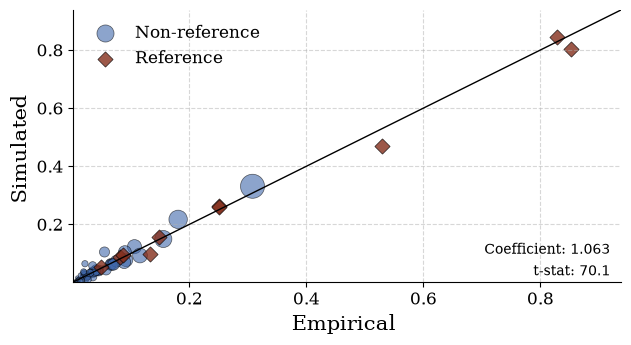

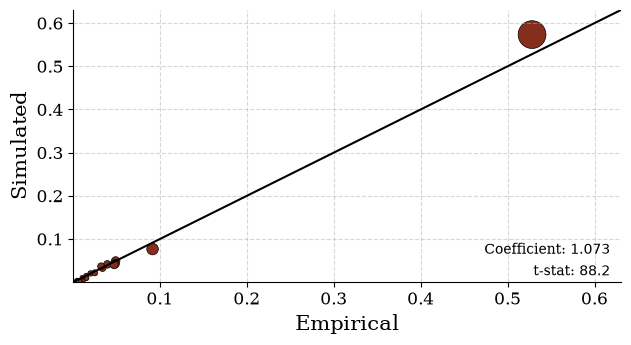

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


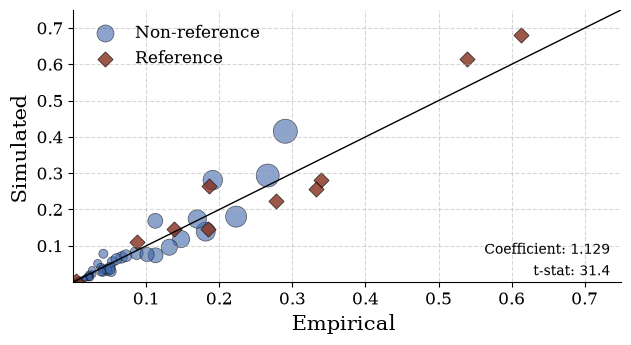

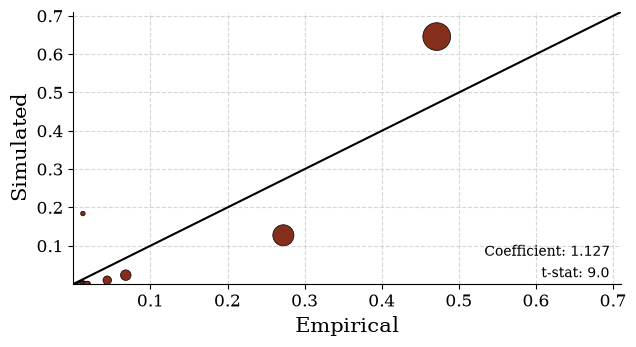

In [8]:
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()

    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()



In [9]:
# =============================================================================
# Empirical vs simulated, WITH standard errors:
#   (a) the cloglog distance-bin coefficients (moment block 4), and
#   (b) the zero-supplier shares Gbar_s(0)     (moment block 6, granular only).
#
# Error bars:
#   empirical — sqrt(diag(Sigma_data)), the bootstrap covariance of the empirical
#               moments, restricted to the beta / G blocks of the beta->gamma->G
#               inference subsystem (<run>/step2/Sigma_data.npy);
#   simulated — se_moments_fitted.npy = sqrt(diag(G V G')), the SE of the fitted
#               moment implied by the parameter covariance at the reported mu.
# Both come out of the Julia inference step, so nothing is re-estimated here.
# =============================================================================

REG_BIN_LABELS_5 = [r"$]0,50]$", r"$]50,100]$", r"$]100,150]$", r"$]150,200]$", r"$>200$"]


def reg_bin_labels(n_coef):
    if n_coef == 1:
        return [r"$\log d$"]
    if n_coef == 4:
        return REG_BIN_LABELS_5[1:]
    if n_coef == 5:
        return list(REG_BIN_LABELS_5)
    return [rf"$\beta_{{{i + 1}}}$" for i in range(n_coef)]


def _paired_errorbar(ax, labels, emp, sim, se_emp=None, se_sim=None, ci=1.96,
                     ylabel="", xlabel="", title=None, rotate=0):
    """Empirical (left) against simulated (right) at each tick, with +/- ci*SE bars."""
    x = np.arange(len(labels), dtype=float)
    off = 0.12
    ax.errorbar(x - off, emp, yerr=None if se_emp is None else ci * np.asarray(se_emp),
                fmt="o", color=toulouse_color, capsize=3, markersize=7,
                markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
                label="Empirical")
    ax.errorbar(x + off, sim, yerr=None if se_sim is None else ci * np.asarray(se_sim),
                fmt="D", color=sim_color, capsize=3, markersize=6,
                markeredgecolor="black", markeredgewidth=0.5, linestyle="none",
                label="Simulated")
    ax.axhline(0, color="black", linewidth=0.6, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if title:
        ax.set_title(title)
    ax.grid(axis="y", linestyle="dashed", alpha=0.5)
    ax.legend(frameon=False)
    _despine(ax)
    return ax


def plot_reg_coef(data, ax=None, save_to=None, ci=1.96):
    """Empirical vs simulated cloglog distance coefficients, with SEs."""
    emp = np.asarray(data["empirical_moments_dict"]["reg_coef"], float)
    sim = np.asarray(data["simulated_moments_dict"]["reg_coef"], float)
    se_e = data["se_empirical"]["reg_coef"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["reg_coef"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, reg_bin_labels(data["n_coef"]), emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"Extensive margin coefficient",
                     xlabel="Distance bin (km)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


def plot_G0(data, ax=None, save_to=None, ci=1.96, annotate_N=True):
    """Empirical vs simulated Gbar_s(0) — the share of cells with no supplier."""
    if not data["granular"]:
        raise ValueError("Gbar_s(0) only exists under --granular=true")
    emp = np.asarray(data["empirical_moments_dict"]["G0"], float)
    sim = np.asarray(data["simulated_moments_dict"]["G0"], float)
    se_e = data["se_empirical"]["G0"] if data["se_empirical"] else None
    se_s = data["se_simulated"]["G0"] if data["se_simulated"] else None

    fig, ax = (plt.subplots(figsize=get_figsize(hf=0.62)) if ax is None else (ax.figure, ax))
    _paired_errorbar(ax, data["sector_names"], emp, sim, se_e, se_s, ci=ci,
                     ylabel=r"$\bar{G}_s(0)$", xlabel="Sector (A129)", rotate=45)

    # The profiled variety count is what the model moves to hit this moment, so
    # print it next to each sector — a clamped sector cannot close its own residual.
    diag = data.get("granular_diagnostics")
    if annotate_N and diag is not None and "N_hat" in diag:
        N_hat = np.asarray(diag["N_hat"]).ravel()
        clamped = np.asarray(diag.get("clamped", np.zeros_like(N_hat))).ravel()
        top = ax.get_ylim()[1]
        for i, (n, cl) in enumerate(zip(N_hat, clamped)):
            ax.text(i, top, rf"$\hat{{N}}_s={int(n)}$" + ("*" if cl != 0 else ""),
                    ha="center", va="bottom", fontsize=font_size-3, rotation=45)
        ax.set_ylim(ax.get_ylim()[0], top * 1.02)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        ax.figure.savefig(save_to, format="pdf", bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference


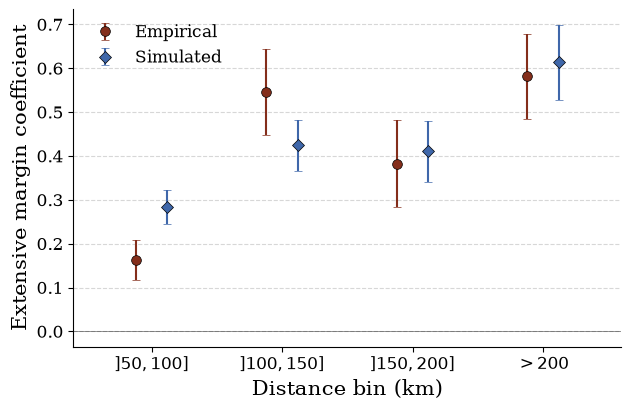

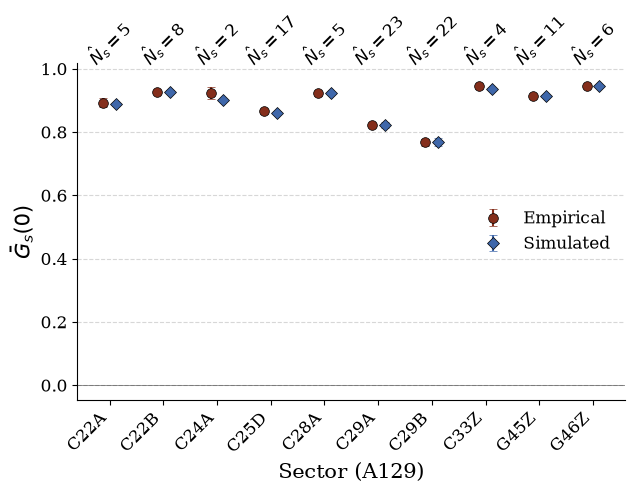

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


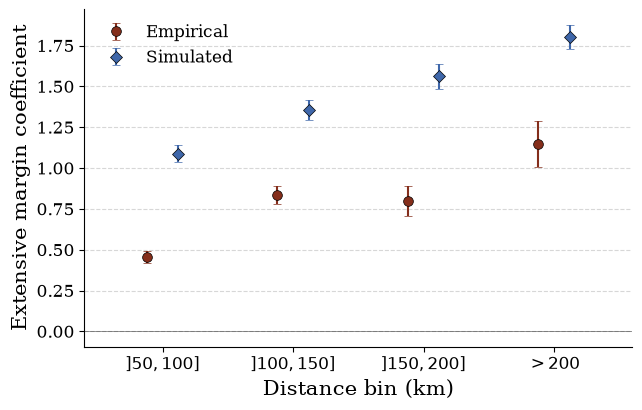

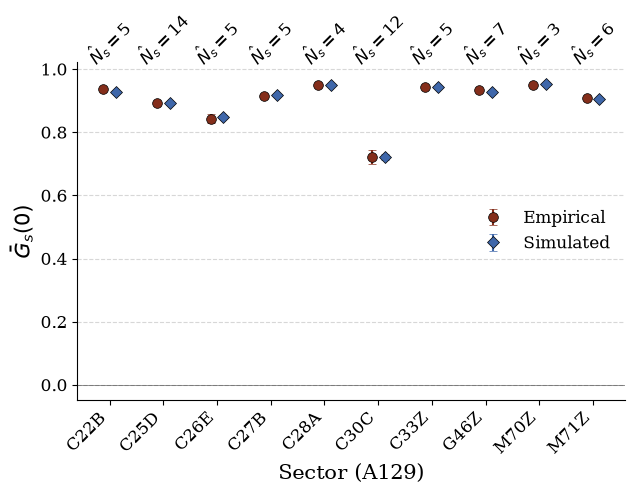

In [10]:
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()

    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()

# Jacobian and variance-covariance

## Jacobian

In [11]:
# =============================================================================
# Jacobian — which parameter moves which moment block?
#
# Rows are the MASKED moments (six blocks under --granular=true), columns the
# IDENTIFIED parameters, layout [Omega_L | Omega_s | A | alpha | T]. Both axes are
# labelled by the loader, so the block grid drawn here is the model's own.
#
# The matrix plotted is the ELASTICITY Jacobian (dlog m / dlog theta) — the raw
# dm/dtheta mixes units across blocks and cannot be read on one colour scale.
#
# Under profile_T this is the FREE-parameter Jacobian saved for diagnostics; the
# inference itself runs on the alpha-only profiled Jacobian (T follows alpha through
# the Sinkhorn inversion), so read this as "what would move if T were free", not as
# the inference input.
# =============================================================================

JACOBIAN_BOUNDARIES = [-1, -0.1, -0.05, -0.025, -0.01, -0.001,
                       0.001, 0.01, 0.025, 0.05, 0.1, 1]


def _binned_cmap(boundaries, coarse=False):
    from matplotlib.colors import BoundaryNorm, ListedColormap
    if coarse:
        return ListedColormap(["#2166ac", "#f0f0f0", "#b2182b"]), \
            BoundaryNorm([-1, -0.1, 0.1, 1], 3)
    n_bins = len(boundaries) - 1
    cmap = ListedColormap(plt.get_cmap("RdBu_r")(np.linspace(0, 1, n_bins)))
    return cmap, BoundaryNorm(boundaries, n_bins)


def jacobian_matrix(data, kind="elasticity"):
    """The Jacobian to plot, with a clear error when it is not on disk."""
    key = {"elasticity": "J_elast", "raw": "J", "sd": "J_sd",
           "elasticity_sd": "J_elast_sd"}[kind]
    J = data.get(key)
    if J is None:
        step = data["inference_step"]
        raise FileNotFoundError(
            f"no Jacobian in {data['folder']}/{step}/ — main.jl writes "
            f"jacobian_all*.npy at theta_hat_1 (step2) and jacobian_all_step3*.npy at "
            f"theta_hat_2 (step3); the corresponding inference step must have run.")
    return J


def _edges(sizes):
    return np.cumsum([0] + list(sizes))


def _tick_every(n, target=25):
    """Tick stride that keeps roughly `target` labels on an axis of length n."""
    return max(1, int(np.ceil(n / target)))


def plot_jacobian_full(data, kind="elasticity", coarse=False, figsize=(15, 11),
                       save_to=None):
    """
    One heatmap of the whole Jacobian, with the moment blocks on the rows and the
    parameter blocks on the columns — the direct read of which parameter block moves
    which moment block.
    """
    J = jacobian_matrix(data, kind)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(J, cmap=cmap, norm=norm, aspect="auto")

    for e in m_edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    for e in p_edges[1:-1]:
        ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)

    # block names on the outer margins, individual labels on the inner ones
    ax_top, ax_right = ax.secondary_xaxis("top"), ax.secondary_yaxis("right")
    ax_top.set_xticks((p_edges[:-1] + p_edges[1:]) / 2 - 0.5)
    ax_top.set_xticklabels(data["param_block_names"], fontsize=10, fontweight="bold")
    ax_right.set_yticks((m_edges[:-1] + m_edges[1:]) / 2 - 0.5)
    ax_right.set_yticklabels(data["moment_block_names"], fontsize=10, fontweight="bold")

    xs = np.arange(J.shape[1])[::_tick_every(J.shape[1])]
    ax.set_xticks(xs)
    ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
    ax.xaxis.set_ticks_position("bottom")
    ys = np.arange(J.shape[0])[::_tick_every(J.shape[0])]
    ax.set_yticks(ys)
    ax.set_yticklabels(np.array(data["moment_labels"])[ys], fontsize=7)

    ax.set_xlabel("Parameter")
    ax.set_ylabel("Moment")
    ax.set_title(f"Jacobian ({kind}) — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$   ({J.shape[0]}$\times${J.shape[1]})",
                 pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22,
                        ticks=(None if coarse else JACOBIAN_BOUNDARIES))
    cbar.set_label("Elasticity" if "elast" in kind else "d m / d theta")
    if not coarse:
        cbar.ax.set_xticklabels([f"{t:g}" for t in JACOBIAN_BOUNDARIES],
                                fontsize=8, rotation=45)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_blocks(data, kind="elasticity", coarse=True, ncols=3,
                         figsize=(18, 12), save_to=None):
    """One panel per MOMENT block, columns spanning all parameters (analysis.ipynb style)."""
    J = jacobian_matrix(data, kind)
    cmap, norm = _binned_cmap(JACOBIAN_BOUNDARIES, coarse=coarse)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    blocks = np.split(J, m_edges[1:-1], axis=0)
    names = data["moment_block_names"]

    nrows = int(np.ceil(len(names) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    for i, (name, block) in enumerate(zip(names, blocks)):
        ax = axes[i]
        im = ax.matshow(block, cmap=cmap, norm=norm, aspect="auto")
        for e in p_edges[1:-1]:
            ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.5)

        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.12)
        cbar.set_label("Elasticity", fontsize=9)
        ax.set_title(f"{name}\n({block.shape[0]}x{block.shape[1]})",
                     fontsize=13, fontweight="bold", pad=12)
        ax.set_xlabel("Parameter", fontsize=10)

        xs = np.arange(block.shape[1])[::_tick_every(block.shape[1], 20)]
        ax.set_xticks(xs)
        ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
        ax.xaxis.set_ticks_position("bottom")

        row_labels = np.array(data["moment_labels"][m_edges[i]:m_edges[i + 1]])
        ys = np.arange(block.shape[0])[::_tick_every(block.shape[0], 20)]
        ax.set_yticks(ys)
        ax.set_yticklabels(row_labels[ys], fontsize=7)

    for ax in axes[len(names):]:
        ax.axis("off")
    fig.suptitle(f"Jacobian by moment block — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$", fontsize=18, fontweight="bold")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes[:len(names)]


def jacobian_block_summary(data, kind="elasticity"):
    """
    Mean and max |elasticity| for every (moment block x parameter block) pair — the
    same table `compute_jacobian` prints, as a DataFrame so it can be read at a glance.
    """
    J = np.abs(jacobian_matrix(data, kind))
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    rows = []
    for i, mname in enumerate(data["moment_block_names"]):
        for j, pname in enumerate(data["param_block_names"]):
            sub = J[m_edges[i]:m_edges[i + 1], p_edges[j]:p_edges[j + 1]]
            rows.append({"moment_block": mname, "param_block": pname,
                         "mean_abs": sub.mean() if sub.size else np.nan,
                         "max_abs": sub.max() if sub.size else np.nan})
    return pd.DataFrame(rows).pivot(index="moment_block", columns="param_block",
                                    values="mean_abs").reindex(
        index=data["moment_block_names"], columns=data["param_block_names"])


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference


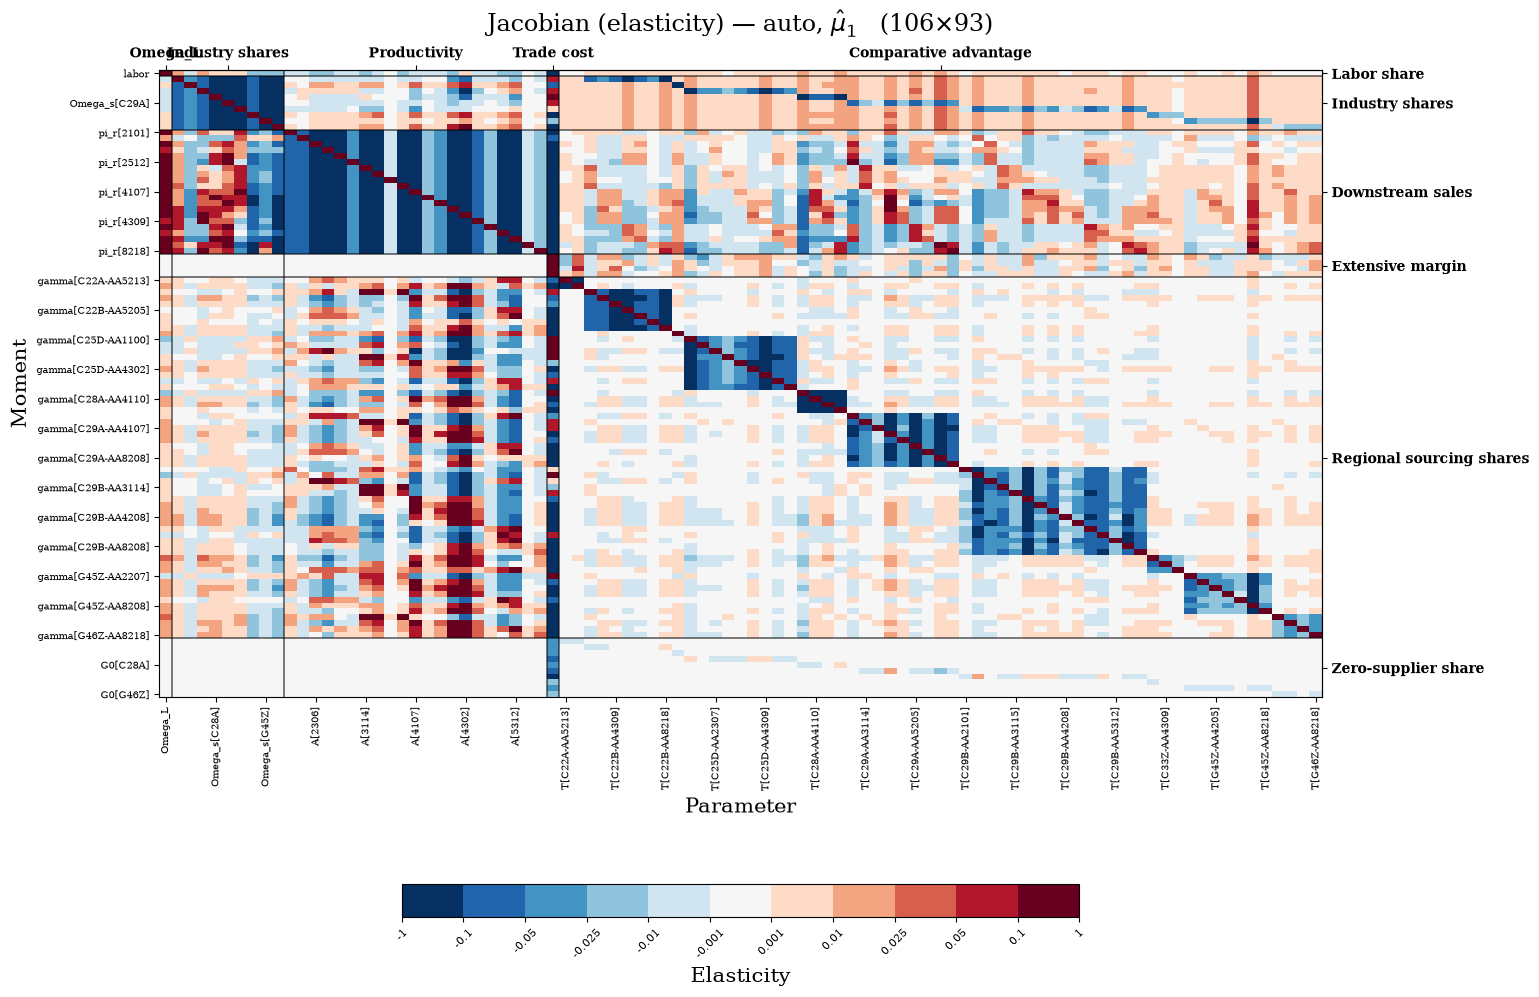

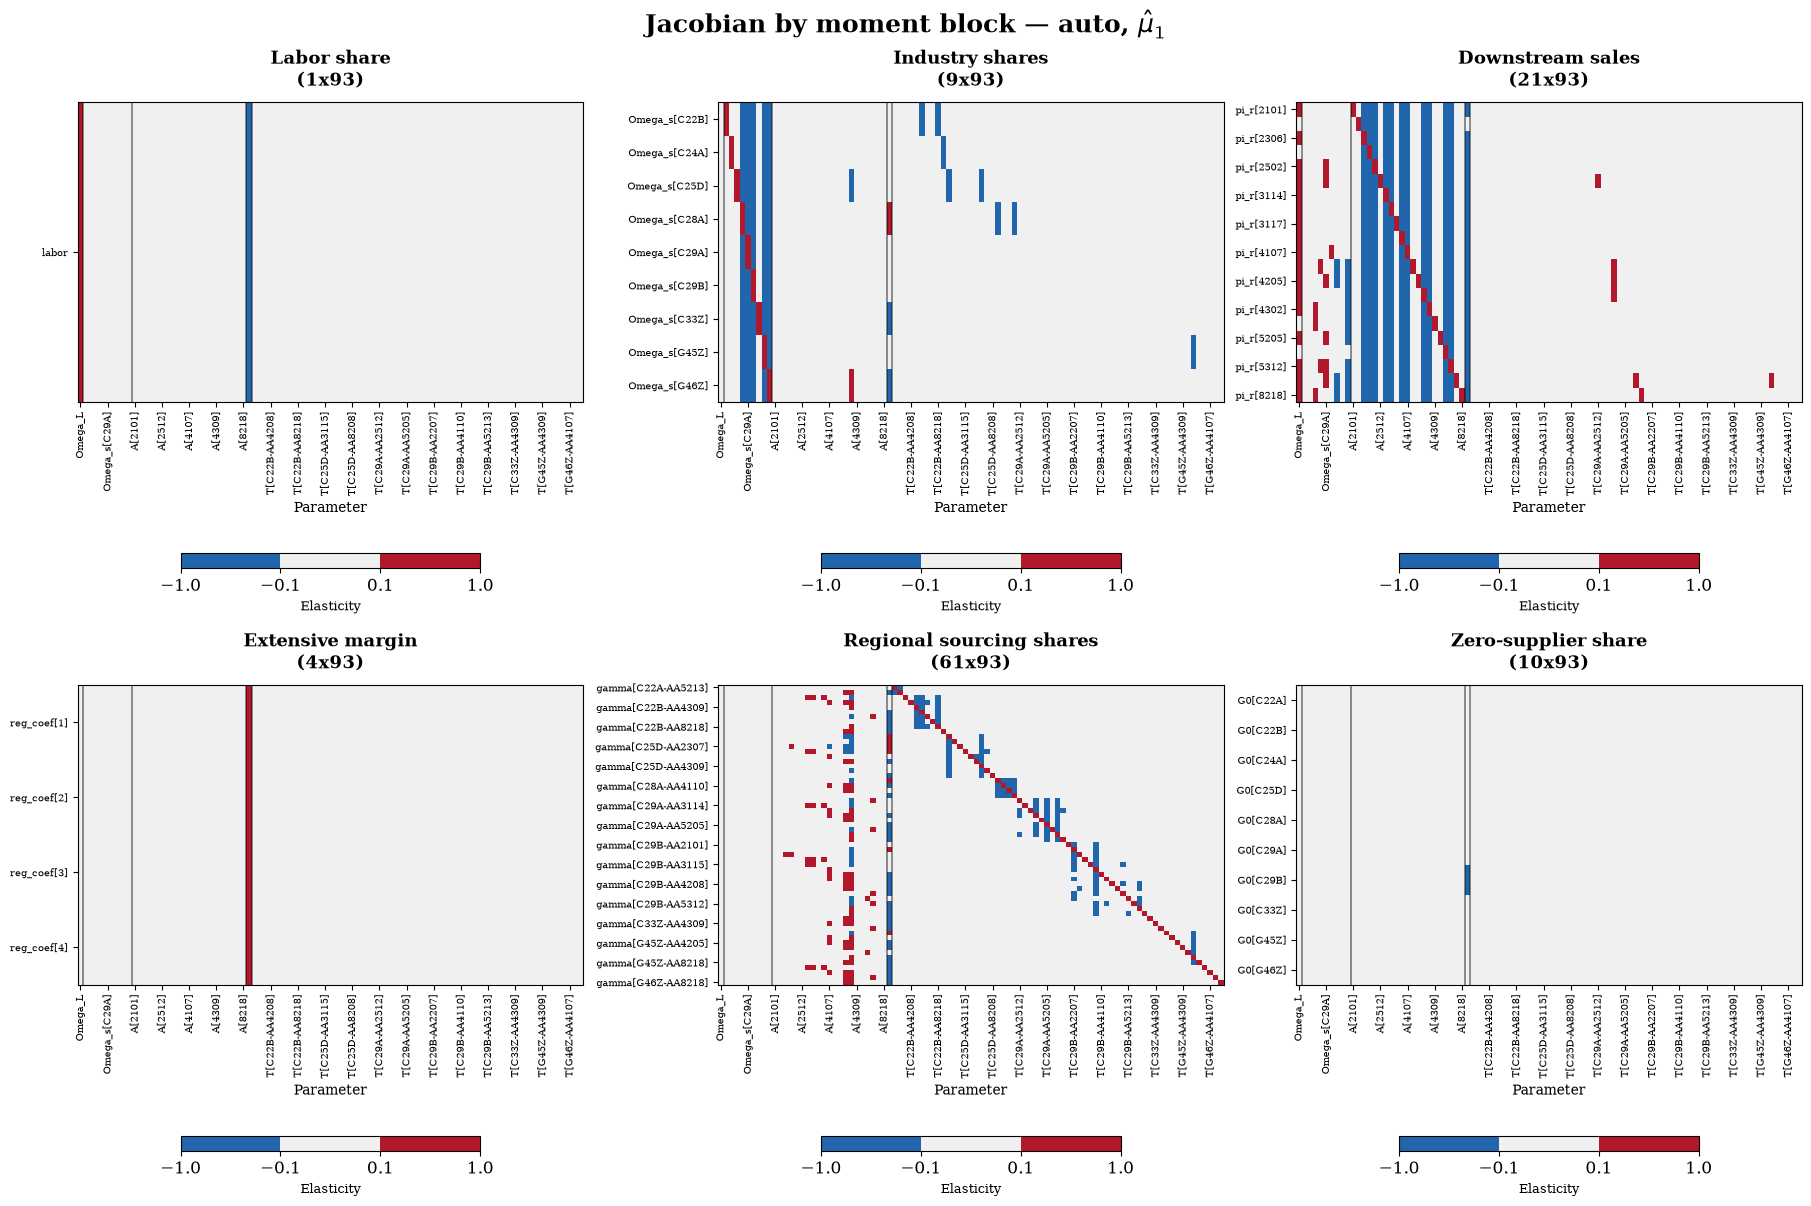

param_block,Omega_L,Industry shares,Productivity,Trade cost,Comparative advantage
moment_block,,,,,
Labor share,0.858649,0.013397,0.007538,0.680994,0.003700
Industry shares,0.004812,0.196316,0.009533,0.081819,0.012582
Downstream sales,0.122455,0.049686,0.594856,0.866119,0.012048
Extensive margin,0.000000,0.000000,0.000000,1.012969,0.007322
Regional sourcing shares,0.010728,0.005101,0.036677,0.185621,0.025977
Zero-supplier share,0.000000,0.000000,0.000000,0.043223,0.000269


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


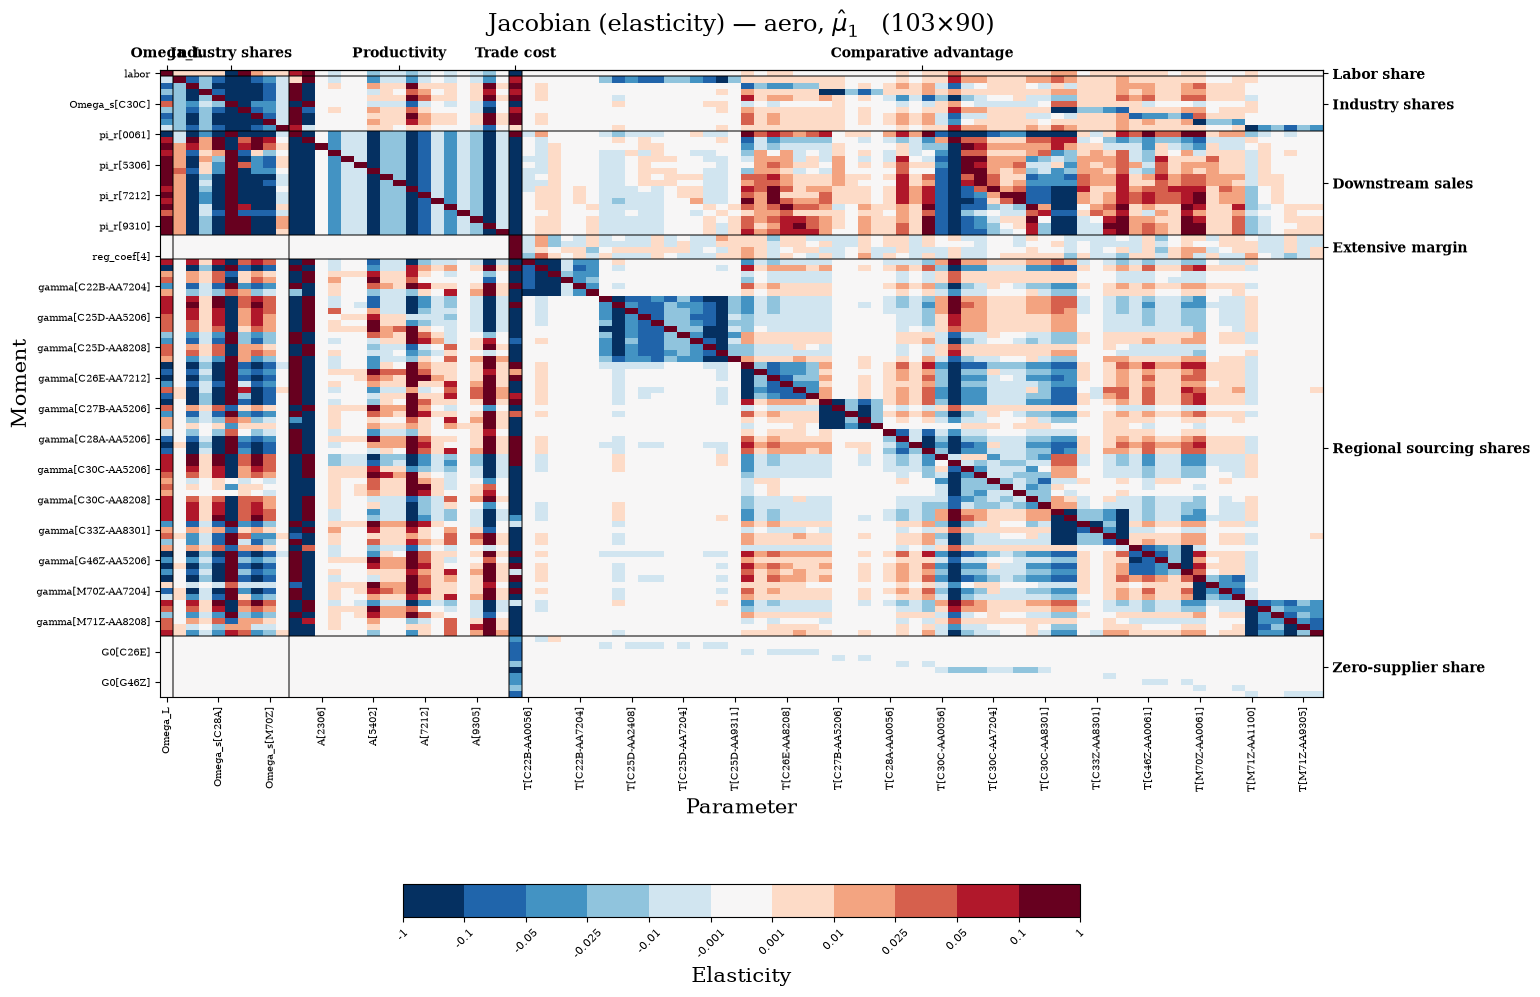

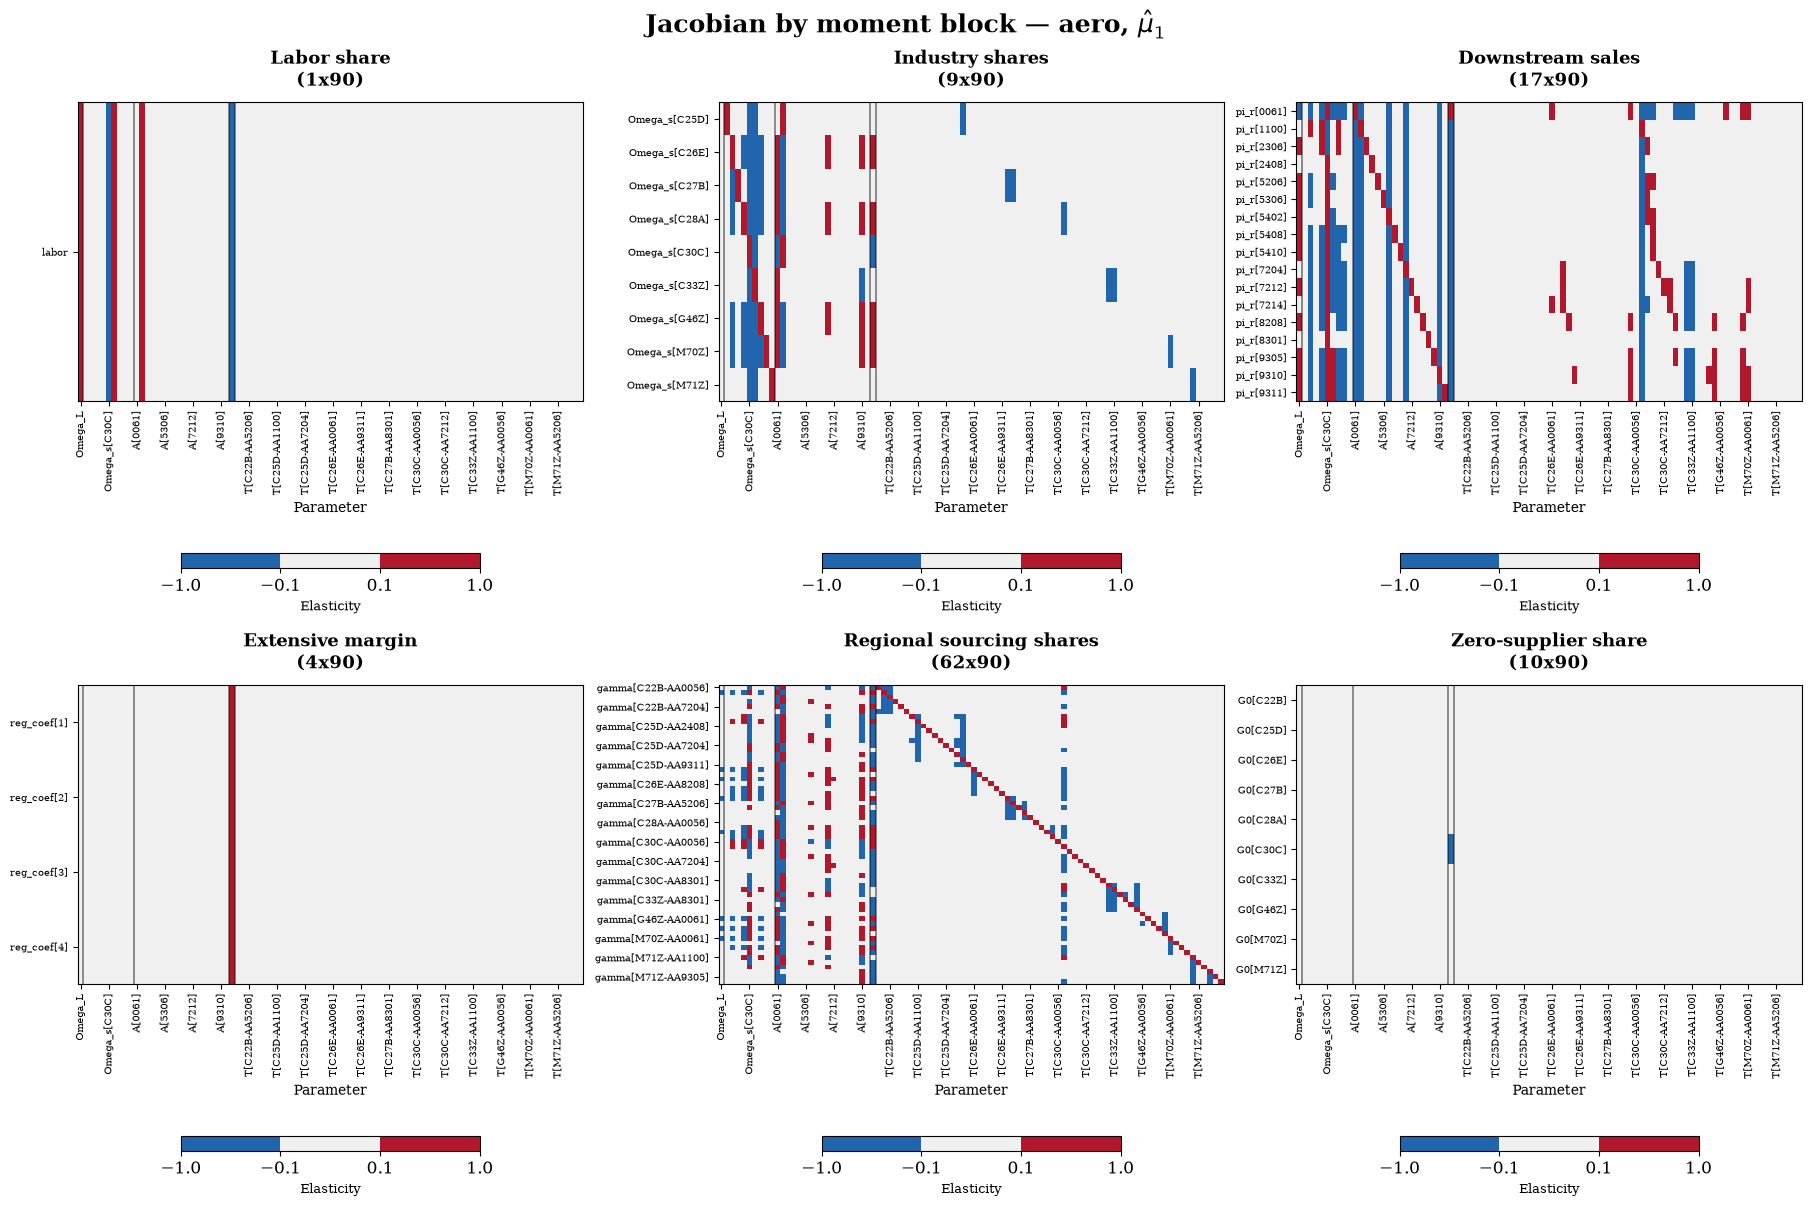

param_block,Omega_L,Industry shares,Productivity,Trade cost,Comparative advantage
moment_block,,,,,
Labor share,0.912378,0.036319,0.033729,1.044062,0.002589
Industry shares,0.038083,0.185217,0.100308,0.160491,0.009673
Downstream sales,0.296192,0.192270,1.607484,2.359391,0.033634
Extensive margin,0.000000,0.000000,0.000000,1.031279,0.004172
Regional sourcing shares,0.053808,0.064288,0.179437,0.366594,0.028866
Zero-supplier share,0.000000,0.000000,0.000000,0.056556,0.000318


In [12]:

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Jacobian: which parameter moves which moment block? -----------------
    plot_jacobian_full(data, save_to=f"{out_folder}/jacobian_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data))



## Variance-covariance

In [13]:
# =============================================================================
# Variance-covariance of the moments.
#
# Over the beta -> gamma -> G subsystem (the inference subsystem), all three from
# <run>/step2/:
#   Sigma_data : bootstrap covariance of the EMPIRICAL moments,
#   Sigma_sim  : covariance across K re-simulations at theta_hat_1 (simulation noise),
#   Omega      : Sigma_data + Sigma_sim — what the estimator actually weighted with,
#                W_step3 = inv(Omega).
# =============================================================================


def _gb_edges(data):
    """Block edges of the beta -> gamma -> G subsystem, and their names."""
    n_beta = data["n_coef"]
    n_gam = int(np.asarray(data["moment_block_sizes"])[4])
    sizes = [n_beta, n_gam] + ([data["S"]] if data["granular"] else [])
    names = ["reg_coef", "gamma", "G0"][:len(sizes)]
    return np.cumsum([0] + sizes), names


def plot_variance_covariance(data, figsize=(16, 5.5), pct=95, save_to=None):
    """Sigma_sim, Sigma_data and Omega side by side, on a symmetric diverging scale."""
    from matplotlib.colors import TwoSlopeNorm

    mats = [("$\\Sigma_{sim}$ (simulation noise)", data.get("Sigma_sim")),
            ("$\\Sigma_{data}$ (bootstrap)", data.get("Sigma_data")),
            ("$\\Omega = \\Sigma_{data} + \\Sigma_{sim}$", data.get("Omega"))]
    if all(m is None for _, m in mats):
        raise FileNotFoundError(f"no Sigma_*/Omega in {data['folder']}/step2/ — "
                                "build_step3_weight_matrix writes them in Step 2.")

    edges, names = _gb_edges(data)
    fig, axes = plt.subplots(1, len(mats), figsize=figsize)
    for ax, (title, M) in zip(np.atleast_1d(axes), mats):
        if M is None:
            ax.axis("off")
            ax.set_title(title + "\n(absent)")
            continue
        v = np.percentile(np.abs(M), pct)
        v = v if v > 0 else (np.abs(M).max() or 1.0)
        im = ax.matshow(M, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v))
        for e in edges[1:-1]:
            ax.axhline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
            ax.axvline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
        ticks = (edges[:-1] + edges[1:]) / 2 - 0.5
        ax.set_xticks(ticks)
        ax.set_xticklabels(names, fontsize=9)
        ax.set_yticks(ticks)
        ax.set_yticklabels(names, fontsize=9, rotation=90, va="center")
        ax.set_title(title, pad=14)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.suptitle(f"Moment variance-covariance — {data['industry']} "
                 "(beta, gamma, G0 subsystem)", fontsize=14)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def variance_covariance_summary(data):
    """
    How much of the weighting is simulation noise, and how well conditioned is Omega?

    `trace(Sigma_sim)/trace(Sigma_data)` is the share of total moment variance that
    comes from the simulation rather than the data — raise `--n_rho_inf` if it is not
    small. The condition numbers say whether inverting Omega to build W is safe.
    """
    out = {}
    for name in ("Sigma_data", "Sigma_sim", "Omega"):
        M = data.get(name)
        if M is None:
            continue
        ev = np.linalg.eigvalsh((M + M.T) / 2)
        out[name] = {"trace": float(np.trace(M)),
                     "eig_min": float(ev.min()), "eig_max": float(ev.max()),
                     "cond": float(ev.max() / ev.min()) if ev.min() > 0 else np.inf}
    if "Sigma_sim" in out and "Sigma_data" in out and out["Sigma_data"]["trace"] != 0:
        out["sim_share_of_trace"] = out["Sigma_sim"]["trace"] / out["Sigma_data"]["trace"]
    return pd.DataFrame({k: v for k, v in out.items() if isinstance(v, dict)}).T


def plot_moment_correlation(data, which="Omega", figsize=(7, 6), save_to=None):
    """Correlation implied by one of the covariance matrices — scale-free companion view."""
    M = data.get(which)
    if M is None:
        raise FileNotFoundError(f"{which} is not on disk for this run")
    d = np.sqrt(np.clip(np.diag(M), 1e-300, None))
    C = M / np.outer(d, d)
    edges, names = _gb_edges(data)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
    for e in edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
        ax.axvline(e - 0.5, color="black", linewidth=0.8, alpha=0.6)
    ticks = (edges[:-1] + edges[1:]) / 2 - 0.5
    ax.set_xticks(ticks)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_yticks(ticks)
    ax.set_yticklabels(names, fontsize=9, rotation=90, va="center")
    ax.set_title(f"Moment correlation implied by {which} — {data['industry']}", pad=14)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference


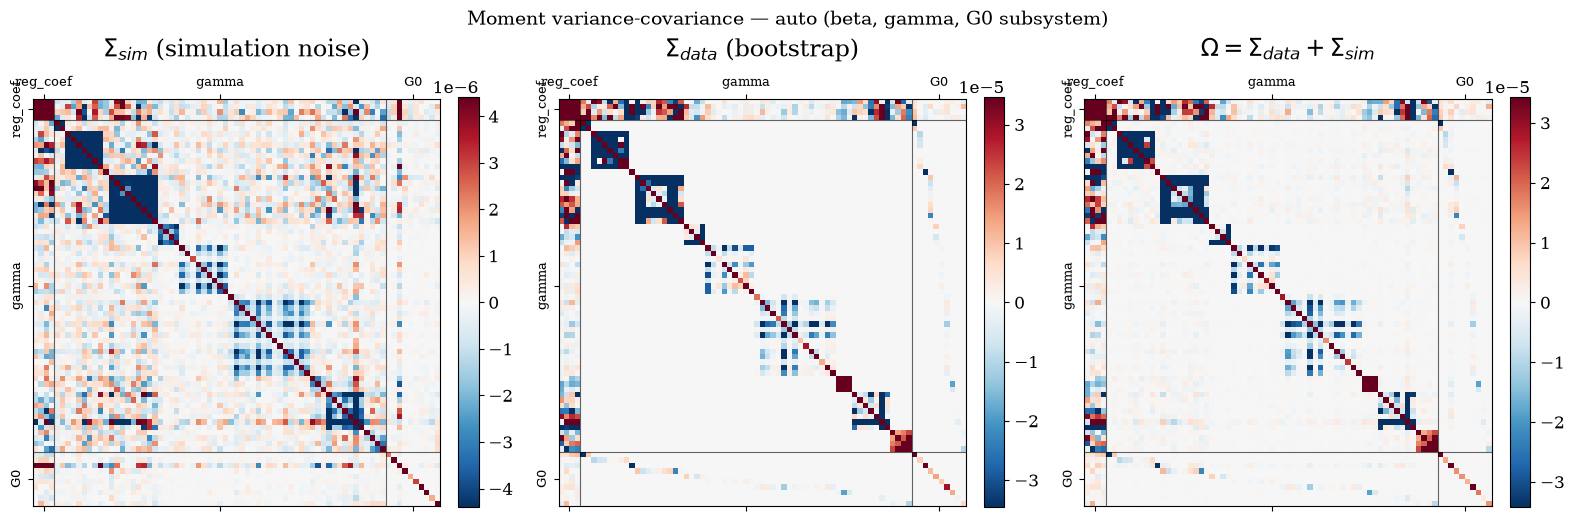

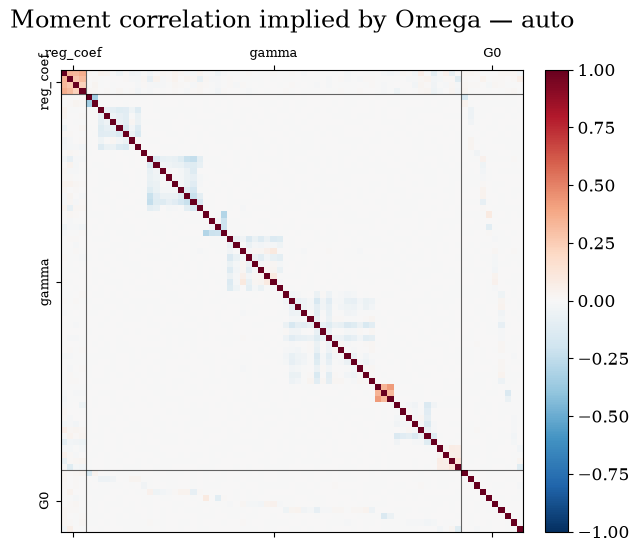

,trace,eig_min,eig_max,cond
Sigma_data,0.076572,0.000001,0.012064,8906.941253
Sigma_sim,0.008251,0.000002,0.000921,581.043516
Omega,0.084823,0.000003,0.012148,4076.095721


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


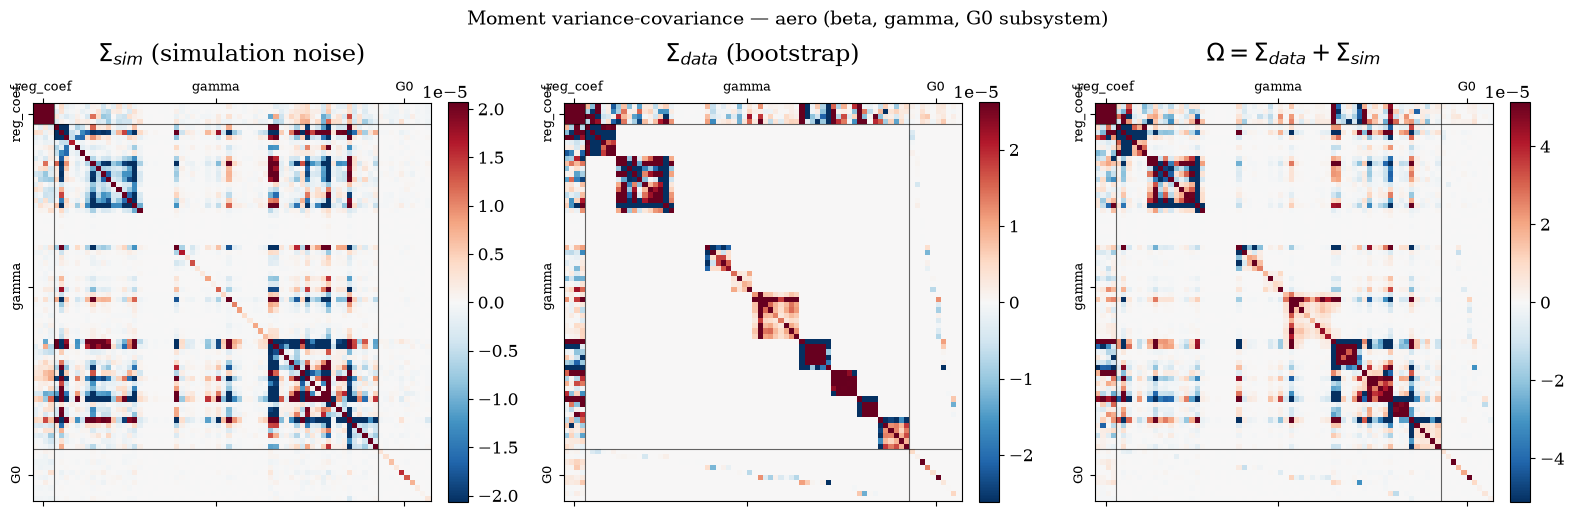

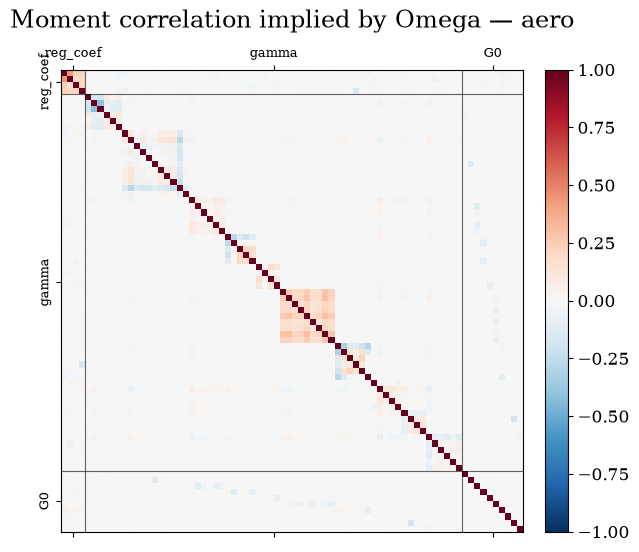

,trace,eig_min,eig_max,cond
Sigma_data,0.113914,1.109410e-31,0.022176,1.998878e+29
Sigma_sim,0.011919,1.818358e-09,0.001966,1.080957e+06
Omega,0.125833,1.040316e-08,0.023019,2.212704e+06


In [14]:

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Variance-covariance of the moments ----------------------------------
    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))

## Identification / sensitivity

A sensitivity analysis fixes every parameter, moves one of them above and below its
estimate, and checks that the moments respond smoothly and in a direction the design
predicts. The elasticity Jacobian *is* that experiment, linearised at the estimate:
$\varepsilon_{jk} = \partial \log m_j / \partial \log \theta_k$ is the local slope of
moment $j$ against parameter $k$. With ten sectors, the attraction areas and the $T$
block there are far too many parameters to draw a curve each, so the matrix is drawn
instead and everything below a threshold is blanked out.

Two things are added here relative to the Jacobian section above.

1. **The variety counts are put back into the parameter axis.** $N_s$ is profiled out
   by the integer bisection, so it never appears in `jacobian_all*.npy` — but Julia
   does compute $\partial m/\partial N_s$ for inference and writes it to
   `<step>/inference/jacobian_N_s.npy`. `with_variety_counts` re-attaches it, so the
   picture covers $(\Omega, A, \alpha, T, N_s)$ — every parameter the model has.
2. **The elasticities are thresholded**, as in the sub-block figures, so what is left
   is the set of channels through which a parameter can actually be identified.

What this is meant to show: the three channels are close to orthogonal *by
construction*. $\alpha$ is read from a **within**-area distance gradient that
comparative advantage cannot touch, since comparative advantage is constant within an
area; $T_{as}$ is read from **across**-area value shares; $N_s$ is read from the
**level** of the empty-region share, which the sector $\times$ nearest-downstream fixed
effect strips out of the $\alpha$ regression. So the expected picture is
near-block-diagonal on the (Trade cost, Comparative advantage, Variety count)
$\times$ (Extensive margin, Regional sourcing shares, Zero-supplier share) corner —
and in the $N_s$ columns *exact* zeros rather than merely small numbers, since the
two evaluations of the first difference share draws and every $N_s$-free moment
cancels to `0.0` (asserted in Julia as gate V10).

In [15]:
# =============================================================================
# Identification / sensitivity — the variety counts put BACK into the parameter
# axis of the Jacobian.
#
# `jacobian_all*.npy` has columns [Omega_L | Omega_s | A | alpha | T] only: N_s is
# not searched over, it is PROFILED OUT by the monotone integer bisection on
# Gbar_s(n) = mean_l (1 - q_hat_ls)^n, so it never enters `jacobian_param_indices`.
# It is not missing from the Julia side, though — `compute_N_s_jacobian` computes
# dm/dN_s for inference and writes it to <step>/inference/jacobian_N_s.npy. That is
# the block re-attached here, so the sensitivity picture covers every parameter the
# model actually has.
#
# Two conventions to keep in mind when reading the N_s columns:
#
#   * the derivative is a unit FIRST DIFFERENCE m(N_s + 1) - m(N_s). N_s is an
#     integer, so one variety IS the step: there is no step size to choose;
#   * the zeros outside block 6 are STRUCTURAL, not numerical. The two evaluations
#     share draws, so any moment without an N_s term differences to exactly 0.0, and
#     Julia ASSERTS it (gate V10: reg_coef is N_s-free by Prop. 1, q_hat by Lemma 2).
#     An exact zero in an N_s column is the model's own statement that the channel
#     does not exist, not a small number that happened to fall under a threshold.
#
# Elasticities use the same convention as `compute_jacobian`,
#     e_jk = (theta_k / m_j) * dm_j / dtheta_k,
# with theta_k = N_hat_s and m_j the simulated moment at the reported estimate.
# =============================================================================


def n_s_jacobian(data):
    """
    `dm/dN_s` on the FULL masked moment rows, raw and in elasticity, plus the
    profiled `N_hat_s` it is evaluated at.

    On disk the block covers the beta -> gamma -> G rows only (the inference
    subsystem); those are the trailing rows of the masked moment vector, and every
    row above them is N_s-free by construction, so the embedding is exact.
    """
    if not data["granular"]:
        raise ValueError("N_s exists only under --granular=true; this run is the "
                         "continuum model and has no variety-count parameters.")

    inf_dir = data["folder"] / data["inference_step"] / "inference"
    p = inf_dir / "jacobian_N_s.npy"
    if not p.exists():
        raise FileNotFoundError(
            f"{p} not found. `run_profiled_inference` writes it under GRANULAR at "
            "theta_hat_1 (step2) and theta_hat_2 (step3); the corresponding inference "
            "step must have run.")

    S = data["S"]
    sizes = list(data["moment_block_sizes"])
    n_rows, n_gb = int(np.sum(sizes)), int(np.sum(sizes[3:]))

    G_N = np.load(p)
    if G_N.shape != (n_gb, S):
        raise ValueError(
            f"jacobian_N_s.npy is {G_N.shape} but the layout rebuilt here is "
            f"{(n_gb, S)} (beta -> gamma -> G rows x S sectors) — the run's flags and "
            "the ones passed here disagree.")
    J_N = np.zeros((n_rows, S))
    J_N[n_rows - n_gb:, :] = G_N

    sd_path = inf_dir / "jacobian_N_s_sd.npy"
    J_N_sd = None
    if sd_path.exists():
        J_N_sd = np.zeros((n_rows, S))
        J_N_sd[n_rows - n_gb:, :] = np.load(sd_path)

    diag = data.get("granular_diagnostics")
    if diag is None or "N_hat" not in diag:
        raise FileNotFoundError(
            f"no granular_diagnostics.npz with N_hat in {data['folder']}/"
            f"{data['inference_step']}/ — needed to scale dm/dN_s into an elasticity.")
    N_hat = np.asarray(diag["N_hat"], dtype=float).ravel()
    if N_hat.size != S:
        raise ValueError(f"N_hat has {N_hat.size} entries, expected S = {S}")

    m0 = np.asarray(data["best_simulated_moments"])[:, data["K"]][data["moment_mask"]]
    with np.errstate(divide="ignore", invalid="ignore"):
        E = J_N * (N_hat[None, :] / m0[:, None])
        E_sd = None if J_N_sd is None else J_N_sd * (N_hat[None, :] / np.abs(m0)[:, None])
    E[~np.isfinite(E)] = 0.0
    if E_sd is not None:
        E_sd[~np.isfinite(E_sd)] = 0.0

    labels = [f"N_s[{data['sector_names'][s]}]" for s in range(S)]
    return {"J_N": J_N, "J_N_elast": E, "J_N_sd": J_N_sd, "J_N_elast_sd": E_sd,
            "N_hat": N_hat, "labels": labels}


def with_variety_counts(data):
    """
    A COPY of `data` whose Jacobian carries a sixth parameter block, `N_s`.

    Only the Jacobian and its two axis descriptions change, so every function
    written against the loader's layout — `plot_jacobian_full`,
    `plot_jacobian_blocks`, `jacobian_block_summary` — works on the returned dict
    unchanged, now including the variety counts.
    """
    nb = n_s_jacobian(data)
    out = dict(data)

    def _cat(key, block):
        if data.get(key) is None or block is None:
            out[key] = None
        else:
            out[key] = np.hstack([np.asarray(data[key]), block])

    _cat("J", nb["J_N"])
    _cat("J_elast", nb["J_N_elast"])
    _cat("J_sd", nb["J_N_sd"])
    _cat("J_elast_sd", nb["J_N_elast_sd"])

    out["param_labels"] = list(data["param_labels"]) + nb["labels"]
    out["param_block_sizes"] = list(data["param_block_sizes"]) + [data["S"]]
    out["param_block_names"] = list(data["param_block_names"]) + ["Variety count"]
    out["N_hat"] = nb["N_hat"]
    out["has_variety_counts"] = True
    return out

In [16]:
# =============================================================================
# The sensitivity picture, thresholded.
#
# A sensitivity analysis in the usual sense — fix every parameter, move one of them
# around its estimate, plot how each moment responds — is what the elasticity
# Jacobian already IS, evaluated at the estimate: e_jk = dlog m_j / dlog theta_k is
# the local slope of exactly that experiment. With ~10 sectors, ~20 attraction areas
# and the T block, there are far too many parameters to draw one curve each, so the
# whole matrix is plotted instead and everything below a threshold is blanked out.
#
# Reading the threshold: |e| >= 0.01 means a 1% move in the parameter shifts the
# moment by at least 0.01%. What survives is the set of channels through which a
# parameter can actually be identified.
#
# The claim these figures support is that the three channels are close to
# orthogonal by construction:
#
#   alpha  is read from a WITHIN-area distance gradient, which comparative advantage
#          cannot touch because comparative advantage is constant within an area;
#   T_as   is read from ACROSS-area value shares;
#   N_s    is read from the LEVEL of the empty-region share, which the sector x
#          nearest-downstream fixed effect strips out of the alpha regression.
#
# So the prediction is a near-block-diagonal picture on the (Trade cost,
# Comparative advantage, Variety count) x (Extensive margin, Regional sourcing
# shares, Zero-supplier share) corner — and, for the N_s columns, exact zeros
# everywhere else rather than merely small numbers.
# =============================================================================

IDENT_THRESHOLD = 0.01


def _blocks_2d(data, M):
    """M split into (moment block x parameter block) sub-matrices."""
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])
    return {(i, j): M[m_edges[i]:m_edges[i + 1], p_edges[j]:p_edges[j + 1]]
            for i in range(len(data["moment_block_names"]))
            for j in range(len(data["param_block_names"]))}


def identification_summary(data, threshold=IDENT_THRESHOLD, kind="elasticity"):
    """
    Per (moment block x parameter block): the share of entries whose |elasticity|
    clears the threshold, the max |elasticity|, and the share that are EXACTLY zero
    (structural absence of the channel, as opposed to a weak one).
    """
    E = np.abs(jacobian_matrix(data, kind))
    rows = []
    for (i, j), sub in _blocks_2d(data, E).items():
        rows.append({
            "moment_block": data["moment_block_names"][i],
            "param_block": data["param_block_names"][j],
            "share_above": float((sub >= threshold).mean()) if sub.size else np.nan,
            "max_abs": float(sub.max()) if sub.size else np.nan,
            "mean_abs": float(sub.mean()) if sub.size else np.nan,
            "share_exact_zero": float((sub == 0).mean()) if sub.size else np.nan,
        })
    df = pd.DataFrame(rows)
    return df.set_index(["moment_block", "param_block"]).unstack("param_block") \
             .reindex(index=data["moment_block_names"]) \
             .reindex(columns=data["param_block_names"], level=1)


def plot_identification_map(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                            figsize=(9, 6), save_to=None):
    """
    The compact figure: one cell per (moment block x parameter block), coloured by
    the SHARE of its entries whose |elasticity| clears the threshold, annotated with
    that share and the block's max |elasticity|.

    A near-diagonal pattern down the (Trade cost, Comparative advantage, Variety
    count) columns is the identification claim, read off directly.
    """
    E = np.abs(jacobian_matrix(data, kind))
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks = _blocks_2d(data, E)
    share = np.array([[(blocks[(i, j)] >= threshold).mean() if blocks[(i, j)].size else np.nan
                       for j in range(len(p_names))] for i in range(len(m_names))])
    mx = np.array([[blocks[(i, j)].max() if blocks[(i, j)].size else np.nan
                    for j in range(len(p_names))] for i in range(len(m_names))])

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(share, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(len(m_names)):
        for j in range(len(p_names)):
            if not np.isfinite(share[i, j]):
                continue
            txt = f"{100 * share[i, j]:.0f}%\nmax {mx[i, j]:.3g}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=9,
                    color="white" if share[i, j] > 0.55 else "black")
    ax.set_xticks(range(len(p_names)))
    ax.set_xticklabels(p_names, rotation=30, ha="left", fontsize=10)
    ax.xaxis.set_ticks_position("top")
    ax.set_yticks(range(len(m_names)))
    ax.set_yticklabels(m_names, fontsize=10)
    ax.set_xlabel("Parameter block")
    ax.set_ylabel("Moment block")
    ax.set_title(f"Identification map — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"\nshare of $|\\varepsilon| \\geq {threshold:g}$", pad=52)
    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label(f"share of entries with $|\\varepsilon| \\geq {threshold:g}$")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_jacobian_thresholded(data, threshold=IDENT_THRESHOLD, kind="elasticity",
                              figsize=(15, 11), save_to=None):
    """
    The whole elasticity Jacobian with every |e| < threshold blanked out (light
    grey), the surviving entries on a symmetric log colour scale so three orders of
    magnitude of live channel stay distinguishable.
    """
    from matplotlib.colors import SymLogNorm

    E = jacobian_matrix(data, kind)
    A = np.abs(E)
    vmax = A.max() if A.size and A.max() > 0 else 1.0
    M = np.ma.masked_where(A < threshold, E)
    m_edges, p_edges = _edges(data["moment_block_sizes"]), _edges(data["param_block_sizes"])

    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("#f2f2f2")

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(M, cmap=cmap, aspect="auto",
                    norm=SymLogNorm(linthresh=threshold, vmin=-vmax, vmax=vmax, base=10))
    for e in m_edges[1:-1]:
        ax.axhline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)
    for e in p_edges[1:-1]:
        ax.axvline(e - 0.5, color="black", linewidth=1.2, alpha=0.6)

    ax_top, ax_right = ax.secondary_xaxis("top"), ax.secondary_yaxis("right")
    ax_top.set_xticks((p_edges[:-1] + p_edges[1:]) / 2 - 0.5)
    ax_top.set_xticklabels(data["param_block_names"], fontsize=10, fontweight="bold")
    ax_right.set_yticks((m_edges[:-1] + m_edges[1:]) / 2 - 0.5)
    ax_right.set_yticklabels(data["moment_block_names"], fontsize=10, fontweight="bold")

    xs = np.arange(M.shape[1])[::_tick_every(M.shape[1])]
    ax.set_xticks(xs)
    ax.set_xticklabels(np.array(data["param_labels"])[xs], rotation=90, fontsize=7)
    ax.xaxis.set_ticks_position("bottom")
    ys = np.arange(M.shape[0])[::_tick_every(M.shape[0])]
    ax.set_yticks(ys)
    ax.set_yticklabels(np.array(data["moment_labels"])[ys], fontsize=7)

    ax.set_xlabel("Parameter")
    ax.set_ylabel("Moment")
    kept = float((A >= threshold).mean())
    ax.set_title(f"Elasticity Jacobian, $|\\varepsilon| \\geq {threshold:g}$ — "
                 f"{data['industry']}, " rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   ({100 * kept:.1f}% of {A.size} entries shown)", pad=28)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.22)
    cbar.set_label(r"$\varepsilon = \partial \log m / \partial \log \theta$"
                   "   (symmetric log; grey = below threshold)")
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_channel_elasticities(data, param_blocks=("Trade cost", "Comparative advantage",
                                                  "Variety count"),
                              threshold=IDENT_THRESHOLD, kind="elasticity",
                              stat="max", figsize=(11, 5), save_to=None):
    """
    One panel per channel: the largest |elasticity| that channel produces in each
    moment block, on a log axis, with the threshold drawn in.

    This is the paragraph in one picture — alpha tall on the extensive margin, T
    tall on the sourcing shares, N_s tall on the zero-supplier share and EXACTLY
    zero (no bar, marked "0") everywhere else.
    """
    E = np.abs(jacobian_matrix(data, kind))
    m_names, p_names = data["moment_block_names"], data["param_block_names"]
    blocks = _blocks_2d(data, E)
    reduce = {"max": np.max, "mean": np.mean}[stat]
    stat_tex = {"max": r"\max", "mean": r"\mathrm{mean}"}[stat]

    wanted = [p for p in param_blocks if p in p_names]
    missing = [p for p in param_blocks if p not in p_names]
    if missing:
        raise ValueError(f"parameter block(s) {missing} absent — the Jacobian has "
                         f"{p_names}. Pass the dict returned by `with_variety_counts` "
                         "to include the variety counts.")

    vals = {p: np.array([reduce(blocks[(i, p_names.index(p))])
                         if blocks[(i, p_names.index(p))].size else 0.0
                         for i in range(len(m_names))]) for p in wanted}
    pos = np.concatenate([v[v > 0] for v in vals.values()] or [np.array([threshold])])
    bottom = (pos.min() / 4) if pos.size else threshold / 10

    fig, axes = plt.subplots(1, len(wanted), figsize=figsize, sharey=True)
    axes = np.atleast_1d(axes)
    x = np.arange(len(m_names))
    for ax, pname in zip(axes, wanted):
        v_p = vals[pname]
        ax.bar(x, v_p, color=[sim_color if v >= threshold else "0.75" for v in v_p])
        ax.set_yscale("log")
        ax.set_ylim(bottom=bottom)
        ax.axhline(threshold, color=reference_color, linestyle="--", linewidth=1.2)
        for i, v in enumerate(v_p):
            if v == 0:
                ax.text(i, bottom * 1.35, "0", ha="center", va="bottom",
                        fontsize=10, color=reference_color, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(m_names, rotation=45, ha="right", fontsize=9)
        ax.set_title(pname, fontsize=13, fontweight="bold")
        _despine(ax)
    axes[0].set_ylabel(rf"${stat_tex}_{{j,k}} |\varepsilon_{{jk}}|$ in block")
    fig.suptitle(f"Where each channel acts — {data['industry']}, "
                 rf"$\hat{{\mu}}_{data['mu']}$"
                 f"   (dashed: threshold {threshold:g}; \"0\" = exactly zero)",
                 fontsize=13)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference


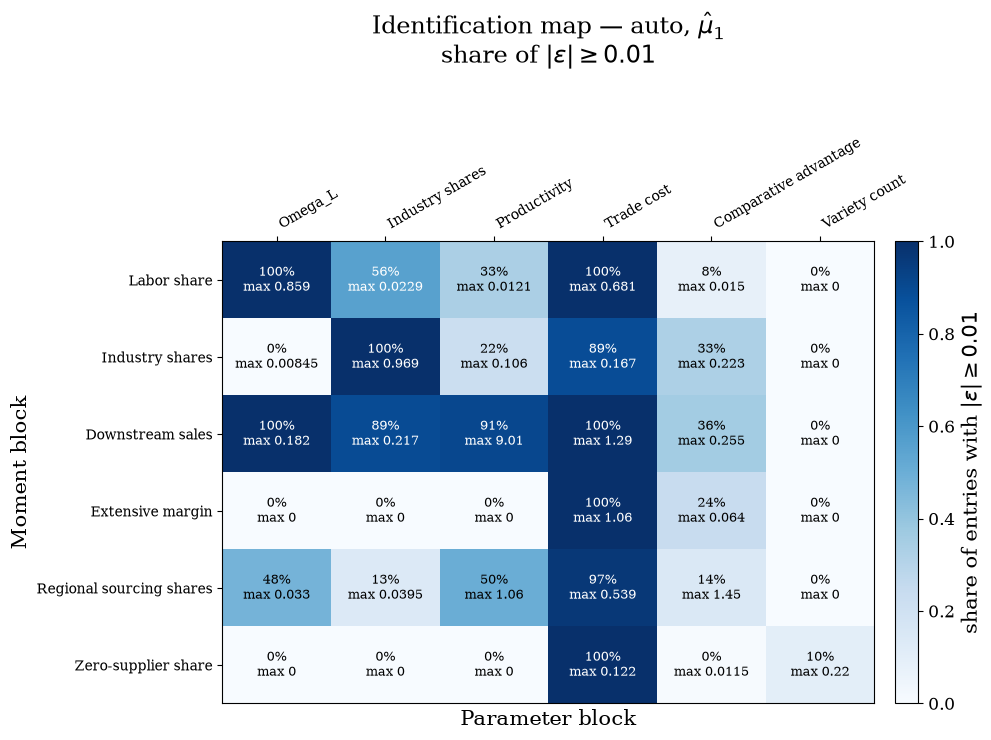

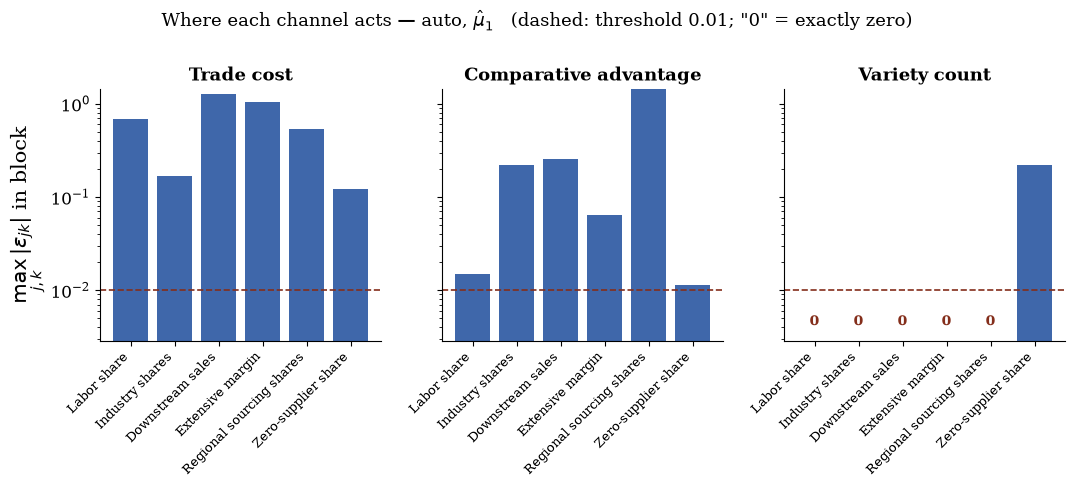

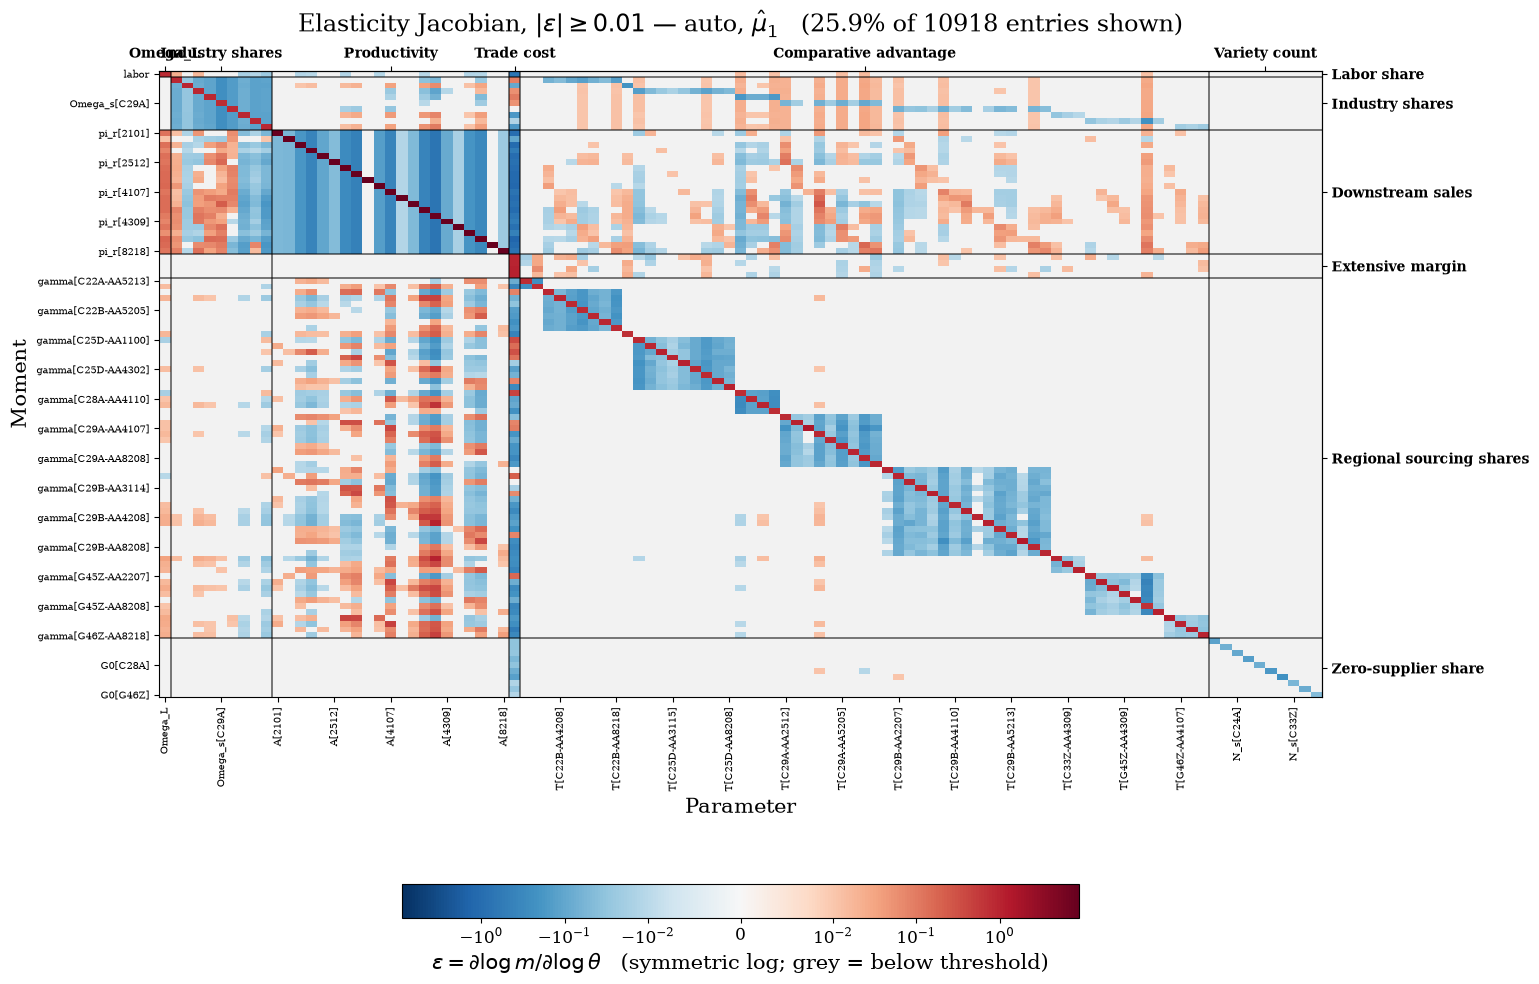

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                  1.00000        0.555556     0.333333   1.000000   
Industry shares              0.00000        1.000000     0.222222   0.888889   
Downstream sales             1.00000        0.894180     0.909297   1.000000   
Extensive margin             0.00000        0.000000     0.000000   1.000000   
Regional sourcing shares     0.47541        0.132969     0.500390   0.967213   
Zero-supplier share          0.00000        0.000000     0.000000   1.000000   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.081967           0.0  0.858649   
Industry shares                       0.327869           0.0  0.008448   
Downstream sales                      0.356753           0.0  0.181767   
Extensive margin                      0.237705           0.0  0.000000   
Regional sourcing shares              0.144854           0.0  0.033015   
Zero-supplier share                   0.004918           0.1  0.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.022929     0.012075   0.680994  ...   
Industry shares                 0.969008     0.106046   0.167416  ...   
Downstream sales                0.217295     9.009067   1.285614  ...   
Extensive margin                0.000000     0.000000   1.055637  ...   
Regional sourcing shares        0.039492     1.062714   0.538999  ...   
Zero-supplier share             0.000000     0.000000   0.121580  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.007538   0.680994              0.003700   
Industry shares              0.009533   0.081819              0.012582   
Downstream sales             0.594856   0.866119              0.012048   
Extensive margin             0.000000   1.012969              0.007322   
Regional sourcing shares     0.036677   0.185621              0.025977   
Zero-supplier share          0.000000   0.043223              0.000269   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.010555              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   
Zero-supplier share               1.0       

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


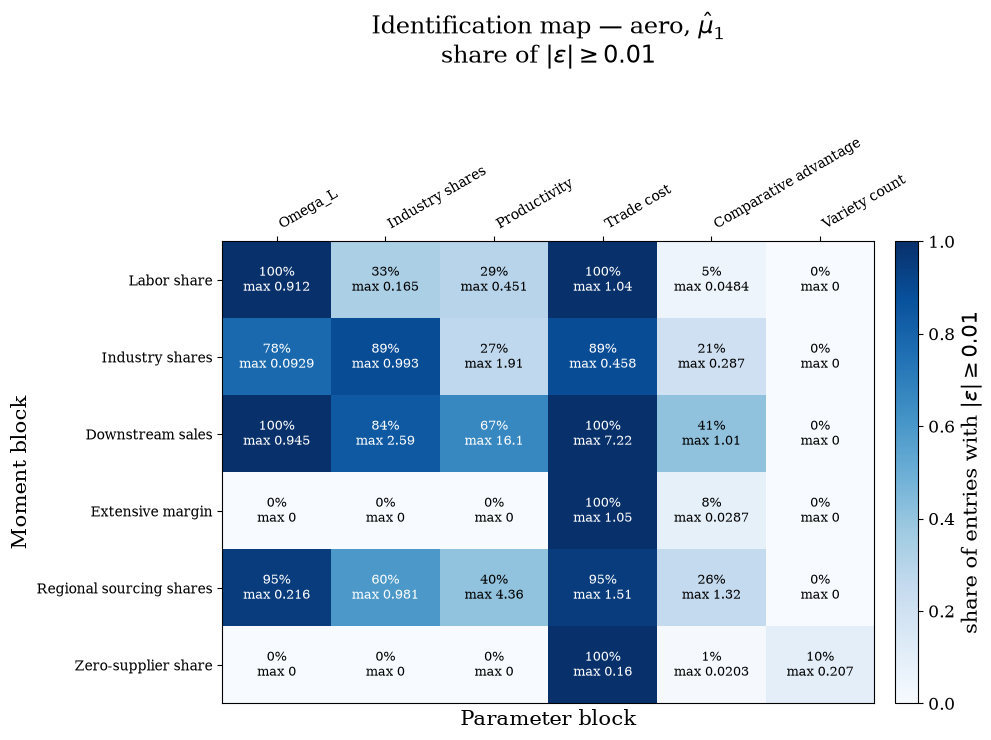

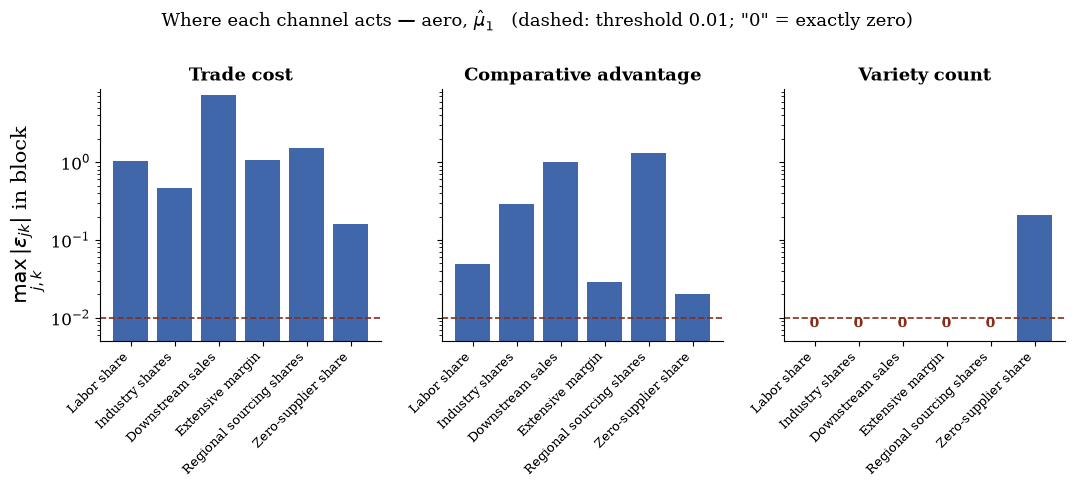

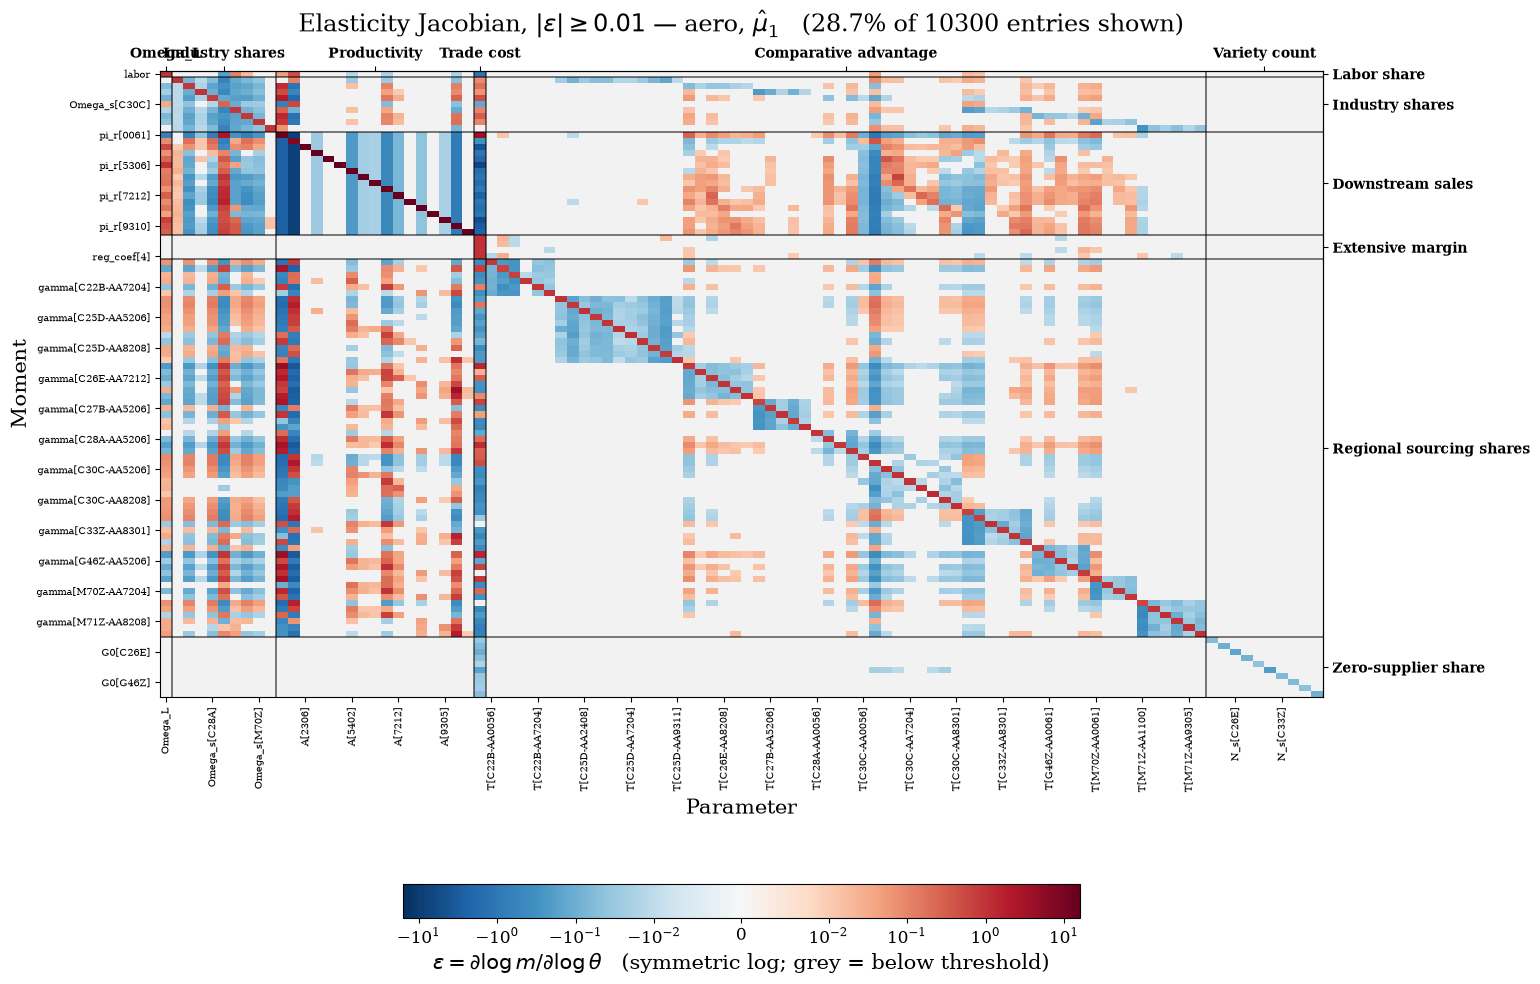

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.333333     0.294118   1.000000   
Industry shares             0.777778        0.888889     0.267974   0.888889   
Downstream sales            1.000000        0.843137     0.667820   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.951613        0.596774     0.403226   0.951613   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.048387           0.0  0.912378   
Industry shares                       0.206093           0.0  0.092901   
Downstream sales                      0.408918           0.0  0.944780   
Extensive margin                      0.084677           0.0  0.000000   
Regional sourcing shares              0.256243           0.0  0.215825   
Zero-supplier share                   0.008065           0.1  0.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.164725     0.451356   1.044062  ...   
Industry shares                 0.993203     1.906907   0.458071  ...   
Downstream sales                2.594201    16.067859   7.220540  ...   
Extensive margin                0.000000     0.000000   1.048545  ...   
Regional sourcing shares        0.981214     4.357829   1.506045  ...   
Zero-supplier share             0.000000     0.000000   0.160068  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.033729   1.044062              0.002589   
Industry shares              0.100308   0.160491              0.009673   
Downstream sales             1.607484   2.359391              0.033634   
Extensive margin             0.000000   1.031279              0.004172   
Regional sourcing shares     0.179437   0.366594              0.028866   
Zero-supplier share          0.000000   0.056556              0.000318   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.009029              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   
Zero-supplier share               1.0       

In [17]:

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Identification: elasticities, variety counts included ---------------
    data_ext = with_variety_counts(data)
    plot_identification_map(
        data_ext, threshold=IDENT_THRESHOLD,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data_ext, threshold=IDENT_THRESHOLD,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data_ext, threshold=IDENT_THRESHOLD,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data_ext, threshold=IDENT_THRESHOLD))


# Untargeted moment — the distance elasticity of spatial comovement

The estimation targets the spatial decay of production **linkages** (moment block 4).
It does not target how the equilibrium network turns those linkages into the spatial
propagation of downstream shocks. The reduced-form ratio $\delta/\gamma$ of Table 3
measures the latter, and Appendix B.5 shows it identifies

$$\frac{\partial \log \mathbb{E}\!\left[a_{ir}\mid s, r', \mathrm{Dist}_{r'r}=d\right]}{\partial \log d},$$

where $a_{ir}$ is the share of supplier $i$'s sales directed to downstream region $r$.
The model counterpart is therefore obtained by computing $a_{ir}$ in the simulated
economy and estimating by PPML

$$\mathbb{E}\!\left[a_{ir}\mid s, r', r\right] \;=\; \exp\!\big(\alpha_{r,s(i)} + \eta \log \mathrm{Dist}_{r'r}\big),$$

with $\alpha_{r,s(i)}$ a sector $\times$ downstream-region fixed effect. $\hat\eta$ is
directly comparable to $\delta/\gamma$, and nothing in the criterion was asked to match
it — which is what makes it a test rather than a fit.

**Why PPML and not a log-linear regression.** Slightly more than half of the
supplier $\times$ downstream-region cells are zeros, and those zeros *are* the object:
the first of the two forces inside $\eta$ is the extensive margin ($\Lambda$ — a more
distant supplier is less likely to serve the region at all). Taking logs would delete
them. Poisson pseudo-ML is consistent for the conditional **mean** under the exponential
specification alone, so $a_{ir}$ need not be a count, and the zeros enter unmodified.
The second force is the portfolio term $(1-a)$: as the distance to $r$ grows, the
supplier's other downstream regions take a larger share of its sales.
`decompose_untargeted_moment` separates the two.

**Two things to know before reading the output.**

1. The estimator here is self-contained (`ppml_absorb`): Poisson PML with one absorbed
   fixed effect, profiled out in closed form and solved by Newton, i.e. `ppmlhdfe`
   specialised to one FE dimension. It is gated against `statsmodels`' Poisson GLM with
   explicit dummies (identical $\hat\beta$ and classical SEs) and, when it is installed,
   against `pyfixest.fepois`. So the notebook does not depend on `pyfixest`.
2. `main.jl`'s post-hoc block runs at **both** estimates and writes
   `suppliers.parquet` into the step folder of the estimate it was computed at
   (`step1/` for $\hat\theta_1$, `step3/` for $\hat\theta_2$), so `mu` selects the
   firm-level economy exactly as it selects the moments and the inference. On an older
   run tree there is a single copy at the run root, computed at $\hat\theta_1$; the
   loader falls back to it and `data["suppliers_path"]` says which file was read.

In [18]:
# =============================================================================
# Untargeted moment — the distance elasticity of spatial comovement.
#
# The estimation targets the spatial decay of production LINKAGES (block 4, the
# extensive-margin coefficients). It does not target how the equilibrium network
# translates those linkages into the spatial propagation of downstream shocks. The
# reduced-form ratio delta/gamma of Table 3 measures the latter, and Appendix B.5
# shows it identifies
#
#       d log E[a_ir | s, r', Dist_{r'r} = d] / d log d,
#
# where a_ir is the share of supplier i's sales directed to downstream region r. So
# the model counterpart is obtained by computing a_ir in the simulated economy and
# estimating, by PPML,
#
#       E[a_ir | s, r', r] = exp( alpha_{r,s(i)} + eta * log Dist_{r'r} ),
#
# with alpha_{r,s(i)} a sector x downstream-region fixed effect. `eta` is directly
# comparable to the empirical delta/gamma, and NOTHING in the estimation was asked
# to match it.
#
# Two forces are inside eta (Appendix B.5): the EXTENSIVE margin — a more distant
# supplier is less likely to serve the region at all (the Lambda term) — and a
# PORTFOLIO effect — as the distance to r grows the other downstream regions take a
# larger share of the supplier's sales (the 1 - a term). `decompose_untargeted_moment`
# splits eta along those two lines.
#
# Where the data comes from. `main.jl` writes `<run>/suppliers.parquet` from
# `solve_network(..., return_firm_level=true)`: one row per (simulated firm,
# downstream region) LINKAGE, with `share` = the firm's share of that region's
# input purchases and `downstream_purchase` = mu * Y_r. A "firm" is a (cell, sector,
# variety) triple, i.e. one variety producer, which is the model's supplier.
#
# The post-hoc block runs at BOTH estimates and writes into the step folder of the one
# it was computed at, so `mu` picks the firm-level economy the same way it picks the
# moments. An older run tree has one copy at the run root, computed at theta_hat_1;
# the loader falls back to it, and `data["suppliers_path"]` records what was read.
# =============================================================================


def build_a_ir_panel(data, min_distance_km=1.0):
    """
    The (supplier x downstream region) panel the PPML runs on, ZERO-FILLED.

    `suppliers.parquet` records only realised linkages. The regression needs the
    non-linkages too — a supplier that does not serve region r has a_ir = 0, and
    that extensive margin is half of what the moment measures — so every supplier
    is crossed with every downstream region and the missing cells are filled at 0.

    The sample is suppliers, i.e. varieties that win somewhere, which is the
    conditioning `Sup_i = 1` of equation (3) and of (B36).

    Region codes in `suppliers.parquet` are the model's own 1..R indices for BOTH
    `ze2010` (the supplier's cell) and `ze2010_downstream` (the buyer), so the
    distance is read straight out of `distances.npy` with no name round-trip.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir', '<step>')}/ or "
            f"{data['folder']}/ (or it was unreadable — pyarrow missing?). main.jl "
            "writes one per estimate in its post-hoc block, after the estimation.")

    dist_path = data["input_folder"] / "distances.npy"
    if not dist_path.exists():
        raise FileNotFoundError(f"{dist_path} not found — needed for log Dist_{{r'r}}.")
    D = np.load(dist_path)
    R = data["R"]
    if D.shape[0] < R or D.shape[1] < R:
        raise ValueError(f"distances.npy is {D.shape}, too small for R = {R} regions.")
    D = D[:R, :R]

    df = sup[["SIREN", "A129", "ze2010", "ze2010_downstream",
              "share", "downstream_purchase", "productivity", "sample_weight"]].copy()

    # X_{i->r} = share x (mu Y_r); a_ir = X_{i->r} / sum_r X_{i->r}
    df["X_ir"] = df["share"] * df["downstream_purchase"]
    tot = df.groupby("SIREN", sort=False)["X_ir"].transform("sum")
    df["a_ir"] = np.where(tot > 0, df["X_ir"] / tot, 0.0)

    # --------------------------------------------------------- zero-filling ---
    firms = df.groupby("SIREN", sort=True).agg(
        A129=("A129", "first"), ze2010=("ze2010", "first"),
        productivity=("productivity", "first"),
        sample_weight=("sample_weight", "first")).reset_index()
    downstream = np.sort(df["ze2010_downstream"].unique())

    panel = firms.merge(pd.DataFrame({"ze2010_downstream": downstream}), how="cross")
    panel = panel.merge(df[["SIREN", "ze2010_downstream", "a_ir"]],
                        on=["SIREN", "ze2010_downstream"], how="left")
    panel["a_ir"] = panel["a_ir"].fillna(0.0)

    # ------------------------------------------------------------ regressors --
    # log max(d, 1) is the model's own convention (load_parameters.jl builds
    # LOG_DIST_DOWNSTREAM the same way), so the own-region cell is log 1 = 0 rather
    # than -inf.
    d = D[panel["ze2010"].to_numpy() - 1, panel["ze2010_downstream"].to_numpy() - 1]
    panel["distance"] = d
    panel["log_distance"] = np.log(np.maximum(d, min_distance_km))
    panel["log_productivity"] = np.log(np.maximum(panel["productivity"].to_numpy(), 1e-300))
    # alpha_{r, s(i)} : sector x downstream-region
    panel["fe_group"] = (panel["A129"].astype(str) + "-"
                         + panel["ze2010_downstream"].astype(str))
    panel["cluster"] = panel["ze2010"].astype(str)     # supplier's region, as in Table 3
    return panel


def ppml_absorb(y, X, group, w=None, cluster=None, tol=1e-9, max_iter=100):
    """
    Poisson pseudo-maximum-likelihood with ONE absorbed fixed effect.

    The model is E[y_i] = exp(a_{g(i)} + x_i'b) with frequency weights w_i. The
    fixed effect has a closed form at any b — the group score sum_{i in g} w_i
    (y_i - mu_i) = 0 gives

        exp(a_g) = sum_{i in g} w_i y_i / sum_{i in g} w_i exp(x_i'b),

    so a_g is profiled out exactly and Newton runs on b alone. Substituting it back,
    the score and Hessian of the concentrated objective are the mu-weighted WITHIN
    transforms

        s(b) = sum_i w_i (y_i - mu_i) (x_i - xbar_g),
        H(b) = sum_i w_i mu_i (x_i - xbar_g)(x_i - xbar_g)',
        xbar_g = sum_{i in g} w_i mu_i x_i / sum_{i in g} w_i mu_i,

    which is the Correia-Guimaraes-Zylkin `ppmlhdfe` algorithm specialised to a
    single fixed-effect dimension. Poisson PML is consistent for the conditional
    MEAN under the exponential specification alone — y need not be a count, and the
    shares here are not — which is exactly why the paper estimates the moment this
    way rather than by log-linear OLS (which would drop the zeros).

    Groups with sum_i w_i y_i = 0 are SEPARATED (their fixed effect is -inf, they
    contribute nothing to the score) and are dropped, as ppmlhdfe does.

    Returns beta, cluster-robust or classical standard errors, and the diagnostics.
    """
    y = np.asarray(y, dtype=float).ravel()
    X = np.atleast_2d(np.asarray(X, dtype=float))
    if X.shape[0] != y.size:
        X = X.T
    n, k = X.shape
    w = np.ones(n) if w is None else np.asarray(w, dtype=float).ravel()

    g_idx = pd.factorize(np.asarray(group), sort=True)[0]
    n_g = g_idx.max() + 1
    S_wy = np.bincount(g_idx, weights=w * y, minlength=n_g)

    keep = S_wy[g_idx] > 0
    n_dropped_groups = int((S_wy <= 0).sum())
    if not keep.all():
        y, X, w, g_idx = y[keep], X[keep], w[keep], g_idx[keep]
        g_idx = pd.factorize(g_idx, sort=True)[0]
        n_g = g_idx.max() + 1
        S_wy = np.bincount(g_idx, weights=w * y, minlength=n_g)
        if cluster is not None:
            cluster = np.asarray(cluster)[keep]
    n = y.size

    # centring the regressors moves the fixed effect, never beta, and keeps
    # exp(x'b) near one
    Xc = X - (w[:, None] * X).sum(0) / w.sum()

    def _state(b):
        """mu, the mu-weighted within-transformed regressors, the score and the Hessian."""
        e = np.exp(np.clip(Xc @ b, -500, 500))
        S_we = np.bincount(g_idx, weights=w * e, minlength=n_g)
        mu = S_wy[g_idx] / np.maximum(S_we[g_idx], 1e-300) * e
        wmu = w * mu
        S_wmu = np.maximum(np.bincount(g_idx, weights=wmu, minlength=n_g), 1e-300)
        xbar = np.column_stack([np.bincount(g_idx, weights=wmu * Xc[:, j], minlength=n_g)
                                for j in range(k)]) / S_wmu[:, None]
        Xt = Xc - xbar[g_idx]
        resid = y - mu
        return mu, Xt, resid, Xt.T @ (w * resid), Xt.T @ (wmu[:, None] * Xt)

    beta = np.zeros(k)
    for it in range(1, max_iter + 1):
        _, _, _, score, H = _state(beta)
        step = np.linalg.solve(H, score)
        beta = beta + step
        if np.max(np.abs(step)) < tol:
            break
    else:
        raise RuntimeError(f"ppml_absorb did not converge in {max_iter} Newton steps "
                           f"(last step {np.max(np.abs(step)):.3g}).")
    # everything below is evaluated AT the converged beta, not one step behind
    mu, Xt, resid, score, H = _state(beta)

    Hinv = np.linalg.inv(H)
    if cluster is None:
        # classical Poisson PML variance
        V, vcov_type, n_clusters = Hinv, "classical", None
    else:
        c_idx = pd.factorize(np.asarray(cluster), sort=True)[0]
        n_clusters = c_idx.max() + 1
        u = w[:, None] * resid[:, None] * Xt
        U = np.zeros((n_clusters, k))
        for j in range(k):
            U[:, j] = np.bincount(c_idx, weights=u[:, j], minlength=n_clusters)
        # CRV1, with fixest's small-sample correction (the fixed effects count
        # toward K); at n >> n_g the correction is immaterial
        K = k + n_g
        corr = (n_clusters / max(n_clusters - 1, 1)) * ((n - 1) / max(n - K, 1))
        V, vcov_type = Hinv @ (U.T @ U) @ Hinv * corr, "CRV1"

    se = np.sqrt(np.maximum(np.diag(V), 0.0))
    return {"beta": beta, "se": se, "vcov": V, "hessian": H, "iterations": it,
            "n_obs": n, "n_groups": n_g, "n_clusters": n_clusters,
            "n_dropped_groups": n_dropped_groups, "vcov_type": vcov_type,
            "deviance_resid_sum": float(np.sum(w * resid))}

In [19]:
# =============================================================================
# The moment itself: eta, its decomposition, and the comparison with delta/gamma.
# =============================================================================

# Empirical delta/gamma from Table 3 (equation (3), the spatial comovement
# regression): point estimate and 95% CI. These are DATA, not model output, and
# they are not read from any file in this repository — override them here if the
# reduced-form estimates change.
EMPIRICAL_DELTA_OVER_GAMMA = {
    "auto": {"estimate": -0.109, "ci_lo": -0.122, "ci_hi": -0.096,
             "display_name": "Motor Vehicles"},
    "aero": {"estimate": -0.098, "ci_lo": -0.130, "ci_hi": -0.065,
             "display_name": "Aerospace"},
}


def estimate_untargeted_moment(data, controls=(), cluster="cluster", panel=None,
                               verbose=True):
    """
    PPML estimate of eta in E[a_ir] = exp(alpha_{r,s(i)} + eta log Dist_{r'r}).

    `controls` adds columns of the panel to the right-hand side (the paper's
    specification has none; `("log_productivity",)` conditions on the supplier's
    productivity draw). `cluster=None` gives the classical Poisson variance.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    cols = ["log_distance"] + list(controls)
    fit = ppml_absorb(panel["a_ir"].to_numpy(),
                      panel[cols].to_numpy(),
                      panel["fe_group"].to_numpy(),
                      w=panel["sample_weight"].to_numpy(),
                      cluster=None if cluster is None else panel[cluster].to_numpy())

    eta, se = float(fit["beta"][0]), float(fit["se"][0])
    emp = EMPIRICAL_DELTA_OVER_GAMMA.get(data["industry"], {})
    out = {"industry": data["industry"], "mu": data["mu"], "spec": "+".join(cols),
           "eta": eta, "se": se, "t": eta / se if se > 0 else np.nan,
           "ci_lo": eta - 1.96 * se, "ci_hi": eta + 1.96 * se,
           "coefs": dict(zip(cols, fit["beta"])), "ses": dict(zip(cols, fit["se"])),
           "n_obs": fit["n_obs"], "n_firms": int(panel["SIREN"].nunique()),
           "n_groups": fit["n_groups"], "n_clusters": fit["n_clusters"],
           "n_dropped_groups": fit["n_dropped_groups"],
           "iterations": fit["iterations"], "vcov_type": fit["vcov_type"],
           "share_zero": float((panel["a_ir"].to_numpy() == 0).mean()),
           "emp_estimate": emp.get("estimate"), "emp_ci_lo": emp.get("ci_lo"),
           "emp_ci_hi": emp.get("ci_hi"), "panel": panel}

    if verbose:
        print(f"[{data['industry']}]  eta = {eta:+.4f}  (se {se:.4f}, "
              f"{fit['vcov_type']}, {fit['n_clusters']} clusters)   "
              f"95% CI [{out['ci_lo']:+.4f}, {out['ci_hi']:+.4f}]")
        if out["emp_estimate"] is not None:
            print(f"            delta/gamma in the data = {out['emp_estimate']:+.4f} "
                  f"[{out['emp_ci_lo']:+.4f}, {out['emp_ci_hi']:+.4f}]")
        print(f"            {out['n_obs']:,} supplier x downstream-region cells, "
              f"{out['n_firms']:,} suppliers, {100 * out['share_zero']:.1f}% zeros, "
              f"{fit['n_groups']} sector x downstream-region FE"
              + (f" ({fit['n_dropped_groups']} dropped: no sales at all)"
                 if fit["n_dropped_groups"] else ""))
        path = data.get("suppliers_path")
        if path is not None:
            at_root = path.parent == data["folder"]
            print(f"            from {path}"
                  + ("   NOTE: run-root copy — an older tree writes it at theta_hat_1 "
                     f"only, so this is NOT the mu = {data['mu']} economy."
                     if at_root and data["mu"] != 1 else ""))
    return out


def decompose_untargeted_moment(data, panel=None, cluster="cluster", verbose=True):
    """
    eta split into the two forces of Appendix B.5.

    E[a_ir] = P(i serves r) x E[a_ir | i serves r], so with a log link the elasticity
    of the product is the sum of the elasticities:

        eta ~= eta_ext + eta_int,
        eta_ext : the Lambda term — a more distant supplier is less likely to serve
                  the region at all (PPML on the 0/1 linkage indicator),
        eta_int : the (1 - a) portfolio term — conditional on serving, distance
                  reallocates the supplier's sales toward the other regions
                  (PPML on the positive a_ir).

    APPROXIMATE, and deliberately labelled so: the three regressions absorb their own
    fixed effects, so the identity holds exactly only when the fixed effects are
    common. The gap is reported so its size can be judged rather than assumed.
    """
    panel = build_a_ir_panel(data) if panel is None else panel
    a = panel["a_ir"].to_numpy()
    x = panel[["log_distance"]].to_numpy()
    g, w = panel["fe_group"].to_numpy(), panel["sample_weight"].to_numpy()
    c = None if cluster is None else panel[cluster].to_numpy()
    pos = a > 0

    total = ppml_absorb(a, x, g, w=w, cluster=c)
    ext = ppml_absorb((a > 0).astype(float), x, g, w=w, cluster=c)
    inte = ppml_absorb(a[pos], x[pos], g[pos], w=w[pos],
                       cluster=None if c is None else c[pos])

    rows = [("eta (total)", total), ("eta_ext (extensive: Lambda)", ext),
            ("eta_int (intensive: portfolio)", inte)]
    df = pd.DataFrame([{"channel": name, "coefficient": float(f["beta"][0]),
                        "se": float(f["se"][0]), "n_obs": f["n_obs"]}
                       for name, f in rows])
    gap = float(total["beta"][0] - ext["beta"][0] - inte["beta"][0])
    if verbose:
        print(df.to_string(index=False))
        print(f"  eta - (eta_ext + eta_int) = {gap:+.4f}   "
              "(exactly zero only under common fixed effects)")
    return {"table": df, "gap": gap, "total": total, "extensive": ext,
            "intensive": inte}


def untargeted_summary(results):
    """Model eta against the empirical delta/gamma, one row per industry."""
    rows = []
    for r in results:
        emp = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
        rows.append({
            "industry": emp.get("display_name", r["industry"]),
            "eta (model)": r["eta"],
            "se": r["se"],
            "95% CI (model)": f"[{r['ci_lo']:+.3f}, {r['ci_hi']:+.3f}]",
            "delta/gamma (data)": r["emp_estimate"],
            "95% CI (data)": (f"[{r['emp_ci_lo']:+.3f}, {r['emp_ci_hi']:+.3f}]"
                              if r["emp_ci_lo"] is not None else "---"),
            "inside data CI": (None if r["emp_ci_lo"] is None
                               else bool(r["emp_ci_lo"] <= r["eta"] <= r["emp_ci_hi"])),
            "suppliers": r["n_firms"], "cells": r["n_obs"],
        })
    return pd.DataFrame(rows).set_index("industry")


def plot_untargeted_moment(results, figsize=None, save_to=None):
    """
    The untargeted-moment figure: model eta against the empirical delta/gamma, with
    both confidence intervals, one pair per industry.

    What the paper claims of this picture is the SIGN and the cross-industry
    RANKING, not a hit inside the data's interval — nothing in the criterion was
    asked to match this number.
    """
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.75, hf=0.65))
    x = np.arange(len(results))
    off = 0.13

    for i, r in enumerate(results):
        ax.errorbar(x[i] - off, r["eta"],
                    yerr=[[r["eta"] - r["ci_lo"]], [r["ci_hi"] - r["eta"]]],
                    fmt="o", color=sim_color, capsize=4, markersize=7,
                    label="Model $\\hat\\eta$" if i == 0 else None)
        if r["emp_estimate"] is not None:
            ax.errorbar(x[i] + off, r["emp_estimate"],
                        yerr=[[r["emp_estimate"] - r["emp_ci_lo"]],
                              [r["emp_ci_hi"] - r["emp_estimate"]]],
                        fmt="s", color=reference_color, capsize=4, markersize=7,
                        label="Data $\\delta/\\gamma$" if i == 0 else None)

    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xlim(-0.5, len(results) - 0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {})
                        .get("display_name", r["industry"]) for r in results])
    ax.set_ylabel("Distance elasticity of comovement")
    ax.legend(frameon=False, loc="best")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_a_ir_profile(results, bins=(0, 50, 100, 150, 200, 300, np.inf),
                      figsize=None, save_to=None):
    """
    The shape behind eta: the fitted E[a_ir] by distance bin, per industry, from the
    same PPML but with bin dummies in place of log distance (so nothing is imposed
    on the functional form). Plotted relative to the nearest bin, which is the
    reference the log specification implicitly compares against.
    """
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.85, hf=0.6))
    labels = None
    palette = [sim_color, reference_color, (0.3, 0.5, 0.3), (0.5, 0.4, 0.6)]
    for i_r, r in enumerate(results):
        panel = r["panel"]
        cats = pd.cut(panel["distance"], bins=list(bins), right=False)
        codes = pd.factorize(cats, sort=True)
        labels = [f"{int(iv.left)}-{'+' if np.isinf(iv.right) else int(iv.right)}"
                  for iv in codes[1]]
        Dm = np.eye(len(codes[1]))[codes[0]][:, 1:]        # first bin = reference
        fit = ppml_absorb(panel["a_ir"].to_numpy(), Dm, panel["fe_group"].to_numpy(),
                          w=panel["sample_weight"].to_numpy(),
                          cluster=panel["cluster"].to_numpy())
        b = np.concatenate([[0.0], fit["beta"]])
        se = np.concatenate([[0.0], fit["se"]])
        name = EMPIRICAL_DELTA_OVER_GAMMA.get(r["industry"], {}).get(
            "display_name", r["industry"])
        ax.errorbar(np.arange(len(b)), b, yerr=1.96 * se, marker="o", capsize=3,
                    color=palette[i_r % len(palette)], label=name)

    ax.axhline(0.0, color="0.6", linewidth=0.8)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Distance to the downstream region (km)")
    ax.set_ylabel(r"$\log E[a_{ir}]$ relative to the nearest bin")
    ax.legend(frameon=False)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference
[auto]  eta = -0.6857  (se 0.0671, CRV1, 267 clusters)   95% CI [-0.8172, -0.5543]
            delta/gamma in the data = -0.1090 [-0.1220, -0.0960]
            96,426 supplier x downstream-region cells, 4,383 suppliers, 33.6% zeros, 220 sector x downstream-region FE
            from ../reporting_auto_profiled_aa_gran_pso/suppliers.parquet
                       channel  coefficient       se  n_obs
                   eta (total)    -0.685749 0.067077  96426
   eta_ext (extensive: Lambda)    -0.220000 0.014542  96426
eta_int (intensive: portfolio)    -0.480192 0.062014  64020
  eta - (eta_ext + eta_int) = +0.0144   (exactly zero only under common fixed effects)
aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


[aero]  eta = -0.9171  (se 0.0629, CRV1, 235 clusters)   95% CI [-1.0403, -0.7938]
            delta/gamma in the data = -0.0980 [-0.1300, -0.0650]
            347,526 supplier x downstream-region cells, 19,307 suppliers, 62.6% zeros, 180 sector x downstream-region FE
            from ../reporting_aero_profiled_aa_gran_pso/suppliers.parquet
                       channel  coefficient       se  n_obs
                   eta (total)    -0.917080 0.062874 347526
   eta_ext (extensive: Lambda)    -0.540513 0.013804 347526
eta_int (intensive: portfolio)    -0.490767 0.066525 130140
  eta - (eta_ext + eta_int) = +0.1142   (exactly zero only under common fixed effects)


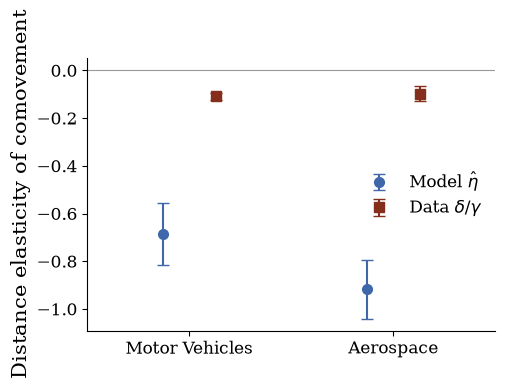

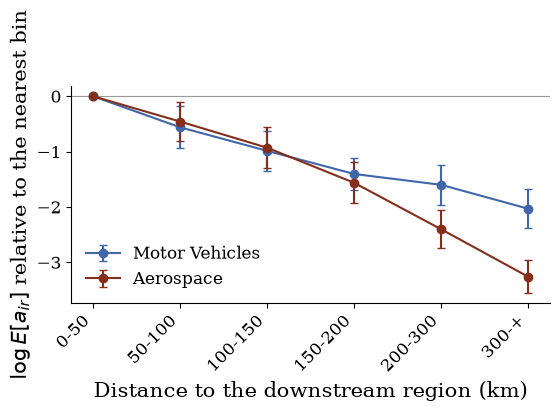

,eta (model),se,95% CI (model),delta/gamma (data),95% CI (data),inside data CI,suppliers,cells
industry,,,,,,,,
Motor Vehicles,-0.685749,0.067077,"[-0.817, -0.554]",-0.109,"[-0.122, -0.096]",False,4383,96426
Aerospace,-0.917080,0.062874,"[-1.040, -0.794]",-0.098,"[-0.130, -0.065]",False,19307,347526


In [20]:

untargeted_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Untargeted moment: the PPML distance elasticity of comovement -------
    untargeted_results.append(estimate_untargeted_moment(data))
    decompose_untargeted_moment(data, panel=untargeted_results[-1]["panel"])

# --- Untargeted moment: model eta against the reduced-form delta/gamma -------
plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_a_ir_profile(untargeted_results,
                  save_to=f"{out_folder}/untargeted_profile_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))

# Comparative advantage against distance, within a sector

Inside a sector two forces decide which upstream cell wins a variety for a given
downstream buyer: comparative advantage $T_{as}$, which is constant within an
attraction area, and the trade cost $\tau = d^{\alpha}$. With Fréchet productivity and
wages normalised to one, the Ricardian competition has a closed form,

$$\rho_{l r s} = \frac{\psi_{l r s}}{\sum_{l'} \psi_{l' r s}}, \qquad
\psi_{l r s} = T_{a(l)s}\, d_{lr}^{-\theta\alpha},$$

so on a log scale the two forces are **additive and directly commensurable**:

$$\log \psi_{l r s} = \log T_{a(l)s} \;-\; \theta\alpha \log d_{lr}.$$

Three things follow, and they are what this section measures.

**1. What a comparative-advantage gap is worth in distance.** Area $a$ beats area $a'$
at buyer $r$ iff $\log T_a - \log T_{a'} > \theta\alpha(\log d_{ar} - \log d_{a'r})$, so a
gap of $\Delta$ is offset by a distance ratio of $\exp\!\big(\Delta/(\theta\alpha)\big)$ —
how many times further the favoured area can sit and still win. Comparing that with the
distance the geography actually offers answers the question directly: if Toulouse's edge
in aerospace exceeds the spread of distances buyers face, no location in the country
compensates for it and Toulouse supplies every downstream region.

**2. Which force does the work.** Because $\log\psi$ is a sum, its dispersion across the
cells competing for a buyer splits *exactly*:

$$\operatorname{Var}(\log\psi) = \operatorname{Var}(\log T) + (\theta\alpha)^2\operatorname{Var}(\log d) - 2\theta\alpha\operatorname{Cov}(\log T, \log d).$$

$\operatorname{sd}(\log T)$ against $\theta\alpha\operatorname{sd}(\log d)$ is the
like-for-like comparison. The covariance term says whether the two reinforce each other
or pull apart — negative means the favoured area is also the close one.

**3. Switching one force off.** $\rho$ is closed form, so the allocation of winners can
be recomputed with comparative advantage equalised within the sector (distance only) or
with $\alpha = 0$ (comparative advantage only), against a uniform benchmark. No
re-simulation is involved.

Everything is computed from the estimated $\hat T$ and $\hat\alpha$ in `best_params`, the
distance matrix and $\theta$ — exact rather than Monte-Carlo, and available at either
`mu`. It assumes the $N_{\tau} = 1$ power law $\tau = d^{\alpha}$; under a binned trade
cost there is no single distance elasticity to trade off against $T$, and the functions
refuse to run rather than report the first bin's coefficient.

In [21]:
# =============================================================================
# Comparative advantage within a sector — and how it trades off against distance.
#
# Inside a sector, two forces decide which upstream cell wins a variety for a given
# downstream buyer: comparative advantage T_{a,s} (constant within an attraction
# area) and the trade cost tau = d^alpha. The Ricardian competition makes that
# trade-off explicit. With Frechet productivity and wages normalised to one, the
# probability that cell l supplies buyer r in sector s is the closed form
#
#       rho_{l,r,s} = psi_{l,r,s} / sum_{l'} psi_{l',r,s},
#       psi_{l,r,s} = T_{a(l),s} * d_{l,r}^{-theta*alpha},
#
# so on a log scale the two forces are ADDITIVE and directly commensurable:
#
#       log psi_{l,r,s} = log T_{a(l),s} - theta*alpha*log d_{l,r}.
#
# Three consequences, and they are what this section measures.
#
# 1. DISTANCE-EQUIVALENCE. Area a beats area a' at buyer r iff
#       log T_a - log T_a' > theta*alpha*(log d_{a,r} - log d_{a',r}),
#    so a comparative-advantage gap of Delta is worth a distance ratio of
#       exp(Delta / (theta*alpha))
#    — how many times further the favoured area can sit and still win. Comparing
#    that ratio with the geographic RANGE actually available (the spread of
#    log distances in France) settles the question directly: if the gap exceeds the
#    range, no location in the country can offset it and the favoured area wins
#    everywhere, whatever the buyer.
#
# 2. VARIANCE DECOMPOSITION. Because log psi is a sum, its variance over
#    (cell, buyer) pairs splits exactly:
#       Var(log psi) = Var(log T) + (theta*alpha)^2 Var(log d)
#                      - 2*theta*alpha*Cov(log T, log d),
#    with no approximation. sd(log T) against theta*alpha*sd(log d) is the
#    like-for-like comparison of the two forces' pull.
#
# 3. COUNTERFACTUALS. rho is closed form, so the allocation of winners can be
#    recomputed with one force switched off — T constant within sector (distance
#    only), or alpha = 0 (comparative advantage only) — with no re-simulation.
#
# Everything here is computed from the ESTIMATED T and alpha in `best_params`, the
# distance matrix and theta. Nothing is read from the simulation, so it is exact
# rather than Monte-Carlo, and it is available at either mu.
#
# CALIBRATION NOTE: this uses tau = d^alpha, the N_TAU == 1 power law. Under a
# binned trade cost (N_TAU > 1) tau is a step function of distance and the
# distance-equivalence in (1) has no single elasticity; the functions below refuse
# to run rather than silently report the first bin's coefficient.
# Regional wages are normalised to one in this calibration (load_parameters.jl
# collapses w_rs), which is why they do not appear in psi.
# =============================================================================

# Frechet shape parameter: read from stats.csv when it happens to carry a `theta`
# entry, else `THETA_DEFAULT` from the Constants cell. NOTE that `load_parameters.jl:63`
# sets theta = 1.768, and every theta*alpha-scaled quantity below — the distance
# equivalence, the variance decomposition, the win probabilities — moves with it.



def model_theta(data):
    v = _read_named_value(data["coefs"], "theta") if data.get("coefs") is not None else None
    return float(v) if v is not None and np.isfinite(v) and v > 0 else THETA_DEFAULT


def unpack_estimated_T(data):
    """
    The estimated comparative advantage, reference-normalised exactly as
    `unpack_params` does, plus alpha.

    `best_params` is the RAW theta vector, layout
        [Omega_L(1) | Omega_s(S) | A(R_d) | alpha(N_TAU) | T(active (s,AA), s-major)],
    where the T block carries EVERY active (sector, area) including each sector's
    reference — `unpack_params` divides the sector by its reference entry, which is
    what makes T_{ref,s} = 1 the gauge. The length is asserted against the rebuilt
    layout, so a flag mismatch is an error rather than a silently shifted vector.
    """
    bp = data.get("best_params")
    if bp is None:
        raise FileNotFoundError(
            f"no best_params in {data['folder']}/{data['step_dir']}/ — "
            "best_parameters_list.npy is written by run_reporting.")
    bp = np.asarray(bp, dtype=float).ravel()

    S, n_AA, n_tau = data["S"], data["n_AA"], data["n_tau"]
    AA_ACTIVE = data["AA_ACTIVE"]
    R_d = len(data["aa_names"])                       # one area per downstream region
    n_T = int(AA_ACTIVE.sum())
    expected = 1 + S + R_d + n_tau + n_T
    if bp.size != expected:
        raise ValueError(
            f"best_params has {bp.size} entries but the layout rebuilt here is "
            f"{expected} = 1 + {S} + {R_d} + {n_tau} + {n_T} — the run's flags and the "
            "ones passed here disagree.")

    alpha = bp[1 + S + R_d: 1 + S + R_d + n_tau]
    T = np.zeros((S, n_AA))
    T[AA_ACTIVE] = bp[1 + S + R_d + n_tau:]           # C-order on (S, n_AA) == s-major
    for s in range(S):
        ref = data["T_REF_AA"][s]
        if ref >= 0 and T[s, ref] > 0:
            T[s] = T[s] / T[s, ref]
    return {"T": T, "alpha": alpha, "theta": model_theta(data)}


def _downstream_ze_index(data):
    """The 1..R ZE index of each attraction area, in AA column order."""
    Nd = np.asarray(data["N_downstream"]).ravel()
    idx = np.flatnonzero(Nd != 0) + 1                 # 1-based, sorted — the model's order
    if idx.size != data["n_AA"]:
        raise ValueError(f"{idx.size} downstream regions in N_downstream_per_region.npy "
                         f"but {data['n_AA']} attraction areas.")
    return idx


def sourcing_geometry(data, alpha=None, equalise_T=False):
    """
    The exact Ricardian win probabilities `rho[s][l, r]` and the pieces they are
    built from, per sector.

    `alpha=0` switches the distance force off, `equalise_T=True` switches
    comparative advantage off — the two counterfactuals, both closed form.
    """
    est = unpack_estimated_T(data)
    if est["alpha"].size != 1:
        raise ValueError(
            f"N_TAU = {est['alpha'].size}: tau is binned, not the power law d^alpha, so "
            "there is no single distance elasticity to trade off against T. Re-run the "
            "reporting on an n_tau = 1 fit for this section.")
    a = float(est["alpha"][0]) if alpha is None else float(alpha)
    theta = est["theta"]

    D = np.load(data["input_folder"] / "distances.npy")[:data["R"], :data["R"]]
    down = _downstream_ze_index(data)
    aa_of_ze, CELL_MASK = data["aa_of_ze"], data["CELL_MASK"]

    out = {}
    for s in range(data["S"]):
        cells = np.flatnonzero(CELL_MASK[s])                       # 0-based ZE
        if cells.size == 0:
            continue
        T_cell = np.ones(cells.size) if equalise_T else est["T"][s, aa_of_ze[cells]]
        d = np.maximum(D[np.ix_(cells, down - 1)], 1.0)            # (n_cell, R_d)
        psi = T_cell[:, None] * d ** (-theta * a)
        tot = psi.sum(axis=0, keepdims=True)
        out[s] = {"cells": cells, "areas": aa_of_ze[cells], "T_cell": T_cell,
                  "distance": d, "log_psi": np.log(np.maximum(psi, 1e-300)),
                  "rho": np.divide(psi, tot, out=np.zeros_like(psi), where=tot > 0)}
    return {"by_sector": out, "alpha": a, "theta": theta, "T": est["T"],
            "alpha_hat": float(est["alpha"][0]), "downstream": down}

In [22]:
# =============================================================================
# The three measurements: the within-sector spread of T, the distance it is worth,
# and what the allocation of winners looks like with one force switched off.
# =============================================================================


def _buyer_weights(data):
    """Downstream buyers weighted by their purchases (the empirical pi_r target)."""
    w = np.asarray(data["emp_pi_r"], dtype=float).ravel()
    return w / w.sum()


def comparative_advantage_frame(data):
    """
    One row per (sector, active attraction area): the estimated T, its log deviation
    from the sector's median area, its rank, and how many cells the area contributes
    to that sector's competition.
    """
    est = unpack_estimated_T(data)
    aa_of_ze, CELL_MASK, AA_ACTIVE = data["aa_of_ze"], data["CELL_MASK"], data["AA_ACTIVE"]
    rows = []
    for s in range(data["S"]):
        act = np.flatnonzero(AA_ACTIVE[s])
        if act.size == 0:
            continue
        T = est["T"][s, act]
        med = np.median(np.log(np.maximum(T, 1e-300)))
        order = np.argsort(-T)
        rank = np.empty(act.size, dtype=int)
        rank[order] = np.arange(1, act.size + 1)
        for k, a in enumerate(act):
            rows.append({
                "sector": data["sector_names"][s],
                "area": data["aa_names"][a],
                "T": float(T[k]),
                "log_T_dev": float(np.log(max(T[k], 1e-300)) - med),
                "rank": int(rank[k]),
                "is_reference": bool(data["T_REF_AA"][s] == a),
                "n_cells": int(np.sum(CELL_MASK[s] & (aa_of_ze == a))),
            })
    return pd.DataFrame(rows)


def ca_distance_equivalence(data):
    """
    How much distance a comparative-advantage gap is worth, against how much distance
    the country actually offers.

    `equiv_log_d = Delta log T / (theta*alpha)` is the log distance ratio that exactly
    offsets the gap. It is compared with two benchmarks:

      `geo_log_range`  the EXTREME spread, pooled max - min of log distance. Note this
                       is anchored at the own-region cell, whose distance the model
                       floors at 1 km (log 0), so it is the largest gap geography could
                       ever offer and one degenerate observation sets it;
      `geo_log_spread` the TYPICAL spread: p90 - p10 of log distance across the cells
                       competing for a given buyer, averaged over buyers with their
                       purchase weights.

    Clearing the first means no location in the country offsets the edge — the
    favoured area wins for EVERY buyer. Clearing the second means it wins against the
    distances buyers ordinarily face, losing only to a supplier essentially on top of
    them.
    """
    geom = sourcing_geometry(data)
    ta = geom["theta"] * geom["alpha"]
    caf = comparative_advantage_frame(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        name = data["sector_names"][s]
        sub = caf[caf["sector"] == name].sort_values("rank")
        if sub.empty:
            continue
        logT = np.log(np.maximum(sub["T"].to_numpy(), 1e-300))
        d_top_med = float(logT[0] - np.median(logT))
        d_top_2nd = float(logT[0] - logT[1]) if logT.size > 1 else np.nan
        ld = np.log(blk["distance"])
        geo_range = float(ld.max() - ld.min())
        per_buyer = np.percentile(ld, 90, axis=0) - np.percentile(ld, 10, axis=0)
        geo_spread = float(per_buyer @ _buyer_weights(data))
        equiv = d_top_med / ta if ta > 0 else np.inf
        rows.append({
            "sector": name, "top_area": sub["area"].iloc[0], "n_areas": len(sub),
            "dlogT_top_vs_median": d_top_med, "dlogT_top_vs_2nd": d_top_2nd,
            "equiv_log_d": equiv,
            "equiv_distance_ratio": float(np.exp(min(equiv, 700))),
            "geo_log_range": geo_range, "geo_log_spread": geo_spread,
            "CA_beats_any_geography": bool(equiv > geo_range),
            "CA_beats_typical_geography": bool(equiv > geo_spread),
        })
    df = pd.DataFrame(rows).set_index("sector")
    df.attrs["theta_alpha"] = ta
    return df


def ca_variance_decomposition(data):
    """
    The exact split of the dispersion of log psi across competing cells.

    For a given buyer r, log psi_{l,r} = log T_l - theta*alpha*log d_{l,r}, so

        Var_l(log psi) = Var_l(log T) + (theta*alpha)^2 Var_l(log d)
                         - 2*theta*alpha*Cov_l(log T, log d)

    holds with no approximation. Variances are taken ACROSS CELLS at a fixed buyer —
    which is the competition the model actually runs — then averaged over buyers with
    their purchase weights. `sd_logT` against `sd_dist` is the like-for-like size of
    the two forces; the covariance term is where they reinforce or offset each other
    (negative covariance = the favoured area is also the close one).
    """
    geom = sourcing_geometry(data)
    ta, w = geom["theta"] * geom["alpha"], _buyer_weights(data)
    rows = []
    for s, blk in geom["by_sector"].items():
        if blk["cells"].size < 2:
            continue
        logT = np.log(np.maximum(blk["T_cell"], 1e-300))
        ld = np.log(blk["distance"])                       # (n_cell, R_d)
        v_T = float(np.var(logT))
        v_d = np.var(ld, axis=0)                           # per buyer
        cov = np.array([np.cov(logT, ld[:, r], bias=True)[0, 1] for r in range(ld.shape[1])])
        v_psi = v_T + (ta ** 2) * v_d - 2 * ta * cov
        vd_bar, cov_bar, vpsi_bar = float(v_d @ w), float(cov @ w), float(v_psi @ w)
        rows.append({
            "sector": data["sector_names"][s],
            "sd_logT": np.sqrt(v_T),
            "sd_dist": ta * np.sqrt(vd_bar),
            "ratio_CA_over_distance": np.sqrt(v_T) / (ta * np.sqrt(vd_bar))
            if vd_bar > 0 else np.inf,
            "share_CA": v_T / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_distance": (ta ** 2) * vd_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "share_covariance": -2 * ta * cov_bar / vpsi_bar if vpsi_bar > 0 else np.nan,
            "sd_log_psi": np.sqrt(vpsi_bar),
        })
    return pd.DataFrame(rows).set_index("sector")


CF_REGIMES = {"Both forces": dict(),
              "Distance only": dict(equalise_T=True),
              "Comparative advantage only": dict(alpha=0.0),
              "Neither": dict(equalise_T=True, alpha=0.0)}


def counterfactual_sourcing(data, regimes=CF_REGIMES):
    """
    The allocation of winners with each force switched off, from the closed-form win
    probabilities — no re-simulation.

    Per sector and regime, averaged over buyers with their purchase weights:
      top_cell_share : max_l rho_{l,r}, how concentrated sourcing is on one cell,
      hhi            : sum_l rho^2,
      mean_distance  : sum_l rho_{l,r} d_{l,r}, how far sourcing actually reaches,
      top_area_share : the sourcing share of the sector's highest-T area.

    "Neither" is the uniform benchmark: every cell equally likely. Reading the table
    as a decomposition, the move from "Neither" to "Distance only" is what geography
    alone does, and to "Comparative advantage only" what T alone does.
    """
    w = _buyer_weights(data)
    est = unpack_estimated_T(data)
    rows = []
    for label, kw in regimes.items():
        geom = sourcing_geometry(data, **kw)
        for s, blk in geom["by_sector"].items():
            rho, d = blk["rho"], blk["distance"]
            top_area = int(np.argmax(est["T"][s] * data["AA_ACTIVE"][s]))
            in_top = blk["areas"] == top_area
            rows.append({
                "sector": data["sector_names"][s], "regime": label,
                "top_cell_share": float((rho.max(axis=0)) @ w),
                "hhi": float((rho ** 2).sum(axis=0) @ w),
                "mean_distance": float((rho * d).sum(axis=0) @ w),
                "top_area_share": float(rho[in_top].sum(axis=0) @ w) if in_top.any() else np.nan,
                "n_cells": int(blk["cells"].size),
            })
    df = pd.DataFrame(rows)
    df["regime"] = pd.Categorical(df["regime"], categories=list(regimes), ordered=True)
    return df.set_index(["sector", "regime"]).sort_index()


def plot_ca_distribution(data, figsize=None, save_to=None):
    """
    The within-sector spread of estimated comparative advantage: one row per sector,
    one dot per active attraction area, on a log scale centred at the sector's median
    area. The top area is marked and named — a sector whose best area sits far to the
    right of the pack is one where comparative advantage, not geography, decides.
    """
    caf = comparative_advantage_frame(data)
    sectors = list(dict.fromkeys(caf["sector"]))
    order = (caf.groupby("sector")["log_T_dev"].max().reindex(sectors)
             .sort_values().index.tolist())

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.75))
    for y, sec in enumerate(order):
        sub = caf[caf["sector"] == sec]
        ax.scatter(sub["log_T_dev"], np.full(len(sub), y), s=22, color=sim_color,
                   alpha=0.65, zorder=2)
        top = sub.loc[sub["rank"].idxmin()]
        ax.scatter([top["log_T_dev"]], [y], s=60, marker="D", color=reference_color,
                   zorder=3)
        ax.annotate(str(top["area"]), (top["log_T_dev"], y), fontsize=8,
                    xytext=(6, 4), textcoords="offset points", color=reference_color)
    ax.axvline(0.0, color="0.6", linewidth=0.8)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(r"$\log \hat T_{as}$ relative to the sector's median area")
    ax.set_ylabel("Sector")
    ax.set_title(f"Comparative advantage within sector — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$")
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_ca_distance_equivalence(data, figsize=None, save_to=None):
    """
    The headline picture. For each sector, the bar is how much LOG DISTANCE the top
    area's comparative-advantage edge is worth, `Delta log T / (theta*alpha)`; the
    marker is the log distance the sector's geography actually spans. A bar longer
    than its marker means no location in the country can offset the edge — the top
    area wins for every buyer.
    """
    df = ca_distance_equivalence(data).sort_values("equiv_log_d")
    y = np.arange(len(df))
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.95, hf=0.7))
    decisive = df["CA_beats_typical_geography"].to_numpy()
    ax.barh(y, df["equiv_log_d"], color=[reference_color if d else sim_color
                                         for d in decisive], alpha=0.85,
            label=r"CA edge in log-distance units, $\Delta\log \hat T/(\theta\hat\alpha)$")
    ax.scatter(df["geo_log_range"], y, marker="|", s=260, color="black", zorder=3,
               label="extreme log-distance range (own region to farthest)")
    ax.scatter(df["geo_log_spread"], y, marker="|", s=140, color="0.55", zorder=3,
               label="typical spread a buyer faces (p90 - p10)")
    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=9)
    ax.set_xlabel("log distance ratio")
    ax.set_title(f"What the comparative-advantage edge is worth in distance — "
                 f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"\n" rf"$\theta\hat\alpha$ = {df.attrs['theta_alpha']:.3f}"
                 "   (red: beats the spread a buyer typically faces)", fontsize=11)
    ax.legend(frameon=False, fontsize=8, loc="upper center",
              bbox_to_anchor=(0.5, -0.18))
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_counterfactual_sourcing(data, figsize=None, save_to=None):
    """
    What each force does to the allocation of winners, from the closed-form win
    probabilities: the mean distance sourcing reaches, and how concentrated it is on
    the single best cell, under both forces and with each switched off.
    """
    cf = counterfactual_sourcing(data).reset_index()
    sectors = list(dict.fromkeys(cf["sector"]))
    regimes = list(CF_REGIMES)
    palette = [sim_color, (0.45, 0.6, 0.45), reference_color, "0.7"]

    fig, axes = plt.subplots(1, 2, figsize=figsize or get_figsize(wf=1.0, hf=0.5))
    x = np.arange(len(sectors))
    width = 0.8 / len(regimes)
    for k, (reg, col) in enumerate(zip(regimes, palette)):
        sub = cf[cf["regime"] == reg].set_index("sector").reindex(sectors)
        off = (k - (len(regimes) - 1) / 2) * width
        axes[0].bar(x + off, sub["mean_distance"], width, color=col, label=reg)
        axes[1].bar(x + off, sub["top_cell_share"], width, color=col, label=reg)

    for ax, lab in zip(axes, ["Mean sourcing distance (km)",
                              "Sourcing share of the single best cell"]):
        ax.set_xticks(x)
        ax.set_xticklabels(sectors, rotation=45, ha="right", fontsize=8)
        ax.set_ylabel(lab, fontsize=10)
        _despine(ax)
    axes[0].legend(frameon=False, fontsize=8)
    fig.suptitle(f"Winners with one force switched off — {data['industry']}, "
                 rf"$\hat\mu_{data['mu']}$", fontsize=12)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return axes


def comparative_advantage_summary(data):
    """One row per sector: the spread of T, what it buys in distance, and the verdict."""
    eq = ca_distance_equivalence(data)
    vd = ca_variance_decomposition(data)
    cf = counterfactual_sourcing(data)["top_area_share"].unstack("regime")
    out = eq.join(vd, how="outer")
    out["top_area_share (both)"] = cf["Both forces"]
    out["top_area_share (CA only)"] = cf["Comparative advantage only"]
    out["top_area_share (distance only)"] = cf["Distance only"]
    cols = ["top_area", "n_areas", "dlogT_top_vs_median", "equiv_log_d",
            "geo_log_spread", "geo_log_range", "CA_beats_typical_geography",
            "CA_beats_any_geography", "sd_logT", "sd_dist", "ratio_CA_over_distance",
            "share_CA", "share_distance", "share_covariance",
            "top_area_share (both)", "top_area_share (CA only)",
            "top_area_share (distance only)"]
    return out[[c for c in cols if c in out.columns]]

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


auto: S=10  n_AA=22  N_REG=4  moments from reporting_auto_profiled_aa_gran_pso/step1, SEs from step2/inference


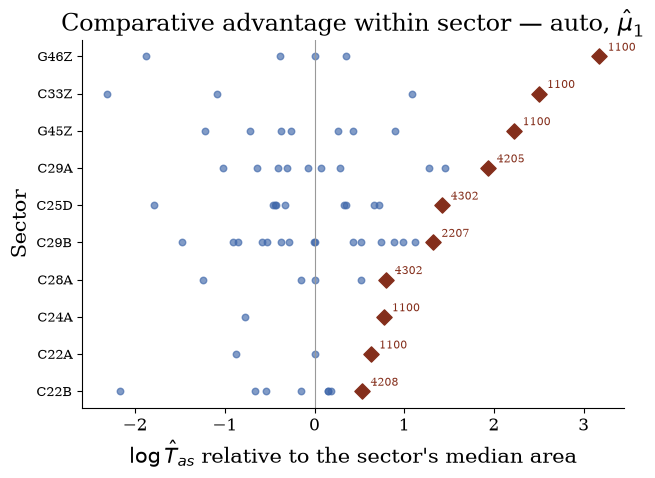

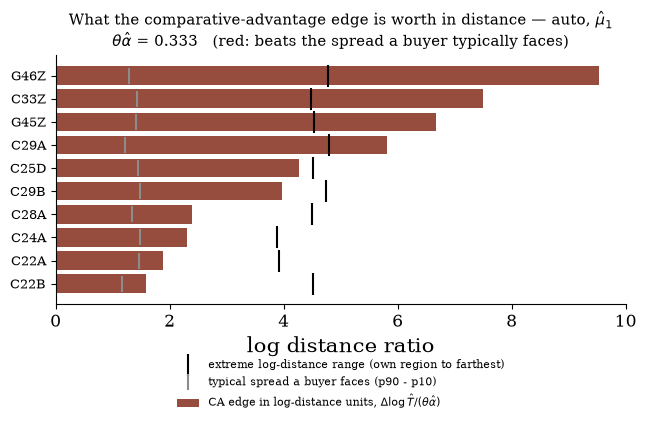

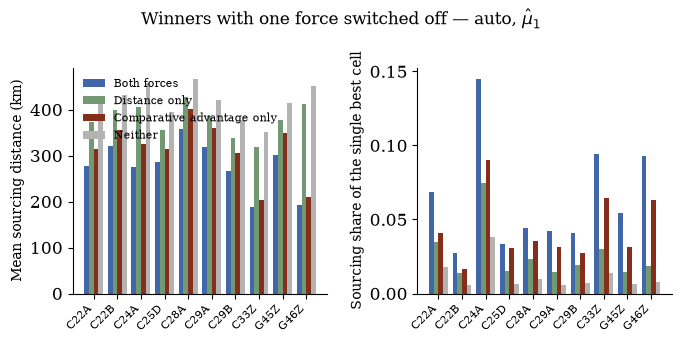

,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,
C22A,1100,3,0.627797,1.882951,1.469250,3.912685,True,False,0.615203,0.224506,2.740250,0.588575,0.078383,0.333042,0.527945,0.450786,0.261617
C22B,4208,8,0.529863,1.589219,1.171179,4.511363,True,False,0.970199,0.184530,5.257665,0.809589,0.029287,0.161123,0.069689,0.066515,0.025802
C24A,1100,2,0.770304,2.310372,1.485341,3.883860,True,False,0.683352,0.251224,2.720094,0.587581,0.079415,0.333005,0.728867,0.632296,0.369970
C25D,4302,10,1.424078,4.271238,1.439095,4.517761,True,False,1.051161,0.208696,5.036799,0.794692,0.031325,0.173983,0.091759,0.091819,0.020050
C28A,4302,5,0.799895,2.399125,1.337832,4.491595,True,False,0.657258,0.202642,3.243435,0.714204,0.067891,0.217905,0.115338,0.106595,0.034076
C29A,4205,10,1.936593,5.808426,1.217123,4.787456,True,True,0.655077,0.191378,3.422944,0.772514,0.065934,0.161553,0.121730,0.126313,0.024682
C29B,2207,16,1.321062,3.962261,1.479800,4.746346,True,False,0.730314,0.216937,3.366482,0.726867,0.064136,0.208997,0.099282,0.082508,0.028895
C33Z,1100,4,2.499371,7.496364,1.432118,4.471138,True,True,1.877893,0.206586,9.090108,0.873460,0.010571,0.115969,0.919315,0.905013,0.245549
G45Z,1100,8,2.227283,6.680292,1.407663,4.536379,True,True,0.866585,0.200528,4.321523,0.917438,0.049125,0.033437,0.524598,0.437996,0.117900


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


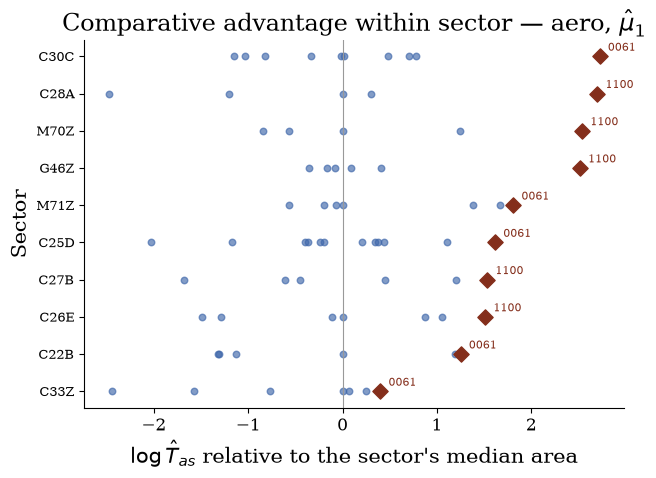

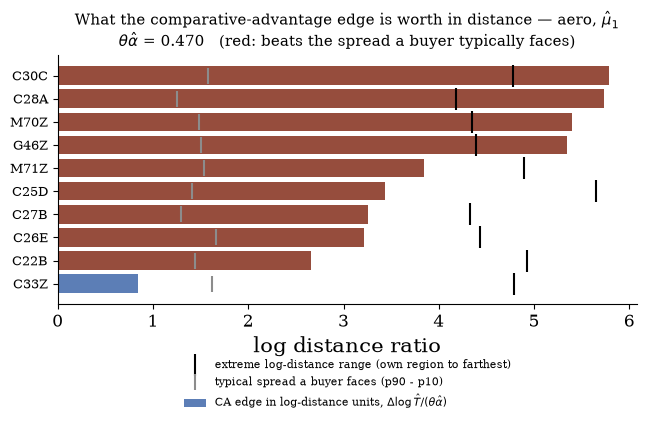

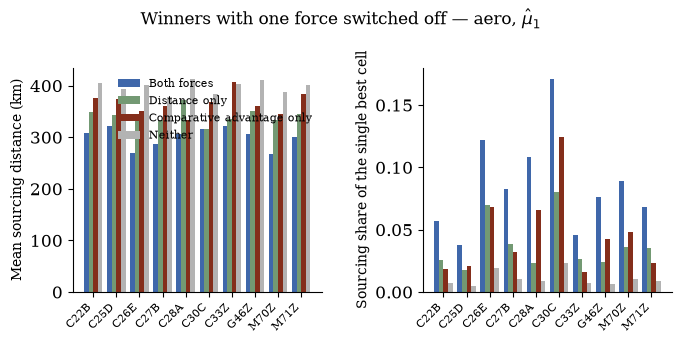

,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,
C22B,0061,7,1.248740,2.655692,1.435774,4.925035,True,False,1.118270,0.291468,3.836687,0.860439,0.058453,0.081108,0.275953,0.260620,0.115601
C25D,0061,12,1.613450,3.431320,1.413060,5.647328,True,False,1.113445,0.278274,4.001257,0.883407,0.055178,0.061415,0.380047,0.369523,0.095556
C26E,1100,7,1.510075,3.211474,1.663617,4.434990,True,False,1.176036,0.341601,3.442722,0.791122,0.066748,0.142129,0.651183,0.615191,0.237848
C27B,1100,6,1.531116,3.256222,1.299195,4.326218,True,False,1.055115,0.275287,3.832775,0.847826,0.057714,0.094460,0.406763,0.353728,0.155554
C28A,1100,5,2.697852,5.737516,1.250889,4.182868,True,True,1.633946,0.258609,6.318216,0.920270,0.023053,0.056677,0.771976,0.726230,0.124857
C30C,0061,10,2.721667,5.788163,1.572740,4.778641,True,True,1.262264,0.347986,3.627341,0.855327,0.065006,0.079667,0.728661,0.748697,0.158290
C33Z,0061,7,0.396977,0.844251,1.623199,4.788015,False,False,0.963964,0.325374,2.962631,0.872405,0.099395,0.028200,0.344689,0.337559,0.163669
G46Z,1100,6,2.513785,5.346061,1.504883,4.394953,True,True,0.750610,0.300850,2.494964,0.757781,0.121735,0.120484,0.570057,0.514569,0.103445
M70Z,1100,5,2.536921,5.395264,1.478601,4.349354,True,True,1.161749,0.297530,3.904644,0.818260,0.053670,0.128070,0.610906,0.577320,0.163102


In [23]:


for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")
    # --- Comparative advantage against distance, within sector ---------------
    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    plot_counterfactual_sourcing(
        data, save_to=f"{out_folder}/ca_counterfactual_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_summary(data))



# Amplification of shocks along vertical production linkages

Section 5.1 of the paper, Figure 6. Two numbers per shocked downstream region, both read
off the simulated firm-level economy and therefore selected by `MU` like everything else
here.

**The amplification coefficient.** `share` in `suppliers.parquet` is `exp_val`, the share
of downstream region $r$'s unit cost spent on that supplying firm, so summing over firms
gives $r$'s intermediate-input share of costs and

$$D_r \;=\; 1 \;+\; \sum_{l} X_{lr},$$

the aggregate increase in sales one additional euro of demand in $r$ generates — the euro
itself plus what it pulls upstream. About $1.5$ in the paper: one euro of final demand
generating roughly 50 cents of upstream sales.

**The share of upstream sales within a radius.**

$$L_r(d) \;=\; \frac{\sum_{l\,:\,\mathrm{Dist}_{lr} \le d} X_{lr}}{\sum_l X_{lr}},$$

the geographic incidence of the same shock. The denominator is upstream sales *only* —
the euro of downstream demand is not in it — so $L_r(d)$ is a share of what propagates.

**The radius is a free parameter.** `AMPLIFICATION_RADII` in the Constants cell sets what
the run uses, every function takes `radius_km` or `radii`, and
`amplification_summary(data, radii=(100, 200))` returns both in one pass.
`local_share_profile` sweeps it, so the 100 km headline can be seen for what it is — one
point on a curve — rather than assumed robust.

Three conventions that set the *level* of $D_r$, stated because they are easy to trip over:
`share` is a share of downstream **cost** and the markup factor $\mu$ relating cost to
sales is not applied (the convention of the published figure); the parquet's
`intermediate_derivative` column is renormalised *within* intermediates, sums to one by
construction, and is **not** an amplification measure; and the model has a single upstream
tier, so $D_r$ is the whole of its amplification — there is no round-2 Leontief term to add.

In [ ]:
# =============================================================================
# Amplification of shocks along vertical production linkages (paper Section 5.1,
# Figure 6), rebuilt on the granular / attraction-area run.
#
# Two objects, both read off the simulated firm-level economy in `suppliers.parquet`
# and therefore selected by `mu` like everything else in this notebook.
#
# (1) THE AMPLIFICATION COEFFICIENT. `share` in the parquet is `exp_val`, the share
#     of downstream region r's unit cost spent on that supplying firm. Summing over
#     every firm gives r's intermediate-input share of costs, so
#
#         D_r = 1 + sum_l (upstream sales of cell l per euro spent in r)
#
#     is the aggregate increase in sales generated by one additional euro of demand
#     in r: the euro itself, plus what it pulls upstream. Roughly 1.5 in the paper —
#     one euro of final demand generating about 50 cents of upstream sales.
#
# (2) THE SHARE OF UPSTREAM SALES WITHIN `radius_km` OF THE SHOCK,
#
#         L_r(d) = sum_{l : Dist_{lr} <= d} X_lr / sum_l X_lr,
#
#     the geographic incidence of the same shock. The denominator is UPSTREAM sales
#     only — the euro of downstream demand is not in it — so L_r(d) is a share of
#     what propagates, not of the total. The radius is a free parameter: pass
#     `radii=(100, 200)` to `amplification_summary`, or sweep it with
#     `local_share_profile`.
#
# Conventions worth stating, because they set the level of D_r:
#   * `share` is a share of downstream COST, and the markup factor mu relating cost
#     to sales is NOT applied — this is the convention of the published figure;
#   * the parquet's `intermediate_derivative` column is `exp_val` divided by
#     (1-Omega_L)(P_r/c_r)^{1-lambda}, i.e. renormalised WITHIN intermediates. It
#     sums to one by construction and is not an amplification measure; do not
#     substitute it for `share` here;
#   * the model has one upstream tier, so D_r is the whole of the model's
#     amplification — there is no round-2 Leontief term to add.
# =============================================================================

AMPLIFICATION_RADIUS_KM = 100      # the paper's Figure 6; 200 etc. are just as valid


def _region_labels(data):
    """
    Model region index (1..R) -> ZE code -> display name.

    The model orders regions by sorted `ze2010`, exactly as `load_parameters.jl`
    builds `X_rs`, so the l-th row of the distance matrix and the integer codes in
    `suppliers.parquet` are the l-th entry of that sorted list. `france` may cover
    more commuting zones than the model does, so the join is on the CODE.
    """
    fdf = data.get("filter_N_upstream_df")
    if fdf is None:
        codes = [str(i) for i in range(1, data["R"] + 1)]
    else:
        codes = sorted(fdf["ze2010"].astype(str).str.zfill(4).unique())
    if len(codes) != data["R"]:
        raise ValueError(f"{len(codes)} ZE codes in filter_N_upstream.csv but R = "
                         f"{data['R']} regions in the model.")
    out = pd.DataFrame({"index": np.arange(1, data["R"] + 1), "ze2010": codes})
    fr = data.get("france")
    if fr is not None and "ze2010_name" in fr.columns:
        names = fr[["ze2010", "ze2010_name"]].copy()
        names["ze2010"] = _as_ze_string(names["ze2010"])
        out = out.merge(names.drop_duplicates("ze2010"), on="ze2010", how="left")
    else:
        out["ze2010_name"] = out["ze2010"]
    out["ze2010_name"] = out["ze2010_name"].fillna(out["ze2010"])
    return out


def build_diffusion_frame(data, value_col="share"):
    """
    One row per (shocked downstream region, upstream cell): the upstream sales that
    one euro spent in the downstream region generates there, and the distance
    between the two.

    The grid is ZERO-FILLED over every (downstream region, region) pair — a cell that
    supplies nothing still belongs in the denominator's support and, more to the
    point, in the map. Distances come from `distances.npy` read by the model's own
    integer region indices, so there is no ZE-name round trip to get wrong.
    """
    sup = data.get("suppliers")
    if sup is None:
        raise FileNotFoundError(
            f"no suppliers.parquet under {data['folder']}/{data.get('step_dir','<step>')}/ "
            f"or {data['folder']}/ — main.jl writes one per estimate in its post-hoc block.")
    if value_col not in sup.columns:
        raise KeyError(f"`{value_col}` is not a column of suppliers.parquet "
                       f"({list(sup.columns)}).")

    R = data["R"]
    D = np.load(data["input_folder"] / "distances.npy")[:R, :R]

    agg = (sup.groupby(["ze2010_downstream", "ze2010"], as_index=False)
              .agg(upstream_sales=(value_col, "sum"),
                   n_links=(value_col, "size")))
    shocked = np.sort(sup["ze2010_downstream"].unique())

    grid = pd.MultiIndex.from_product([shocked, np.arange(1, R + 1)],
                                      names=["ze2010_downstream", "ze2010"]).to_frame(index=False)
    df = grid.merge(agg, on=["ze2010_downstream", "ze2010"], how="left").fillna(
        {"upstream_sales": 0.0, "n_links": 0})
    df["distance"] = D[df["ze2010"].to_numpy() - 1, df["ze2010_downstream"].to_numpy() - 1]

    lab = _region_labels(data)
    df = (df.merge(lab.rename(columns={"index": "ze2010", "ze2010": "ze_code",
                                       "ze2010_name": "ze_name"}), on="ze2010")
            .merge(lab.rename(columns={"index": "ze2010_downstream",
                                       "ze2010": "shocked_code",
                                       "ze2010_name": "shocked_name"}),
                   on="ze2010_downstream"))
    df["value_col"] = value_col
    return df


def amplification_summary(data, radii=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                          diffusion=None):
    """
    One row per shocked downstream region: the amplification coefficient and the
    share of the upstream sales it generates that stays within each radius.

    `radii` is a tuple, so 100 km and 200 km (or any other) come out of one pass.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    out = pd.DataFrame({
        "region": df.groupby("ze2010_downstream")["shocked_name"].first(),
        "upstream_sales": tot,
        "amplification": 1.0 + tot,
        "supplier_cells": df.assign(hit=df["upstream_sales"] > 0)
                            .groupby("ze2010_downstream")["hit"].sum(),
        "mean_upstream_distance": df.eval("upstream_sales * distance")
                                    .groupby(df["ze2010_downstream"]).sum() / tot.replace(0, np.nan),
    })
    for d in radii:
        near = df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"].sum()
        out[f"share_within_{int(d)}km"] = (near.reindex(out.index).fillna(0.0)
                                           / tot.replace(0, np.nan))
    out.attrs["value_col"] = value_col
    out.attrs["radii"] = tuple(radii)
    return out.sort_values("amplification", ascending=False)


def local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                        value_col="share", diffusion=None):
    """
    The share within `d` as a FUNCTION of `d`: the mean across shocked regions, its
    interquartile band, and the sales-weighted mean. The single 100 km number of
    Figure 6 is one point on this curve, and the curve says whether that number is a
    knife edge or a plateau.
    """
    df = build_diffusion_frame(data, value_col) if diffusion is None else diffusion
    tot = df.groupby("ze2010_downstream")["upstream_sales"].sum()
    rows = []
    for d in radii:
        near = (df.loc[df["distance"] <= d].groupby("ze2010_downstream")["upstream_sales"]
                  .sum().reindex(tot.index).fillna(0.0))
        sh = (near / tot.replace(0, np.nan)).dropna()
        rows.append({"radius_km": d, "mean": sh.mean(), "median": sh.median(),
                     "p25": sh.quantile(0.25), "p75": sh.quantile(0.75),
                     "weighted_mean": float(near.sum() / tot.sum()) if tot.sum() > 0 else np.nan})
    return pd.DataFrame(rows).set_index("radius_km")

In [ ]:
# =============================================================================
# Figure 6 — the two panels, plus the radius sweep the fixed 100 km hides.
# =============================================================================


def plot_amplification(data, value_col="share", summary=None, figsize=None,
                       save_to=None):
    """Top panel of Figure 6: the amplification coefficient D_r, by commuting zone."""
    s = (amplification_summary(data, value_col=value_col) if summary is None
         else summary).sort_values("amplification")
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s["amplification"], color=toulouse_color)
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel("Commuting zone")
    ax.set_xlim(left=1.0)
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean $D_r$ = {s['amplification'].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share(data, radius_km=AMPLIFICATION_RADIUS_KM, value_col="share",
                     summary=None, figsize=None, save_to=None):
    """Bottom panel of Figure 6: the share of upstream sales within `radius_km`."""
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary)
    col = f"share_within_{int(radius_km)}km"
    if col not in s.columns:
        raise KeyError(f"{col} is not in the summary — pass `radii=({radius_km},)` "
                       "to amplification_summary, or let this function build it.")
    s = s.sort_values(col)
    fig, ax = plt.subplots(figsize=figsize or (8, max(3.0, 0.28 * len(s))))
    ax.barh(s["region"].astype(str), s[col], color=toulouse_color)
    ax.set_xlabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_ylabel("Commuting zone")
    ax.grid(alpha=0.2, axis="x")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$"
                 f"   mean = {s[col].mean():.3f}", fontsize=11)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_local_share_profile(data, radii=(25, 50, 75, 100, 150, 200, 300, 500),
                             mark=(AMPLIFICATION_RADIUS_KM,), value_col="share",
                             profile=None, figsize=None, save_to=None):
    """
    The share within `d` against `d`: the median across shocked regions with its
    interquartile band, and the sales-weighted mean. Shows whether the headline
    number is robust to the radius or sits on a steep part of the curve.
    """
    p = (local_share_profile(data, radii=radii, value_col=value_col)
         if profile is None else profile)
    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.6))
    ax.fill_between(p.index, p["p25"], p["p75"], color=sim_color, alpha=0.20,
                    label="interquartile range across regions")
    ax.plot(p.index, p["median"], marker="o", color=sim_color, label="median region")
    ax.plot(p.index, p["weighted_mean"], marker="s", color=reference_color,
            linestyle="--", label="sales-weighted mean")
    ax.set_ylim(0, 1)
    for m in mark:
        ax.axvline(m, color="0.6", linewidth=0.9, linestyle=":")
        ax.annotate(f"{m:g} km", (m, 0.98), fontsize=8, color="0.4", ha="left",
                    va="top", xytext=(3, 0), textcoords="offset points")
    ax.set_xlabel("Radius around the shocked region (km)")
    ax.set_ylabel("Share of upstream sales within the radius")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def plot_amplification_vs_local(data, radius_km=AMPLIFICATION_RADIUS_KM,
                                value_col="share", summary=None, n_label=5,
                                figsize=None, save_to=None):
    """
    How much a shock amplifies against how much of it stays nearby — the two panels
    of Figure 6 in one picture. Labelled: the `n_label` regions that keep the least
    locally, and the `n_label` that amplify the most.
    """
    s = (amplification_summary(data, radii=(radius_km,), value_col=value_col)
         if summary is None else summary).copy()
    col = f"share_within_{int(radius_km)}km"
    flagged = set(s.nsmallest(n_label, col).index) | set(s.nlargest(n_label, "amplification").index)

    fig, ax = plt.subplots(figsize=figsize or get_figsize(wf=0.8, hf=0.7))
    plain = s.loc[~s.index.isin(flagged)]
    named = s.loc[s.index.isin(flagged)]
    ax.scatter(plain["amplification"], plain[col], s=30, color=toulouse_color, alpha=0.8)
    ax.scatter(named["amplification"], named[col], s=45, facecolors="none",
               edgecolors=toulouse_color, linewidths=1.2)
    texts = [ax.text(r["amplification"], r[col], str(r["region"]), fontsize=8)
             for _, r in named.iterrows()]
    try:                                   # nicer label placement when available
        from adjustText import adjust_text
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5, color="black"))
    except ImportError:
        pass
    ax.set_xlabel(r"Amplification measure $D_r$")
    ax.set_ylabel(f"Share of upstream sales within {radius_km:g} km")
    ax.set_title(f"{data['industry']}, " rf"$\hat\mu_{data['mu']}$", fontsize=11)
    _despine(ax)
    fig.tight_layout()
    if save_to:
        os.makedirs(os.path.dirname(save_to) or ".", exist_ok=True)
        fig.savefig(save_to, bbox_inches="tight")
    return ax


def amplification_report(data, radii=(AMPLIFICATION_RADIUS_KM, 200), value_col="share",
                         out_folder=None, show=True):
    """
    Everything in this section for one industry, in one call: the two Figure-6 panels,
    the radius sweep, the joint scatter and the summary table.

    Returns `(summary, profile)` so the numbers can be reused without recomputing.
    `radii[0]` is the radius the bar chart and the scatter use.
    """
    diff = build_diffusion_frame(data, value_col)
    summ = amplification_summary(data, radii=radii, value_col=value_col, diffusion=diff)
    prof = local_share_profile(data, value_col=value_col, diffusion=diff)

    ind, mu = data["industry"], data["mu"]
    tag = lambda name: (None if out_folder is None
                        else f"{out_folder}/{name}_{ind}_mu{mu}.pdf")

    print(f"[{ind}, mu = {mu}]  mean D_r = {summ['amplification'].mean():.3f} "
          f"(one euro of demand -> {summ['upstream_sales'].mean():.3f} upstream), "
          f"p90 = {summ['amplification'].quantile(0.9):.3f}")
    for d in radii:
        c = f"share_within_{int(d)}km"
        print(f"                 share of upstream sales within {d:g} km: "
              f"mean {summ[c].mean():.3f}, median {summ[c].median():.3f}, "
              f"min {summ[c].min():.3f}, max {summ[c].max():.3f}")

    plot_amplification(data, summary=summ, save_to=tag("amplification"))
    if show:
        plt.show()
    plot_local_share(data, radius_km=radii[0], summary=summ,
                     save_to=tag(f"local_share_{int(radii[0])}km"))
    if show:
        plt.show()
    plot_local_share_profile(data, profile=prof, mark=radii,
                             save_to=tag("local_share_profile"))
    if show:
        plt.show()
    plot_amplification_vs_local(data, radius_km=radii[0], summary=summ,
                                save_to=tag("amplification_vs_local"))
    if show:
        plt.show()
    return summ, prof

In [ ]:
for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    # --- Amplification along vertical linkages (Figure 6) --------------------
    # radii[0] is the radius the bar chart and the scatter use; change
    # AMPLIFICATION_RADII in the Constants cell to test another one.
    amplification_report(data, radii=AMPLIFICATION_RADII, out_folder=out_folder)

## Validation of the sections above

These sections do arithmetic that is easy to get wrong *silently*: an index space
confused for another, a mask applied on the wrong axis, an estimator that converges to
a plausible-looking number that is not the one intended. None of it would raise. So each
is gated by `test/test_analysis_granular_sections.py`, which needs neither Julia nor the
real data:

```bash
python test/test_analysis_granular_sections.py
```

It writes a **synthetic run tree with the exact file layout the loader expects** and then
executes **the notebook's own code cells** against it (located by content, not by index),
so what is tested is the shipped artefact rather than a copy that can drift from it. The
reasoning behind each gate:

**Identification / sensitivity.** The risk is the embedding: `jacobian_N_s.npy` covers
only the $\beta\to\gamma\to G$ rows, and putting them back on the full masked moment
vector means asserting they are the *trailing* rows. A silent off-by-one would move the
$N_s$ derivative onto the wrong moments and the picture would still look reasonable. The
gate plants a known diagonal $\partial \bar G_s/\partial N_s$, checks the embedded
column is exactly zero off block 6 and equals $\hat N_s\,(\partial m/\partial N)/m$ on
it to $10^{-12}$, checks `identification_summary` separates structural zeros from
sub-threshold entries, and checks that the pre-existing Jacobian plots still accept the
extended dict — the whole point of returning a copy of the loader's layout.

**Untargeted moment.** Two independent risks. The *estimator*: `ppml_absorb` profiles the
fixed effect out in closed form and Newtons on the within transforms, so a mistake in the
algebra converges to the wrong $\hat\beta$ without complaint. It is checked against
`statsmodels`' Poisson GLM with **explicit dummies** — a different algorithm for the same
estimand — agreeing to $10^{-8}$ on $\hat\beta$ and $10^{-6}$ on the classical standard
errors, weighted and unweighted; a continuous share-like outcome recovers a planted
elasticity (Poisson PML is a conditional-*mean* estimator, which is exactly why shares are
admissible); and a separated group is dropped rather than crashing. The *panel*: the zeros
are half the moment, so the gate checks the grid is filled to exactly
$n_{\text{firms}} \times R_d$ rows, that $a_{ir}$ sums to one per supplier, and that every
distance matches `distances.npy` read by integer region index. When `pyfixest` happens to
be installed the whole regression is cross-checked against `pf.fepois` as well.

**Comparative advantage.** The risk is the parameter layout: `best_params` is the raw
$\theta$, whose $T$ block is s-major over the *active* $(s, a)$ pairs and includes each
sector's reference, which `unpack_params` then divides out. Read it with the wrong offset
or the wrong ordering and every number downstream is wrong but finite. The gate plants a
known $T$, checks the recovered matrix equals $T/T_{\text{ref}}$ entry by entry, and
checks the length assertion fires on a mismatch. The win probabilities are recomputed
independently from the closed form and must agree; $\alpha = 0$ must make $\rho$
buyer-invariant and proportional to $T$; equalising $T$ must leave pure gravity; the
"Neither" regime must return exactly the uniform $1/n$. The variance decomposition is an
identity, so its three shares must sum to one to machine precision. Finally a sector is
given a large planted edge and one a flat profile, and the gate checks the summary ranks
them accordingly — that the measurement responds to the thing it claims to measure.

**Amplification.** The measure is a ratio whose numerator and denominator are easy to
mismatch — the denominator is upstream sales only, the numerator a distance-truncated part
of the same sum — and a wrong distance lookup would still produce a plausible bar chart.
The gate plants a firm-level economy in which every downstream region spends a known total
on intermediates, so $D_r = 1.5$ must come back exactly; it checks the
(region $\times$ region) grid is fully zero-filled, that every distance matches
`distances.npy` read by integer index, and that $L_r(d)$ reproduces a direct count on the
same frame. Because $L_r(\cdot)$ is a CDF in the radius, the profile must be monotone with
$p_{25}\le$ median $\le p_{75}$ throughout, a 10 000 km radius must return exactly one, and
a 0 km radius must keep the shocked region alone — four properties a sign error or a
transposed distance matrix would break. A smaller radius keeping strictly less than a
larger one is the check that the radius is genuinely free rather than baked in somewhere.

Two behaviours are asserted rather than assumed because they are the ones a reader would
otherwise have to take on trust: the exact zeros in the $N_s$ columns (structural, not
numerical) and the refusal to run the distance-equivalence under a binned trade cost,
where no single distance elasticity exists.

# Full Run

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(
/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


Combined table saved to: ../reporting_combined/moments_comparison_combined_mu1.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Motor Vehicles} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5}
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1551 & 0.1586 & 0.1489 & 0.0792 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0367 & 0.0071 & {---} & {---} \\
Plastic Manufacturing & 0.0673 & 0.0729 & 0.0149 & 0.0049 \\
Steel Manufacturing & 0.0314 & 0.0315 & {---} & {---} \\
Forging \& Metal Machining & 0.0797 & 0.0871 & 0.0132 & 0.0183 \\
Instrume

/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


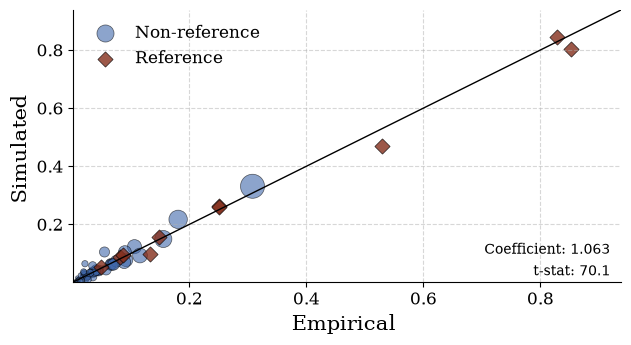

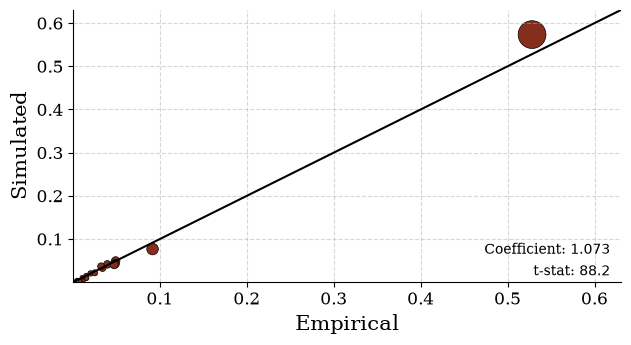

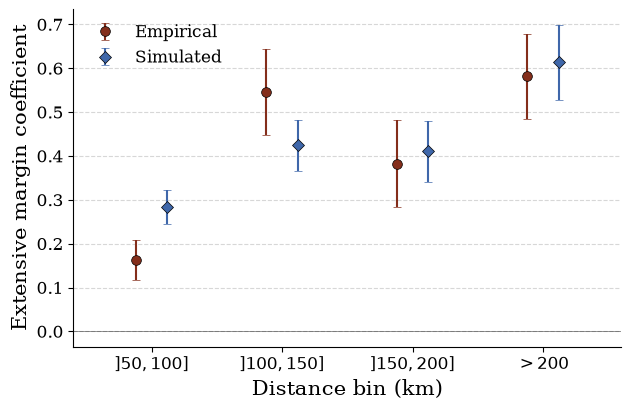

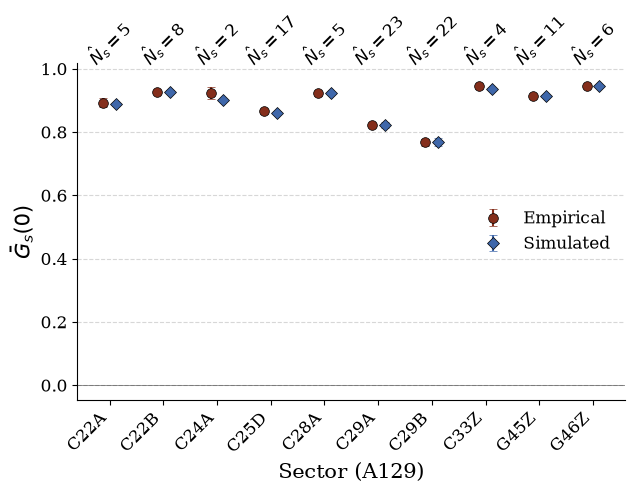

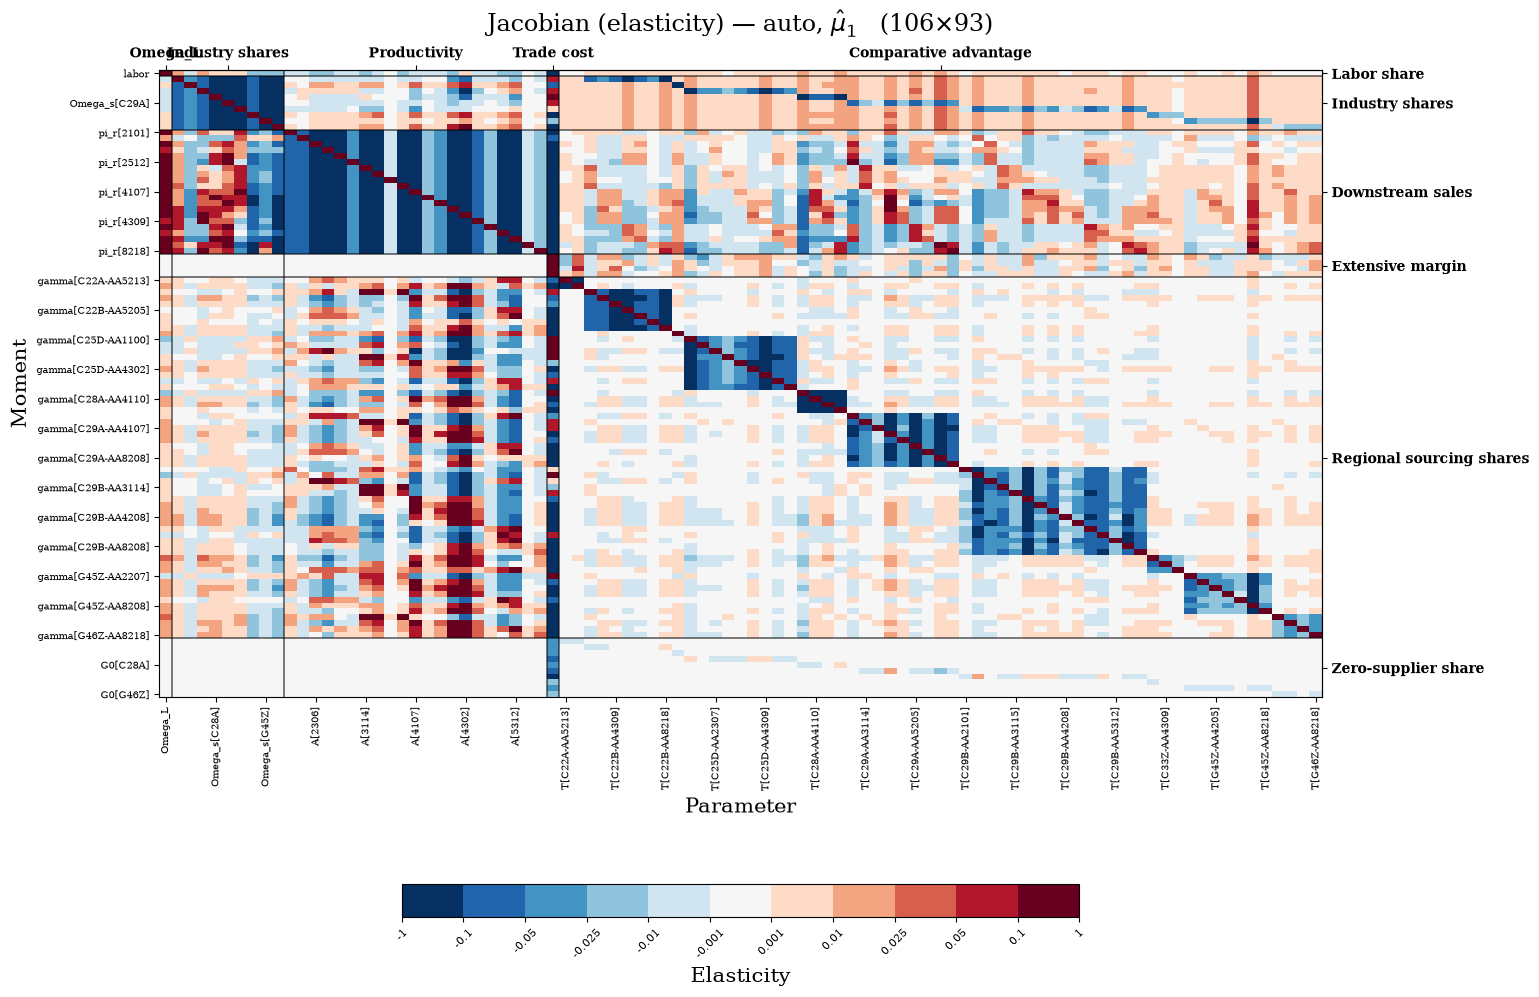

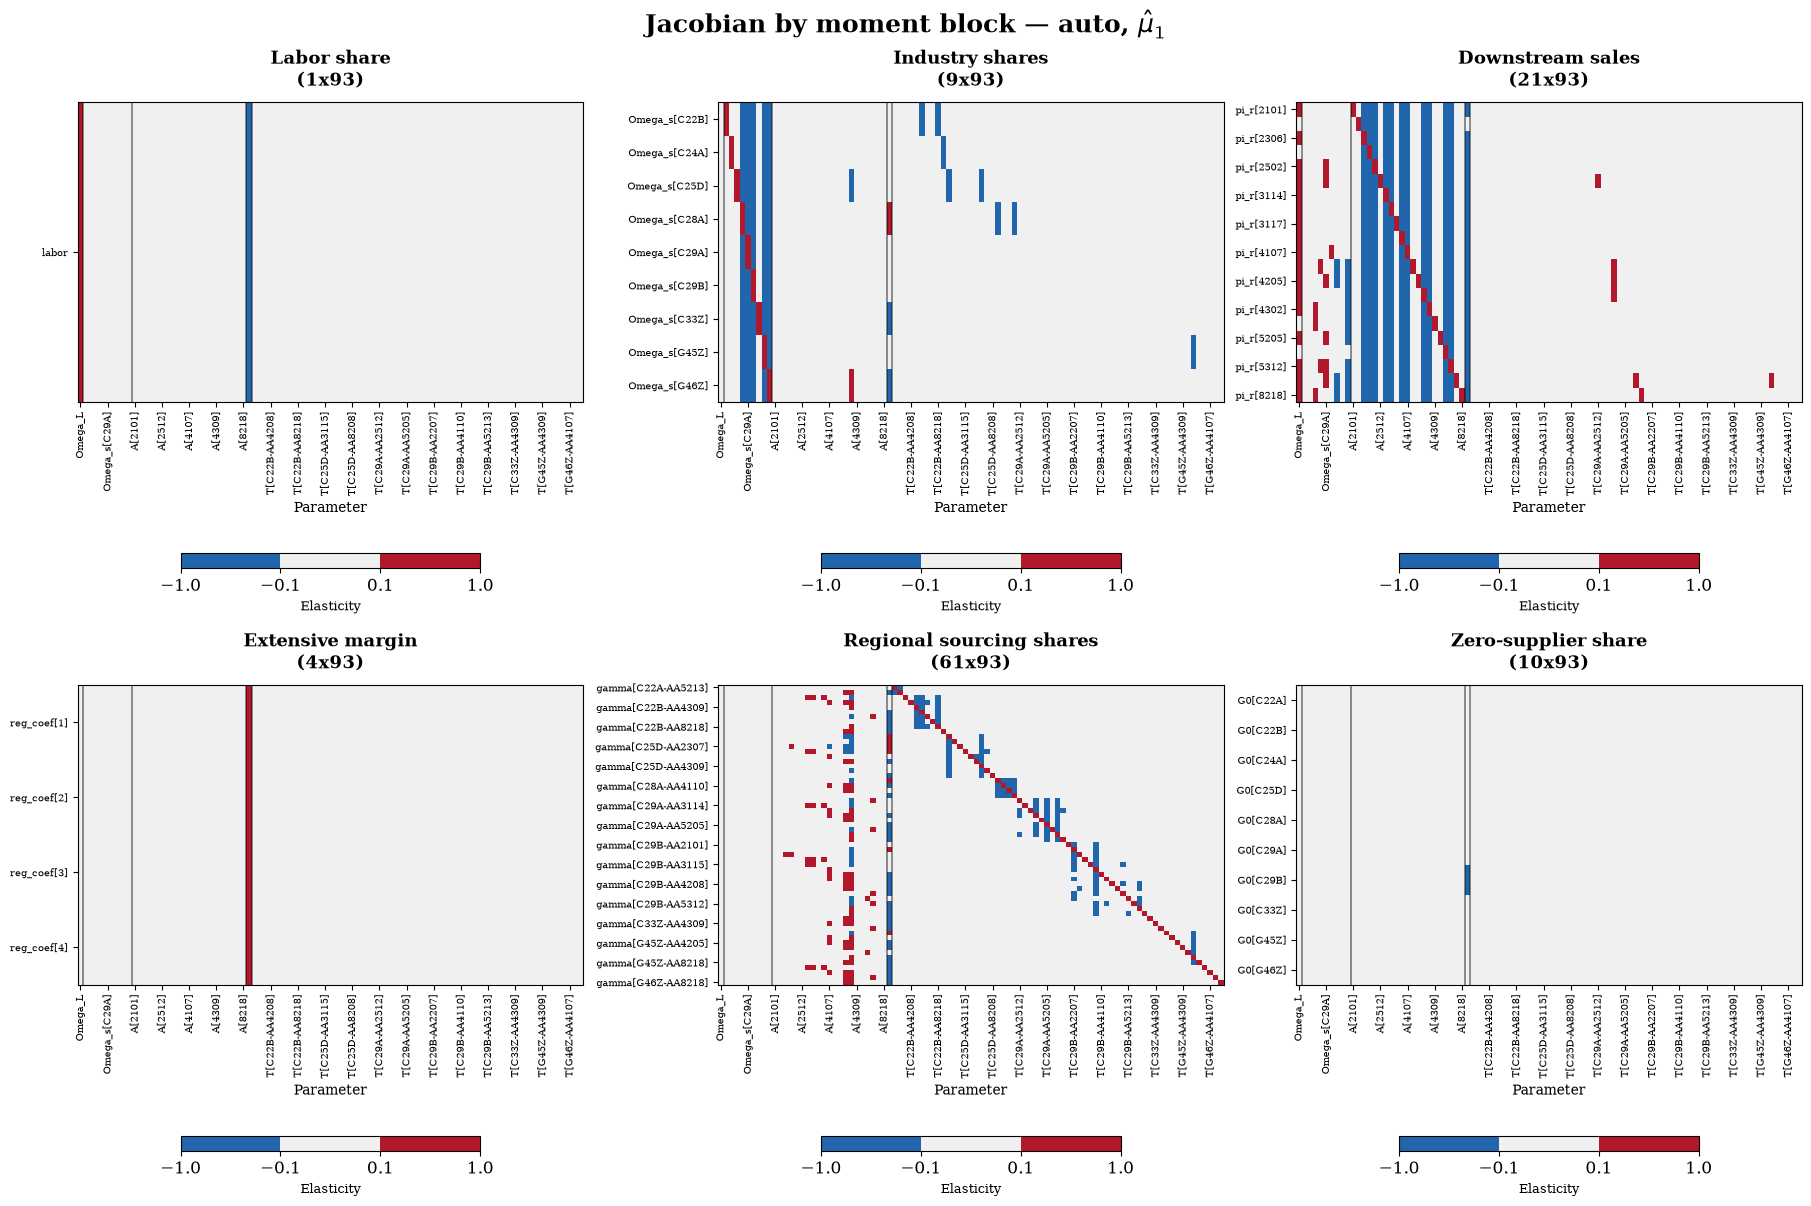

param_block,Omega_L,Industry shares,Productivity,Trade cost,Comparative advantage
moment_block,,,,,
Labor share,0.858649,0.013397,0.007538,0.680994,0.003700
Industry shares,0.004812,0.196316,0.009533,0.081819,0.012582
Downstream sales,0.122455,0.049686,0.594856,0.866119,0.012048
Extensive margin,0.000000,0.000000,0.000000,1.012969,0.007322
Regional sourcing shares,0.010728,0.005101,0.036677,0.185621,0.025977
Zero-supplier share,0.000000,0.000000,0.000000,0.043223,0.000269


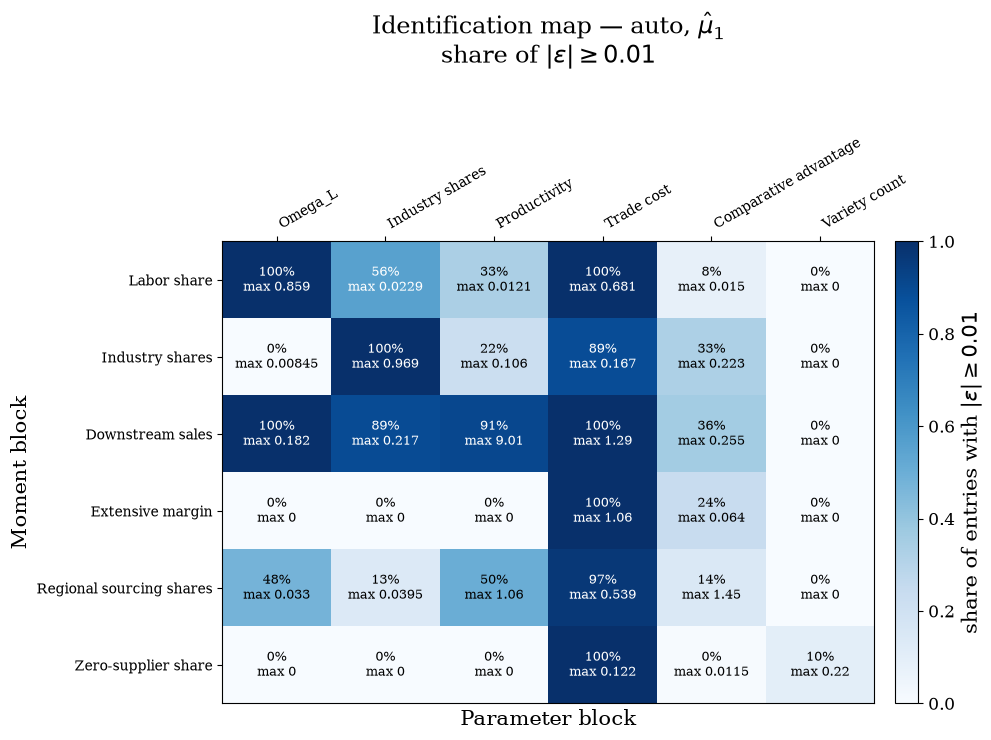

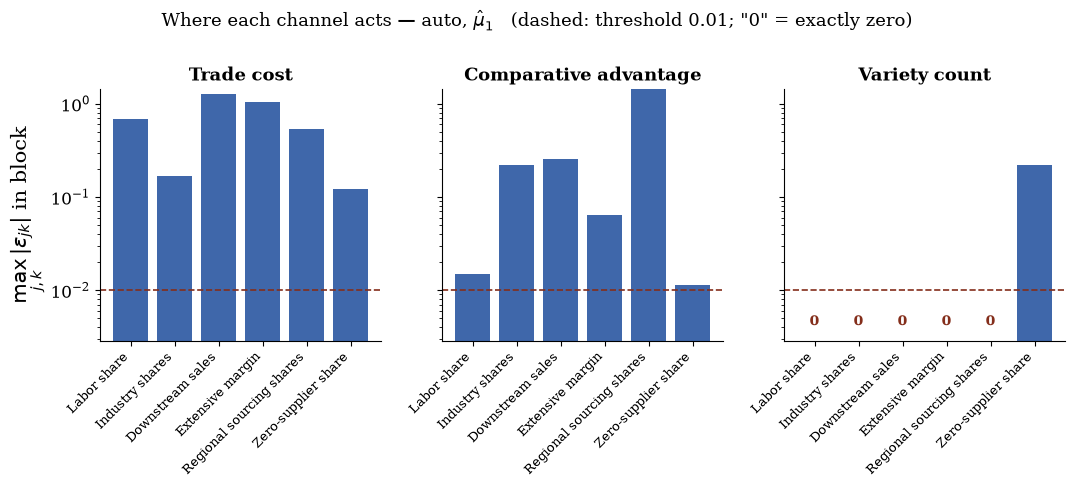

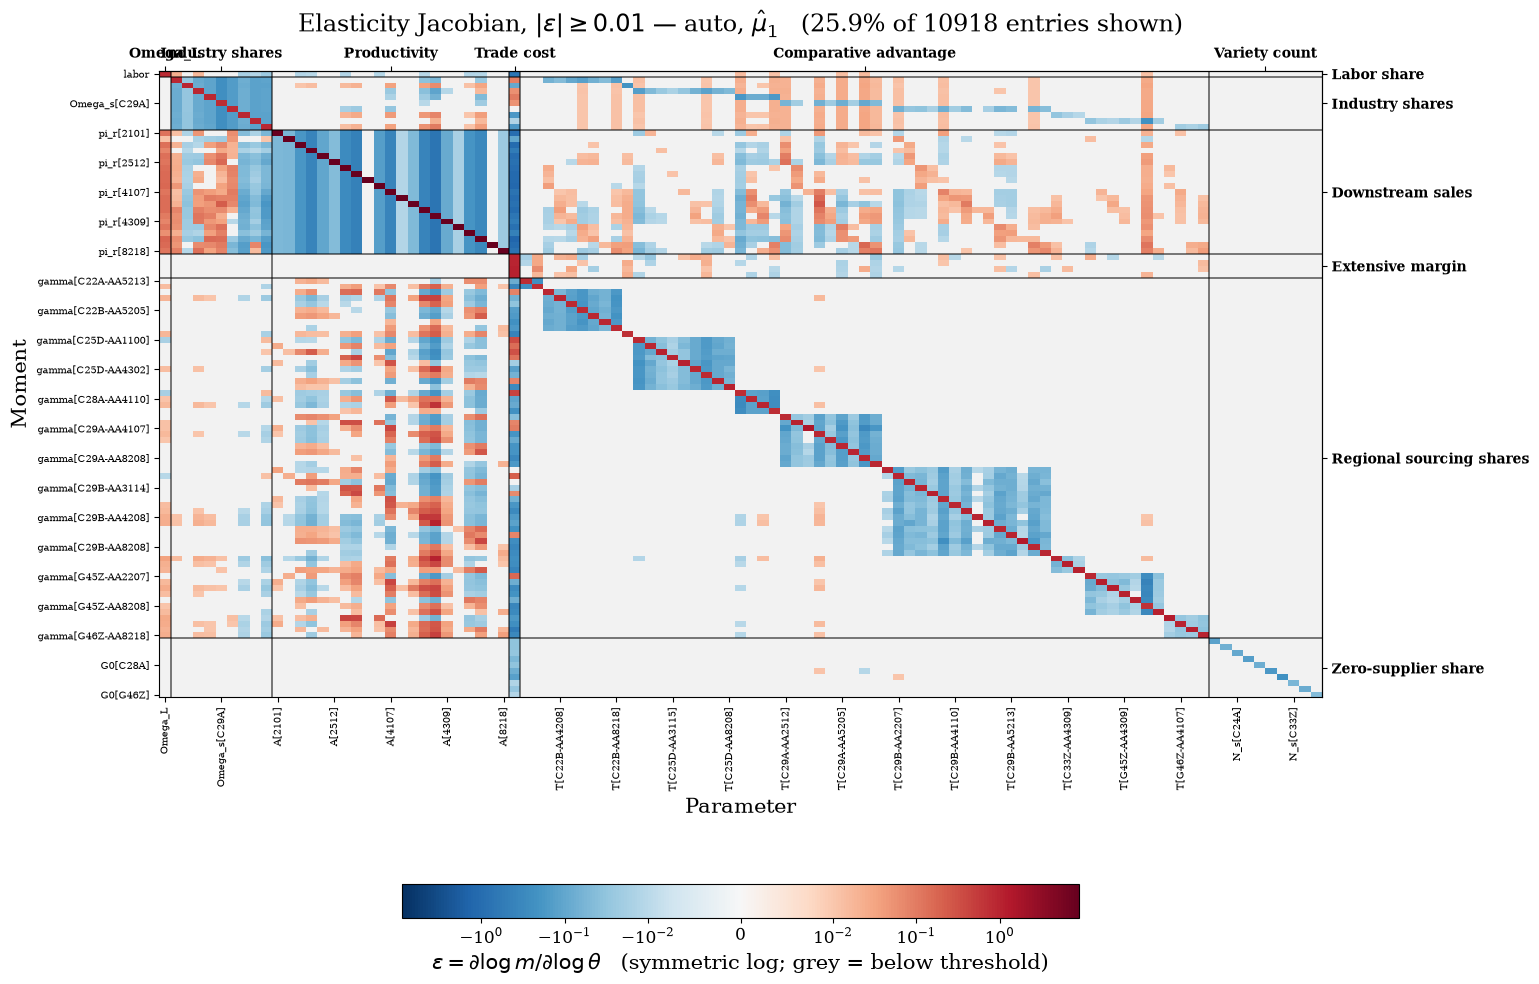

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                  1.00000        0.555556     0.333333   1.000000   
Industry shares              0.00000        1.000000     0.222222   0.888889   
Downstream sales             1.00000        0.894180     0.909297   1.000000   
Extensive margin             0.00000        0.000000     0.000000   1.000000   
Regional sourcing shares     0.47541        0.132969     0.500390   0.967213   
Zero-supplier share          0.00000        0.000000     0.000000   1.000000   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.081967           0.0  0.858649   
Industry shares                       0.327869           0.0  0.008448   
Downstream sales                      0.356753           0.0  0.181767   
Extensive margin                      0.237705           0.0  0.000000   
Regional sourcing shares              0.144854           0.0  0.033015   
Zero-supplier share                   0.004918           0.1  0.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.022929     0.012075   0.680994  ...   
Industry shares                 0.969008     0.106046   0.167416  ...   
Downstream sales                0.217295     9.009067   1.285614  ...   
Extensive margin                0.000000     0.000000   1.055637  ...   
Regional sourcing shares        0.039492     1.062714   0.538999  ...   
Zero-supplier share             0.000000     0.000000   0.121580  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.007538   0.680994              0.003700   
Industry shares              0.009533   0.081819              0.012582   
Downstream sales             0.594856   0.866119              0.012048   
Extensive margin             0.000000   1.012969              0.007322   
Regional sourcing shares     0.036677   0.185621              0.025977   
Zero-supplier share          0.000000   0.043223              0.000269   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.010555              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   
Zero-supplier share               1.0       

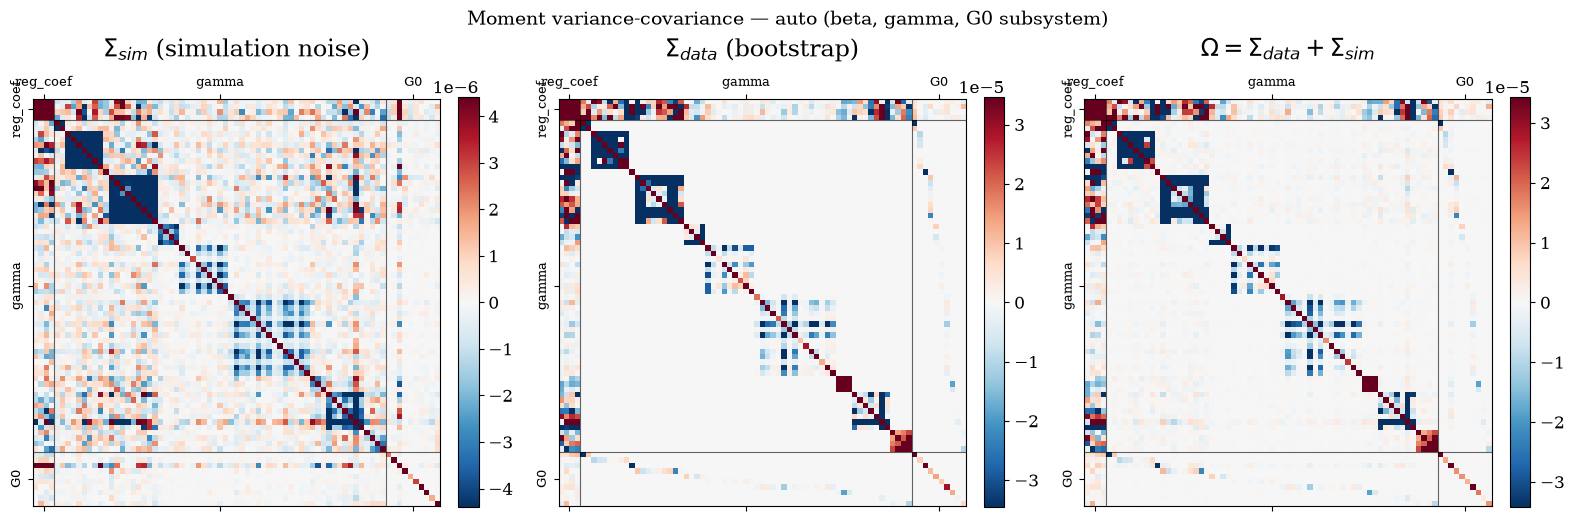

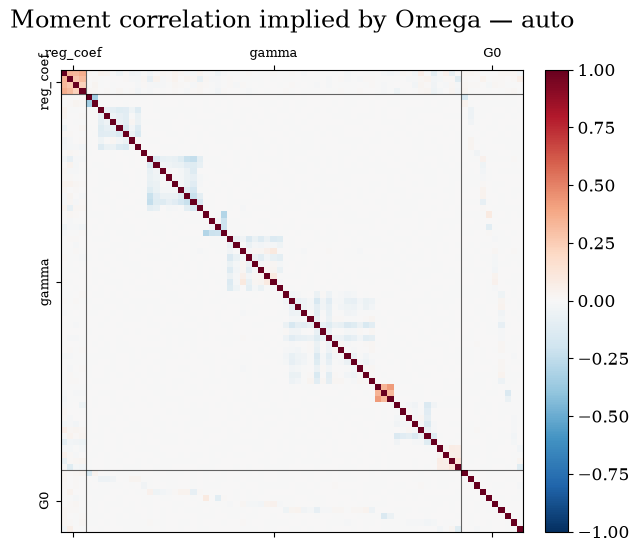

,trace,eig_min,eig_max,cond
Sigma_data,0.076572,0.000001,0.012064,8906.941253
Sigma_sim,0.008251,0.000002,0.000921,581.043516
Omega,0.084823,0.000003,0.012148,4076.095721


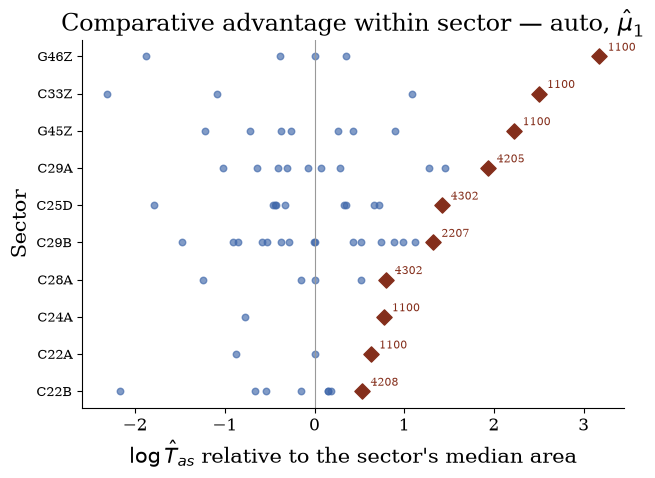

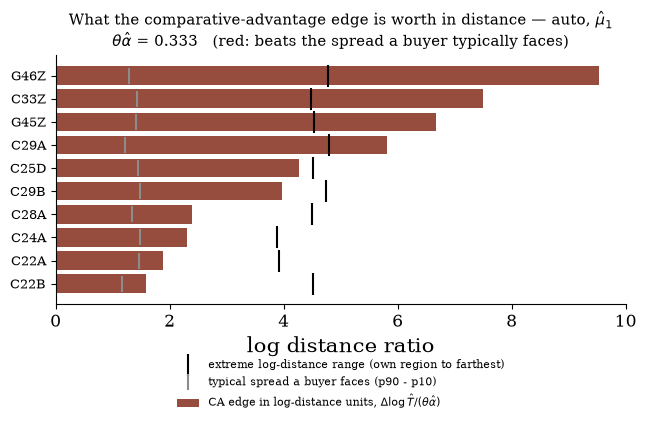

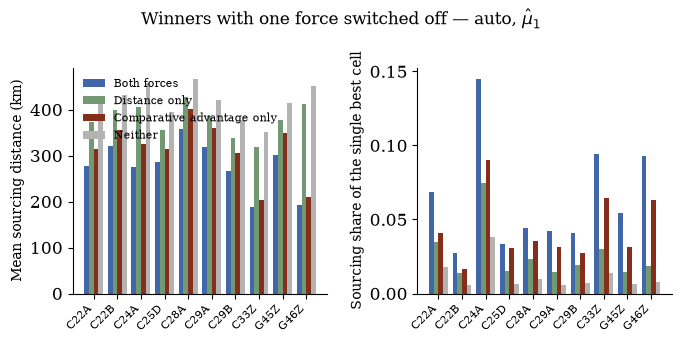

,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,
C22A,1100,3,0.627797,1.882951,1.469250,3.912685,True,False,0.615203,0.224506,2.740250,0.588575,0.078383,0.333042,0.527945,0.450786,0.261617
C22B,4208,8,0.529863,1.589219,1.171179,4.511363,True,False,0.970199,0.184530,5.257665,0.809589,0.029287,0.161123,0.069689,0.066515,0.025802
C24A,1100,2,0.770304,2.310372,1.485341,3.883860,True,False,0.683352,0.251224,2.720094,0.587581,0.079415,0.333005,0.728867,0.632296,0.369970
C25D,4302,10,1.424078,4.271238,1.439095,4.517761,True,False,1.051161,0.208696,5.036799,0.794692,0.031325,0.173983,0.091759,0.091819,0.020050
C28A,4302,5,0.799895,2.399125,1.337832,4.491595,True,False,0.657258,0.202642,3.243435,0.714204,0.067891,0.217905,0.115338,0.106595,0.034076
C29A,4205,10,1.936593,5.808426,1.217123,4.787456,True,True,0.655077,0.191378,3.422944,0.772514,0.065934,0.161553,0.121730,0.126313,0.024682
C29B,2207,16,1.321062,3.962261,1.479800,4.746346,True,False,0.730314,0.216937,3.366482,0.726867,0.064136,0.208997,0.099282,0.082508,0.028895
C33Z,1100,4,2.499371,7.496364,1.432118,4.471138,True,True,1.877893,0.206586,9.090108,0.873460,0.010571,0.115969,0.919315,0.905013,0.245549
G45Z,1100,8,2.227283,6.680292,1.407663,4.536379,True,True,0.866585,0.200528,4.321523,0.917438,0.049125,0.033437,0.524598,0.437996,0.117900


[auto]  eta = -0.6857  (se 0.0671, CRV1, 267 clusters)   95% CI [-0.8172, -0.5543]
            delta/gamma in the data = -0.1090 [-0.1220, -0.0960]
            96,426 supplier x downstream-region cells, 4,383 suppliers, 33.6% zeros, 220 sector x downstream-region FE
            from ../reporting_auto_profiled_aa_gran_pso/suppliers.parquet
                       channel  coefficient       se  n_obs
                   eta (total)    -0.685749 0.067077  96426
   eta_ext (extensive: Lambda)    -0.220000 0.014542  96426
eta_int (intensive: portfolio)    -0.480192 0.062014  64020
  eta - (eta_ext + eta_int) = +0.0144   (exactly zero only under common fixed effects)


/opt/python/lib/python3.13/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'france.gpkg': 'france_idf' (default), 'france'. Specify layer parameter to avoid this warning.
  result = read_func(


aero: S=10  n_AA=18  N_REG=4  moments from reporting_aero_profiled_aa_gran_pso/step1, SEs from step2/inference


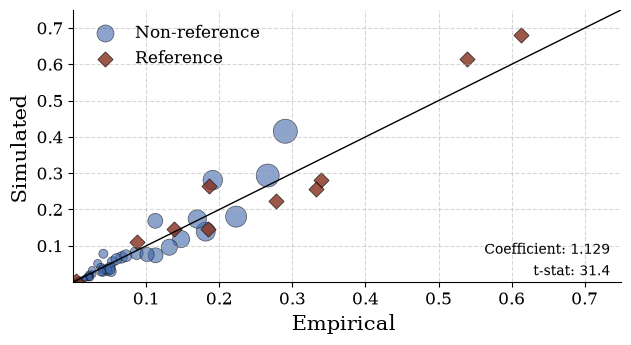

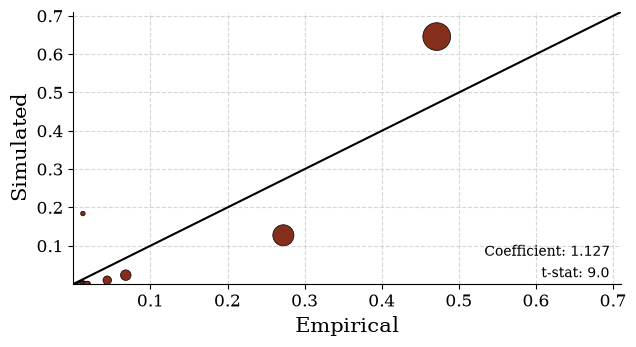

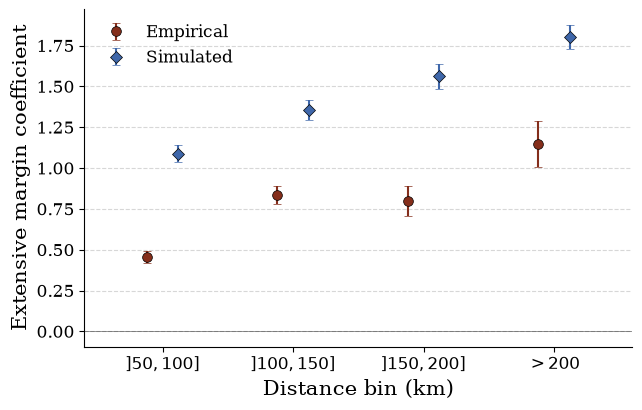

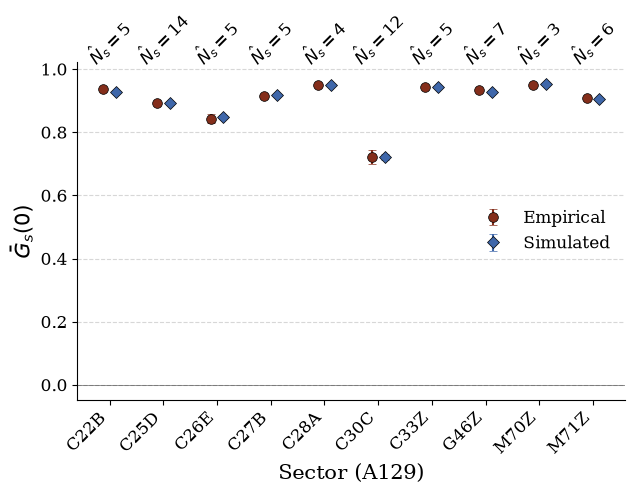

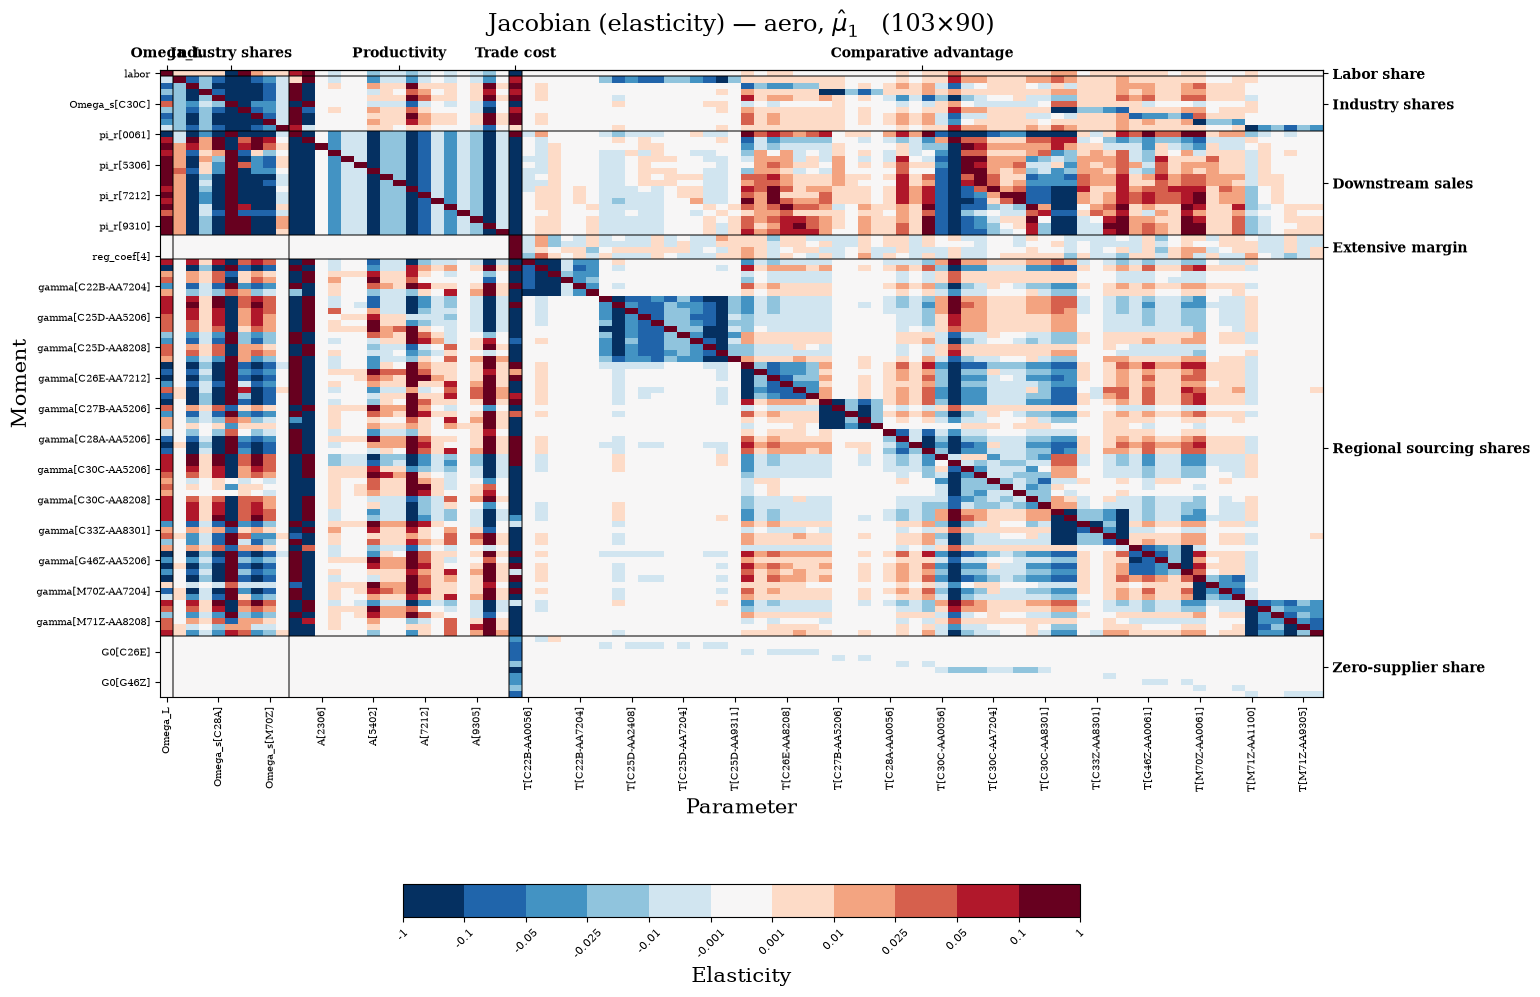

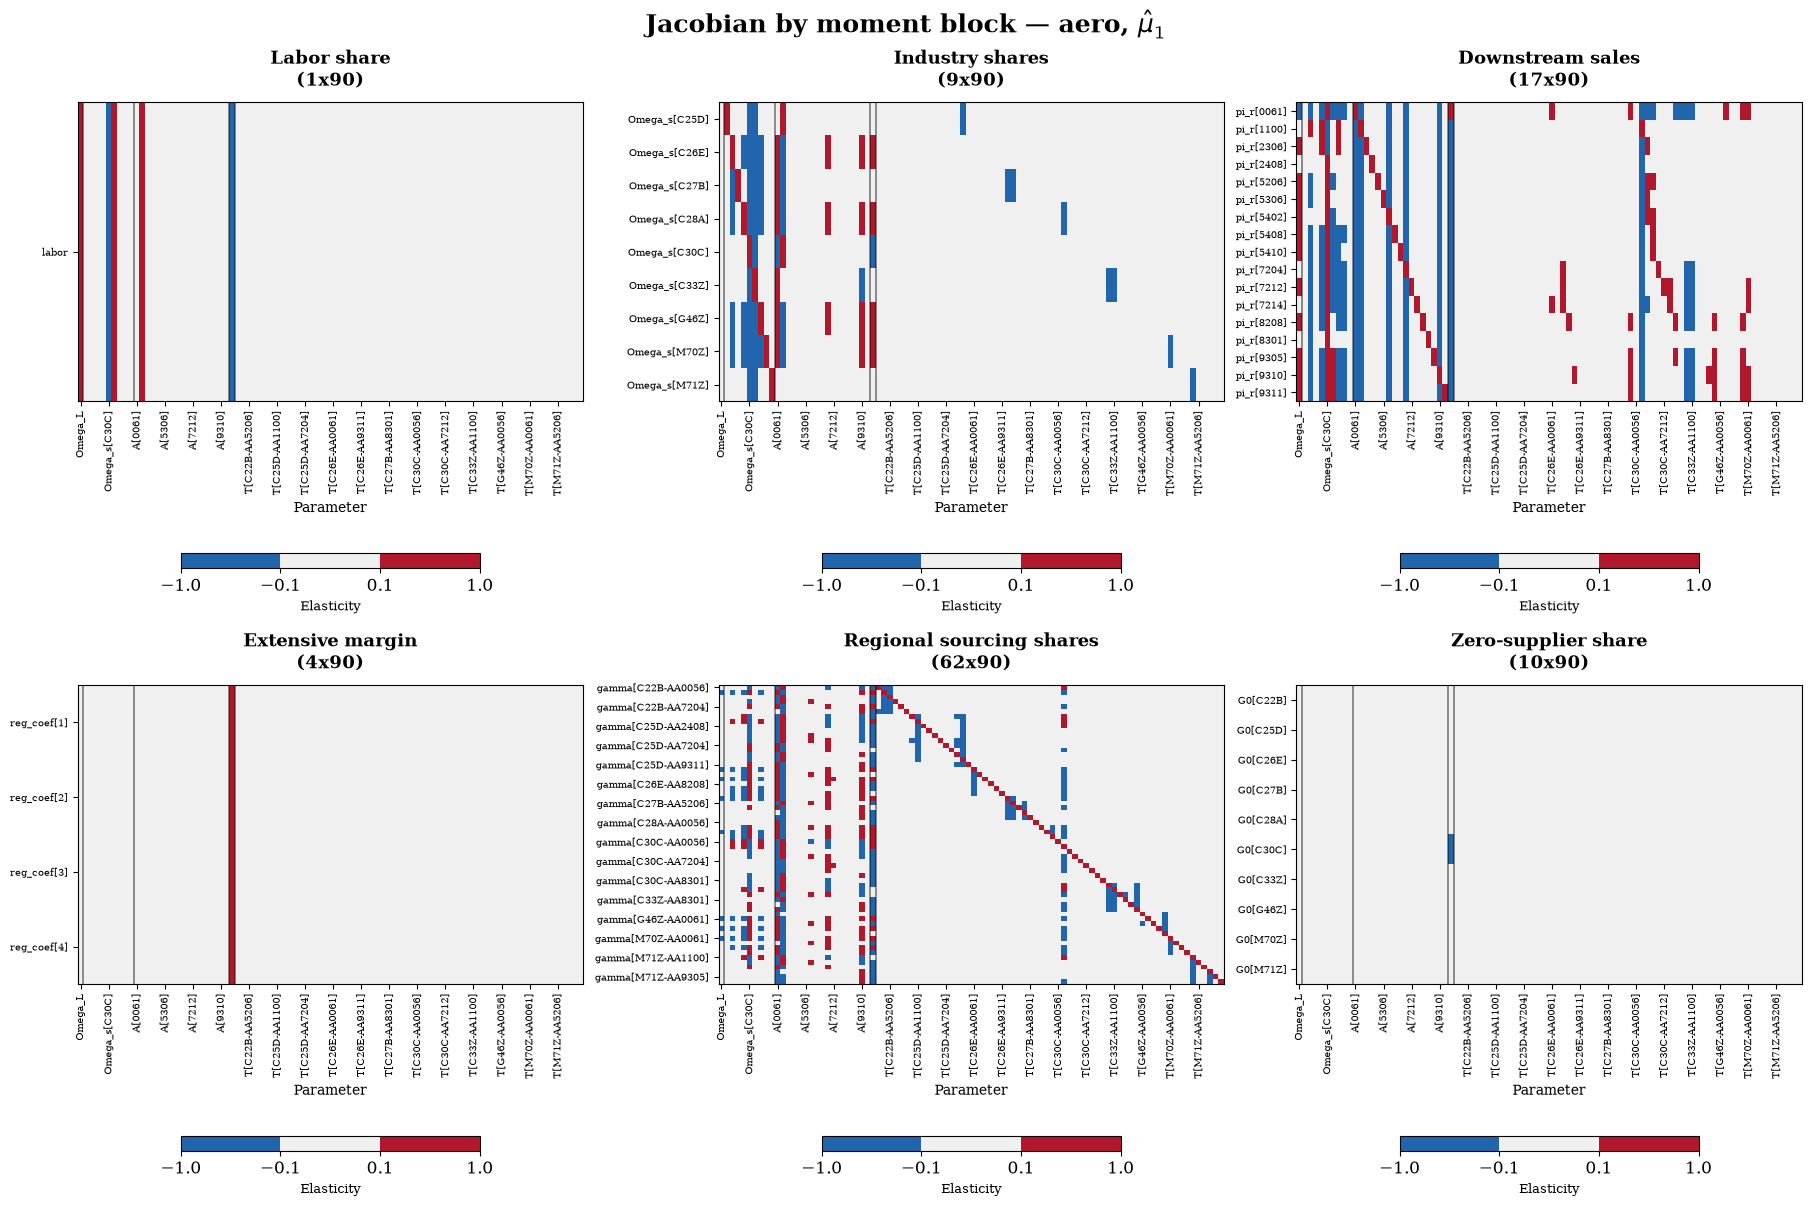

param_block,Omega_L,Industry shares,Productivity,Trade cost,Comparative advantage
moment_block,,,,,
Labor share,0.912378,0.036319,0.033729,1.044062,0.002589
Industry shares,0.038083,0.185217,0.100308,0.160491,0.009673
Downstream sales,0.296192,0.192270,1.607484,2.359391,0.033634
Extensive margin,0.000000,0.000000,0.000000,1.031279,0.004172
Regional sourcing shares,0.053808,0.064288,0.179437,0.366594,0.028866
Zero-supplier share,0.000000,0.000000,0.000000,0.056556,0.000318


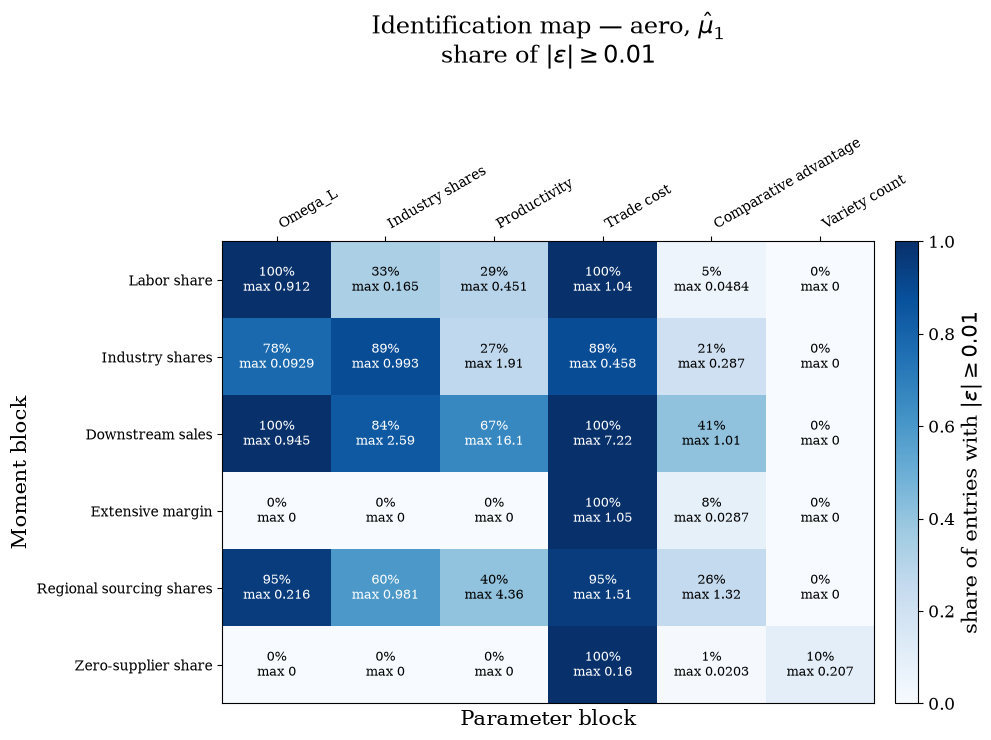

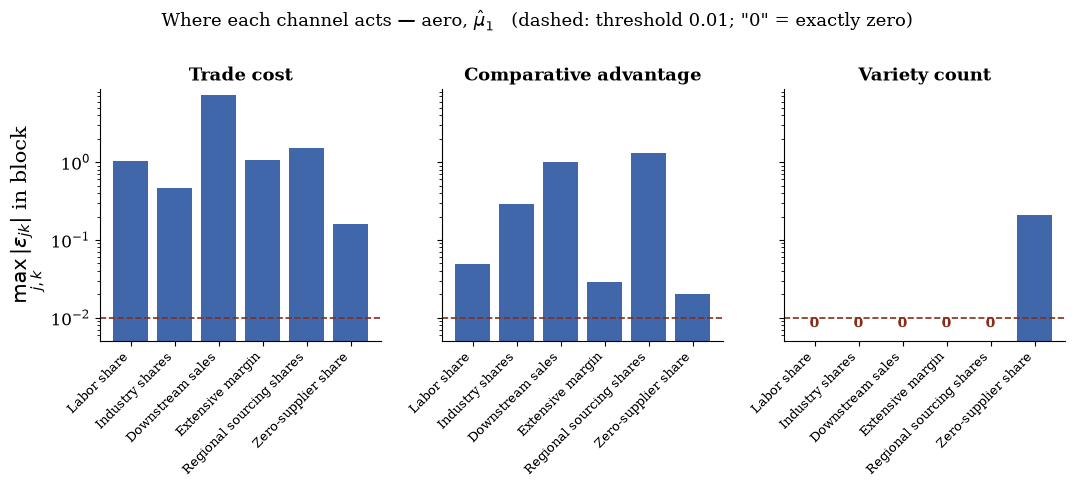

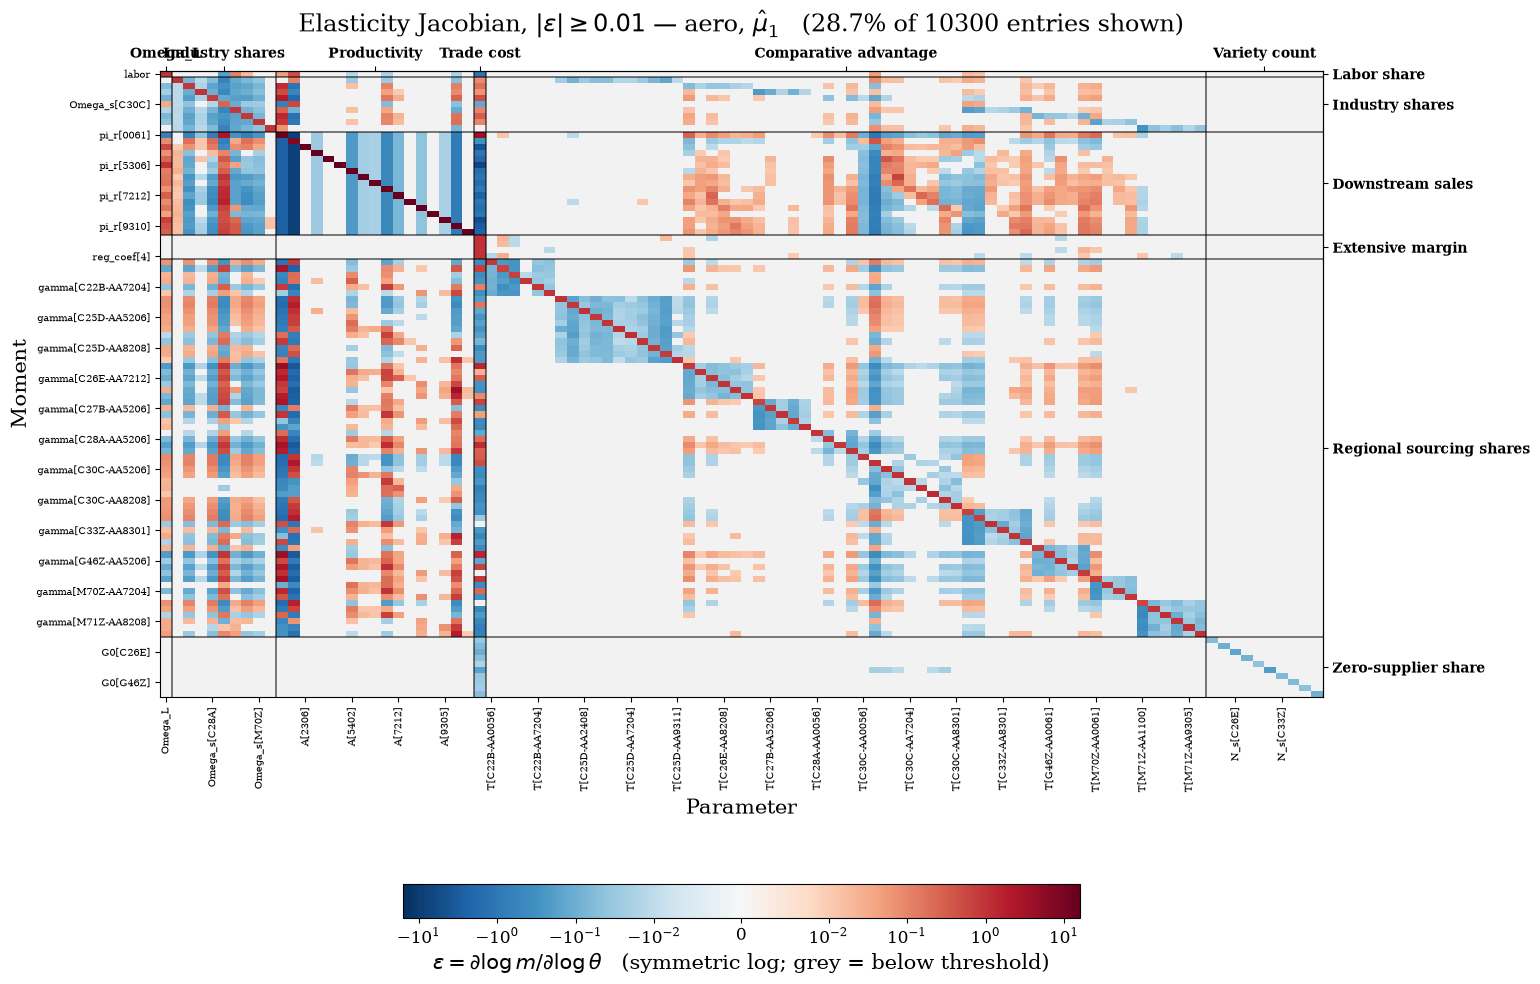

share_above                                          \
param_block                  Omega_L Industry shares Productivity Trade cost   
moment_block                                                                   
Labor share                 1.000000        0.333333     0.294118   1.000000   
Industry shares             0.777778        0.888889     0.267974   0.888889   
Downstream sales            1.000000        0.843137     0.667820   1.000000   
Extensive margin            0.000000        0.000000     0.000000   1.000000   
Regional sourcing shares    0.951613        0.596774     0.403226   0.951613   
Zero-supplier share         0.000000        0.000000     0.000000   1.000000   

                                                               max_abs  \
param_block              Comparative advantage Variety count   Omega_L   
moment_block                                                             
Labor share                           0.048387           0.0  0.912378   
Industry shares                       0.206093           0.0  0.092901   
Downstream sales                      0.408918           0.0  0.944780   
Extensive margin                      0.084677           0.0  0.000000   
Regional sourcing shares              0.256243           0.0  0.215825   
Zero-supplier share                   0.008065           0.1  0.000000   

                                                                  ...  \
param_block              Industry shares Productivity Trade cost  ...   
moment_block                                                      ...   
Labor share                     0.164725     0.451356   1.044062  ...   
Industry shares                 0.993203     1.906907   0.458071  ...   
Downstream sales                2.594201    16.067859   7.220540  ...   
Extensive margin                0.000000     0.000000   1.048545  ...   
Regional sourcing shares        0.981214     4.357829   1.506045  ...   
Zero-supplier share             0.000000     0.000000   0.160068  ...   

                             mean_abs                                   \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                  0.033729   1.044062              0.002589   
Industry shares              0.100308   0.160491              0.009673   
Downstream sales             1.607484   2.359391              0.033634   
Extensive margin             0.000000   1.031279              0.004172   
Regional sourcing shares     0.179437   0.366594              0.028866   
Zero-supplier share          0.000000   0.056556              0.000318   

                                       share_exact_zero                  \
param_block              Variety count          Omega_L Industry shares   
moment_block                                                              
Labor share                   0.000000              0.0             0.0   
Industry shares               0.000000              0.0             0.0   
Downstream sales              0.000000              0.0             0.0   
Extensive margin              0.000000              1.0             1.0   
Regional sourcing shares      0.000000              0.0             0.0   
Zero-supplier share           0.009029              1.0             1.0   

                                                                        \
param_block              Productivity Trade cost Comparative advantage   
moment_block                                                             
Labor share                       0.0        0.0                   0.0   
Industry shares                   0.0        0.0                   0.0   
Downstream sales                  0.0        0.0                   0.0   
Extensive margin                  1.0        0.0                   0.0   
Regional sourcing shares          0.0        0.0                   0.0   
Zero-supplier share               1.0       

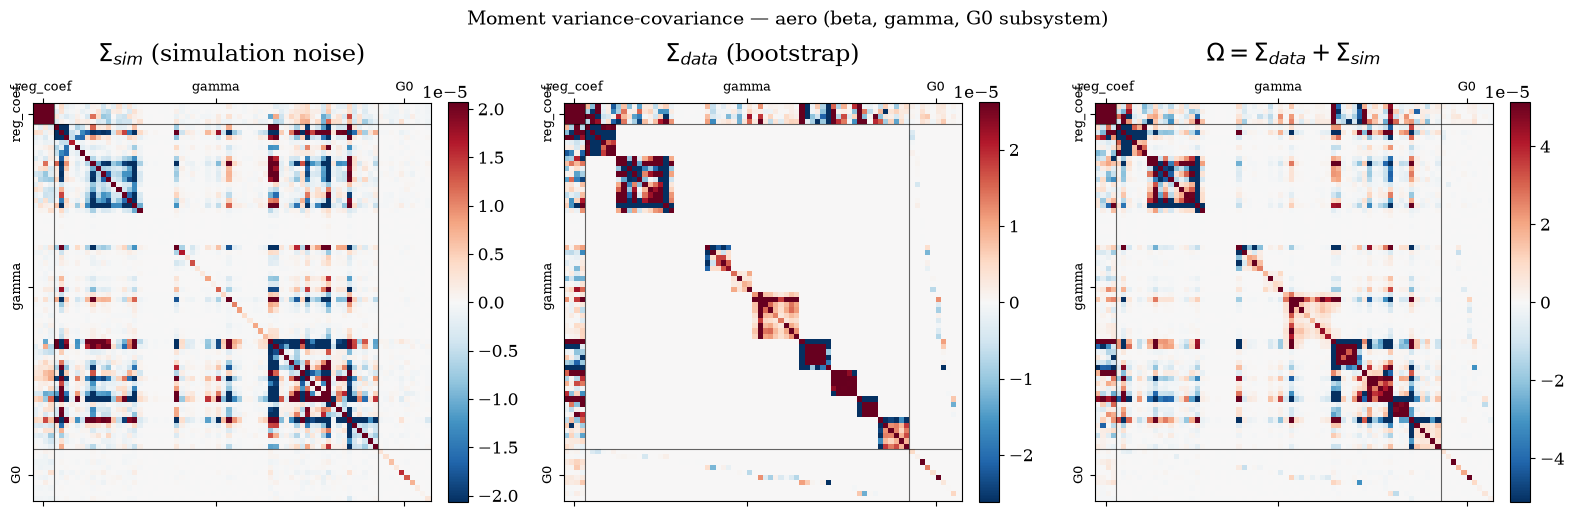

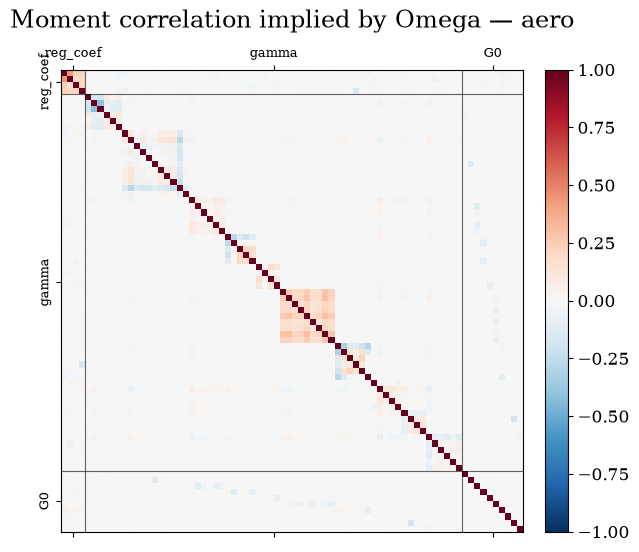

,trace,eig_min,eig_max,cond
Sigma_data,0.113914,1.109410e-31,0.022176,1.998878e+29
Sigma_sim,0.011919,1.818358e-09,0.001966,1.080957e+06
Omega,0.125833,1.040316e-08,0.023019,2.212704e+06


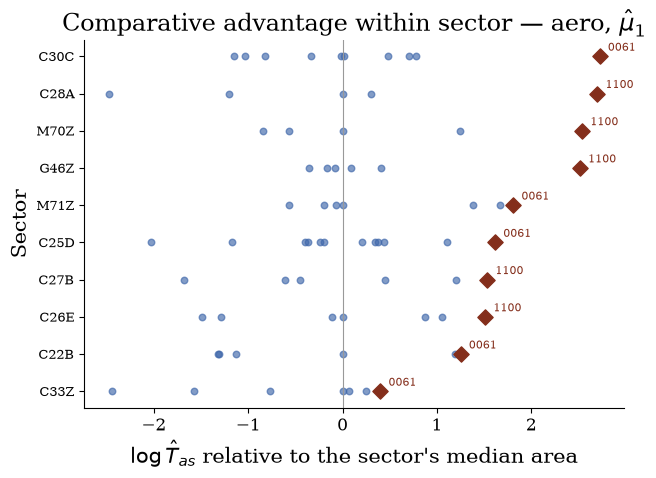

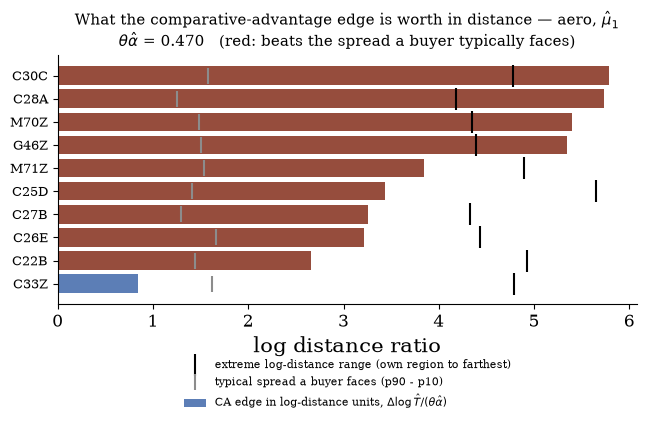

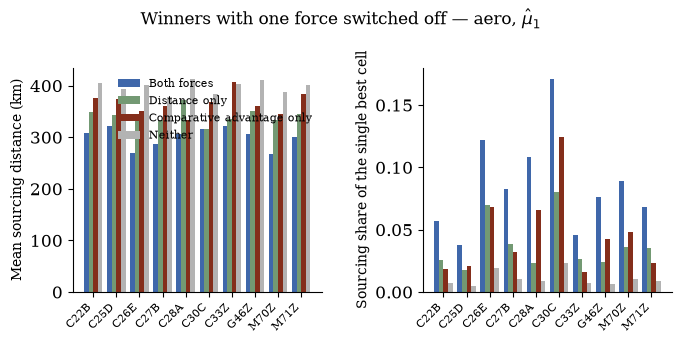

,top_area,n_areas,dlogT_top_vs_median,equiv_log_d,geo_log_spread,geo_log_range,CA_beats_typical_geography,CA_beats_any_geography,sd_logT,sd_dist,ratio_CA_over_distance,share_CA,share_distance,share_covariance,top_area_share (both),top_area_share (CA only),top_area_share (distance only)
sector,,,,,,,,,,,,,,,,,
C22B,0061,7,1.248740,2.655692,1.435774,4.925035,True,False,1.118270,0.291468,3.836687,0.860439,0.058453,0.081108,0.275953,0.260620,0.115601
C25D,0061,12,1.613450,3.431320,1.413060,5.647328,True,False,1.113445,0.278274,4.001257,0.883407,0.055178,0.061415,0.380047,0.369523,0.095556
C26E,1100,7,1.510075,3.211474,1.663617,4.434990,True,False,1.176036,0.341601,3.442722,0.791122,0.066748,0.142129,0.651183,0.615191,0.237848
C27B,1100,6,1.531116,3.256222,1.299195,4.326218,True,False,1.055115,0.275287,3.832775,0.847826,0.057714,0.094460,0.406763,0.353728,0.155554
C28A,1100,5,2.697852,5.737516,1.250889,4.182868,True,True,1.633946,0.258609,6.318216,0.920270,0.023053,0.056677,0.771976,0.726230,0.124857
C30C,0061,10,2.721667,5.788163,1.572740,4.778641,True,True,1.262264,0.347986,3.627341,0.855327,0.065006,0.079667,0.728661,0.748697,0.158290
C33Z,0061,7,0.396977,0.844251,1.623199,4.788015,False,False,0.963964,0.325374,2.962631,0.872405,0.099395,0.028200,0.344689,0.337559,0.163669
G46Z,1100,6,2.513785,5.346061,1.504883,4.394953,True,True,0.750610,0.300850,2.494964,0.757781,0.121735,0.120484,0.570057,0.514569,0.103445
M70Z,1100,5,2.536921,5.395264,1.478601,4.349354,True,True,1.161749,0.297530,3.904644,0.818260,0.053670,0.128070,0.610906,0.577320,0.163102


[aero]  eta = -0.9171  (se 0.0629, CRV1, 235 clusters)   95% CI [-1.0403, -0.7938]
            delta/gamma in the data = -0.0980 [-0.1300, -0.0650]
            347,526 supplier x downstream-region cells, 19,307 suppliers, 62.6% zeros, 180 sector x downstream-region FE
            from ../reporting_aero_profiled_aa_gran_pso/suppliers.parquet
                       channel  coefficient       se  n_obs
                   eta (total)    -0.917080 0.062874 347526
   eta_ext (extensive: Lambda)    -0.540513 0.013804 347526
eta_int (intensive: portfolio)    -0.490767 0.066525 130140
  eta - (eta_ext + eta_int) = +0.1142   (exactly zero only under common fixed effects)


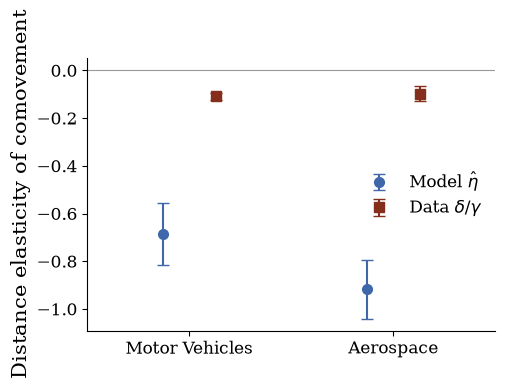

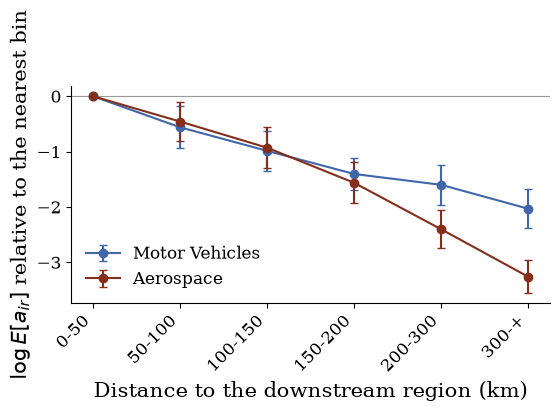

,eta (model),se,95% CI (model),delta/gamma (data),95% CI (data),inside data CI,suppliers,cells
industry,,,,,,,,
Motor Vehicles,-0.685749,0.067077,"[-0.817, -0.554]",-0.109,"[-0.122, -0.096]",False,4383,96426
Aerospace,-0.917080,0.062874,"[-1.040, -0.794]",-0.098,"[-0.130, -0.065]",False,19307,347526


In [24]:
# =============================================================================
# RUN THE REPORTING
# =============================================================================
# mu = 1 -> step1 best parameters (theta_hat_1)
# mu = 2 -> step3 best parameters (theta_hat_2, the efficient estimate)
MU = 1

# Joint reporting: both industries in one table, one figure set each.
INDUSTRIES = [{"industry": "auto", "display_name": "Motor Vehicles"},
              {"industry": "aero", "display_name": "Aerospace"}]
RUN_KWARGS = dict(base="..", profile_T=True, ca_level="aa",
                  granular=True, relax_n_lo=False, optimizer="pso")

AMPLIFICATION_RADII = (100, 200)

out_folder = "../reporting_combined"
os.makedirs(out_folder, exist_ok=True)

# --- Table: labor share + industry shares only -------------------------------
tex = generate_combined_table(INDUSTRIES, mu=MU, **RUN_KWARGS,
                              output_file=os.path.join(out_folder, f"moments_comparison_combined_mu{MU}.tex"))
print(tex)

# --- Figures -----------------------------------------------------------------
untargeted_results = []

for cfg in INDUSTRIES:
    industry = cfg["industry"]
    data = load_granular_data(industry, mu=MU, **RUN_KWARGS)
    globals().update(data)   # same pattern as analysis.ipynb: binds input_folder, folder,
                             # coefs, emp_gamma_ls, X_dr, best_params, france, ... by name
    print(f"{industry}: S={data['S']}  n_AA={data['n_AA']}  N_REG={data['n_coef']}  "
          f"moments from {data['folder'].name}/{data['step_dir']}, "
          f"SEs from {data['inference_step']}/inference")

    plot_gamma_aa(data, save_to=f"{out_folder}/emp_sim_gamma_aa_{industry}_mu{MU}.pdf")
    plt.show()

    plot_pi_r(data, save_to=f"{out_folder}/emp_sim_pi_{industry}_mu{MU}.pdf")
    plt.show()

    plot_reg_coef(data, save_to=f"{out_folder}/emp_sim_reg_coef_{industry}_mu{MU}.pdf")
    plt.show()

    plot_G0(data, save_to=f"{out_folder}/emp_sim_G0_{industry}_mu{MU}.pdf")
    plt.show()

    # --- Jacobian: which parameter moves which moment block? -----------------
    plot_jacobian_full(data, save_to=f"{out_folder}/jacobian_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_blocks(data, save_to=f"{out_folder}/jacobian_blocks_{industry}_mu{MU}.pdf")
    plt.show()
    display(jacobian_block_summary(data))

    # --- Identification: elasticities, variety counts included ---------------
    data_ext = with_variety_counts(data)
    plot_identification_map(
        data_ext, threshold=IDENT_THRESHOLD,
        save_to=f"{out_folder}/identification_map_{industry}_mu{MU}.pdf")
    plt.show()
    plot_channel_elasticities(
        data_ext, threshold=IDENT_THRESHOLD,
        save_to=f"{out_folder}/identification_channels_{industry}_mu{MU}.pdf")
    plt.show()
    plot_jacobian_thresholded(
        data_ext, threshold=IDENT_THRESHOLD,
        save_to=f"{out_folder}/jacobian_thresholded_{industry}_mu{MU}.pdf")
    plt.show()
    display(identification_summary(data_ext, threshold=IDENT_THRESHOLD))

    # --- Variance-covariance of the moments ----------------------------------
    plot_variance_covariance(data, save_to=f"{out_folder}/varcov_{industry}.pdf")
    plt.show()
    plot_moment_correlation(data, save_to=f"{out_folder}/moment_correlation_{industry}.pdf")
    plt.show()
    display(variance_covariance_summary(data))

    # --- Comparative advantage against distance, within sector ---------------
    plot_ca_distribution(
        data, save_to=f"{out_folder}/ca_distribution_{industry}_mu{MU}.pdf")
    plt.show()
    plot_ca_distance_equivalence(
        data, save_to=f"{out_folder}/ca_distance_equivalence_{industry}_mu{MU}.pdf")
    plt.show()
    plot_counterfactual_sourcing(
        data, save_to=f"{out_folder}/ca_counterfactual_{industry}_mu{MU}.pdf")
    plt.show()
    display(comparative_advantage_summary(data))

    # --- Amplification along vertical linkages (Figure 6) --------------------
    amplification_report(data, radii=AMPLIFICATION_RADII, out_folder=out_folder)

    # --- Untargeted moment: the PPML distance elasticity of comovement -------
    untargeted_results.append(estimate_untargeted_moment(data))
    decompose_untargeted_moment(data, panel=untargeted_results[-1]["panel"])

# --- Untargeted moment: model eta against the reduced-form delta/gamma -------
plot_untargeted_moment(untargeted_results,
                       save_to=f"{out_folder}/untargeted_eta_mu{MU}.pdf")
plt.show()
plot_a_ir_profile(untargeted_results,
                  save_to=f"{out_folder}/untargeted_profile_mu{MU}.pdf")
plt.show()
display(untargeted_summary(untargeted_results))
